In [ ]:
import pandas as pd
print(pd.__version__)

2.2.3


In [ ]:
import os
raw_dir = f'{base}/data/raw'
for f in sorted(os.listdir(raw_dir)):
    size_kb = os.path.getsize(f'{raw_dir}/{f}') / 1024
    print(f'{f:20s} {size_kb:8.1f} KB')

NameError: name 'base' is not defined

In [ ]:
import os
raw_dir = f'{base}/data/raw'
for f in sorted(os.listdir(raw_dir)):
    size_kb = os.path.getsize(f'{raw_dir}/{f}') / 1024
    print(f'{f:22s} {size_kb:10.1f} KB')

In [ ]:
import pandas as pd

pheno = pd.read_csv(f'{base}/data/raw/cip_phenotypes.csv', dtype={'Genome ID': str})

print('Stage: Laboratory Method only')
print('Records:', len(pheno))
print(pheno['Resistant Phenotype'].value_counts())
print('Unique genomes:', pheno['Genome ID'].nunique())

In [ ]:
# Count records per genome
counts = pheno.groupby('Genome ID').size()
dup_genomes = counts[counts > 1].index
print('Genomes with >1 AST record:', len(dup_genomes))

# For each duplicated genome, check if all records agree on phenotype
dup_records = pheno[pheno['Genome ID'].isin(dup_genomes)]
agreement = dup_records.groupby('Genome ID')['Resistant Phenotype'].nunique()

agree_genomes = agreement[agreement == 1].index
conflict_genomes = agreement[agreement > 1].index

print('Duplicated genomes with consistent label:', len(agree_genomes))
print('Duplicated genomes with CONFLICTING labels:', len(conflict_genomes))

In [ ]:
# NOTE: do not store the token in the remote URL (it ends up in .git/config). Push with the URL instead: git push https://{token}@github.com/OWNER/REPO.git HEAD:main
from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')
!git remote set-url origin https://{token}@github.com/Rita127-neup/amr-calibration-geographic-shift.git

In [ ]:
!git add .
!git commit -m "Add raw BV-BRC data and cohort assembly notebook"
!git push origin main

In [ ]:
!git rm --cached data/raw/genome_metadata.csv

In [ ]:
with open(f'{base}/.gitignore', 'a') as f:
    f.write('\ndata/raw/genome_metadata.csv\n')

In [ ]:
!git add .gitignore
!git commit --amend -m "Add raw BV-BRC data and cohort assembly notebook (genome_metadata.csv excluded: exceeds GitHub 100MB limit)"
!git push origin main

In [ ]:
readme_note = """
## Data availability note

`data/raw/genome_metadata.csv` (BV-BRC genome metadata export, ~101 MB, 119,464 rows)
is excluded from this repository because it exceeds GitHub's 100 MB file size limit.
It can be regenerated by querying BV-BRC (https://www.bv-brc.org) for genome metadata
matching the Genome IDs in `data/raw/cip_phenotypes.csv`. A trimmed, cohort-specific
version of this file (containing only the columns and genomes used in this analysis)
is provided instead at `data/processed/genome_metadata_cohort.csv` once the cohort-assembly
notebook has been run.
"""
with open(f'{base}/README.md', 'a') as f:
    f.write(readme_note)

!git add README.md
!git commit -m "Document genome_metadata.csv exclusion"
!git push origin main

In [ ]:
counts = pheno.groupby('Genome ID').size()
dup_genomes = counts[counts > 1].index
print('Genomes with >1 AST record:', len(dup_genomes))

dup_records = pheno[pheno['Genome ID'].isin(dup_genomes)]
agreement = dup_records.groupby('Genome ID')['Resistant Phenotype'].nunique()

agree_genomes = agreement[agreement == 1].index
conflict_genomes = agreement[agreement > 1].index

print('Duplicated genomes with consistent label:', len(agree_genomes))
print('Duplicated genomes with CONFLICTING labels:', len(conflict_genomes))

In [ ]:
# Genomes with a single record: keep as-is
single = pheno[~pheno['Genome ID'].isin(dup_genomes)][['Genome ID', 'Resistant Phenotype']]

# Genomes with agreeing duplicates: collapse to one row
agree_records = dup_records[dup_records['Genome ID'].isin(agree_genomes)]
collapsed = agree_records.groupby('Genome ID')['Resistant Phenotype'].first().reset_index()

# Combine, explicitly excluding the 18 conflicting genomes
genome_pheno = pd.concat([single, collapsed], ignore_index=True)

print('Final unambiguous genomes:', len(genome_pheno))
print(genome_pheno['Resistant Phenotype'].value_counts())

# sanity check: no conflicting genome leaked in
assert not any(genome_pheno['Genome ID'].isin(conflict_genomes))
assert genome_pheno['Genome ID'].is_unique
print('Checks passed.')

In [ ]:
meta = pd.read_csv(f'{base}/data/raw/genome_metadata.csv', dtype={'Genome ID': str}, low_memory=False)

merged = genome_pheno.merge(
    meta[['Genome ID', 'Genome Status', 'Genome Quality', 'MLST', 'BioProject Accession',
          'Isolation Country', 'Geographic Location', 'Collection Year']],
    on='Genome ID', how='left'
)

print('After merge:', len(merged))
print('Unmatched genomes (no metadata found):', merged['Genome Status'].isna().sum())

# Apply QC exclusions
deprecated = merged[merged['Genome Status'] == 'Deprecated']
poor = merged[merged['Genome Quality'] == 'Poor']
print('Deprecated:', len(deprecated))
print('Poor quality:', len(poor))

qc_cohort = merged[(merged['Genome Status'] != 'Deprecated') & (merged['Genome Quality'] != 'Poor')].copy()
print('Final QC cohort:', len(qc_cohort))
print(qc_cohort['Resistant Phenotype'].value_counts())

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

base = '/content/drive/MyDrive/amr-calibration-geographic-shift'

# Reload phenotype data
pheno = pd.read_csv(f'{base}/data/raw/cip_phenotypes.csv', dtype={'Genome ID': str})

# Rebuild duplicate handling
counts = pheno.groupby('Genome ID').size()
dup_genomes = counts[counts > 1].index
dup_records = pheno[pheno['Genome ID'].isin(dup_genomes)]
agreement = dup_records.groupby('Genome ID')['Resistant Phenotype'].nunique()
agree_genomes = agreement[agreement == 1].index
conflict_genomes = agreement[agreement > 1].index

single = pheno[~pheno['Genome ID'].isin(dup_genomes)][['Genome ID', 'Resistant Phenotype']]
agree_records = dup_records[dup_records['Genome ID'].isin(agree_genomes)]
collapsed = agree_records.groupby('Genome ID')['Resistant Phenotype'].first().reset_index()
genome_pheno = pd.concat([single, collapsed], ignore_index=True)

print('genome_pheno rebuilt:', len(genome_pheno), '(should be 7313)')

# Reload metadata and rebuild QC cohort
meta = pd.read_csv(f'{base}/data/raw/genome_metadata.csv', dtype={'Genome ID': str}, low_memory=False)
merged = genome_pheno.merge(
    meta[['Genome ID', 'Genome Status', 'Genome Quality', 'MLST', 'BioProject Accession',
          'Isolation Country', 'Geographic Location', 'Collection Year']],
    on='Genome ID', how='left'
)
qc_cohort = merged[(merged['Genome Status'] != 'Deprecated') & (merged['Genome Quality'] != 'Poor')].copy()
print('qc_cohort rebuilt:', len(qc_cohort), '(should be 7274)')

In [ ]:
test = pd.read_csv(f'{base}/data/raw/genome_metadata.csv', usecols=['Genome ID'])
test['Genome ID'] = test['Genome ID'].astype(float)
n_float_dupes = test['Genome ID'].duplicated().sum()

test_str = pd.read_csv(f'{base}/data/raw/genome_metadata.csv', dtype={'Genome ID': str}, usecols=['Genome ID'])
n_str_dupes = test_str['Genome ID'].duplicated().sum()

print('Spurious duplicates when parsed as float:', n_float_dupes)
print('Duplicates when parsed as string:', n_str_dupes)

In [ ]:
qc_cohort['Isolation Country'] = qc_cohort['Isolation Country'].replace({
    'England': 'United Kingdom',
    'Control': pd.NA
})
resolvable = qc_cohort['Isolation Country'].notna().sum()
print(f'Resolvable isolation country: {resolvable} ({resolvable/len(qc_cohort)*100:.1f}%)')

In [ ]:
import os
os.chdir(base)
!git add .
!git commit -m "Verify cohort assembly from raw data: 7313 -> 7274 genomes, float-ID bug (4651 dupes), country harmonization (96.0% resolvable)"
!git push origin main

In [ ]:
with open(f'{base}/results/table1_cohort_assembly.txt', 'w') as f:
    f.write("Table 1. Cohort assembly (reproduced from raw BV-BRC exports)\n\n")
    f.write(f"Laboratory Method AST records: 8631 (2071 R / 6560 S)\n")
    f.write(f"Unique genomes: 7331\n")
    f.write(f"Duplicated genomes: 1300 (1282 consistent, 18 conflicting -> excluded)\n")
    f.write(f"Unambiguous genomes: 7313\n")
    f.write(f"Deprecated excluded: 1\n")
    f.write(f"Poor quality excluded: 38\n")
    f.write(f"Final QC cohort: 7274 (1843 R / 5431 S)\n")
    f.write(f"Resolvable isolation country: 6986 (96.0%)\n")
    f.write(f"Float-ID parsing bug: 4651 spurious duplicates avoided by string dtype\n")

!git add results/table1_cohort_assembly.txt
!git commit -m "Add Table 1 results summary"
!git push origin main

In [ ]:
!git pull origin main --rebase

In [ ]:
!git push origin main

In [ ]:
uk = qc_cohort[qc_cohort['Isolation Country'] == 'United Kingdom']
norway = qc_cohort[qc_cohort['Isolation Country'] == 'Norway']
sasia = qc_cohort[qc_cohort['Isolation Country'].isin(['India', 'Pakistan', 'Bangladesh'])]

for name, pop in [('United Kingdom', uk), ('Norway', norway), ('South Asia (pooled)', sasia)]:
    n = len(pop)
    r = (pop['Resistant Phenotype'] == 'Resistant').sum()
    s = (pop['Resistant Phenotype'] == 'Susceptible').sum()
    print(f'{name:22s} n={n:5d}  R={r:4d} ({r/n*100:.1f}%)  S={s:4d}')
    if pop['Collection Year'].notna().any():
        print(f'  {"":22s} years: {pop["Collection Year"].min():.0f}-{pop["Collection Year"].max():.0f}')

In [ ]:
for country in ['India', 'Pakistan', 'Bangladesh']:
    sub = qc_cohort[qc_cohort['Isolation Country'] == country]
    r = (sub['Resistant Phenotype']=='Resistant').sum()
    s = (sub['Resistant Phenotype']=='Susceptible').sum()
    print(f'{country:12s} R={r} S={s}')

In [ ]:
with open(f'{base}/results/table2_population_characteristics.txt', 'w') as f:
    f.write("Table 2. Study population characteristics (reproduced from raw data)\n\n")
    f.write("United Kingdom: n=2575, R=731 (28.4%), years 2001-2012\n")
    f.write("Norway: n=3153, R=311 (9.9%), years 1999-2017\n")
    f.write("South Asia (pooled): n=238, R=159 (66.8%), years 2007-2021\n")
    f.write("  India: R=77 S=38\n")
    f.write("  Pakistan: R=81 S=39\n")
    f.write("  Bangladesh: R=1 S=2\n")

!git add results/table2_population_characteristics.txt
!git commit -m "Verify Table 2 population characteristics from raw data"
!git push origin main

In [ ]:
gyra_raw = pd.read_csv(f'{base}/data/raw/gene_gyrA.csv', dtype={'Genome ID': str})
print(gyra_raw.shape)
print(gyra_raw.columns.tolist())
print(gyra_raw['Evidence'].value_counts(dropna=False))

In [ ]:
# NAIVE (buggy) construction: match Antibiotics Class only, ignore Evidence type
buggy_mask = gyra_raw['Antibiotics Class'].fillna('').str.contains('quinolone', case=False)
buggy_genomes = set(gyra_raw.loc[buggy_mask, 'Genome ID'])
print('Buggy gyrA feature — genomes flagged:', len(buggy_genomes))

# Attach to qc_cohort and check susceptible carriage rate by population
qc_cohort['gyrA_BUGGY'] = qc_cohort['Genome ID'].isin(buggy_genomes).astype(int)

for name, pop in [('United Kingdom', uk), ('Norway', norway)]:
    sub = qc_cohort[qc_cohort['Isolation Country']==name]
    for pheno in ['Resistant','Susceptible']:
        s = sub[sub['Resistant Phenotype']==pheno]
        rate = s['Genome ID'].isin(buggy_genomes).mean()
        print(f'{name:16s} {pheno:12s} n={len(s):5d}  gyrA carriage={rate:.3f}')

In [ ]:
# STRICT (corrected) construction
strict_mask = (
    (gyra_raw['Evidence'] == 'AMRFinderPlus: POINTP') &
    (gyra_raw['Antibiotics Class'].fillna('') == 'quinolone')
)
strict_genomes = set(gyra_raw.loc[strict_mask, 'Genome ID'])
print('Strict gyrA feature — genomes flagged:', len(strict_genomes))

# Check how many rows were quinolone/triclosan combined (excluded per Methods 2.4)
tric_mask = (gyra_raw['Evidence']=='AMRFinderPlus: POINTP') & (gyra_raw['Antibiotics Class'].fillna('').str.contains('triclosan', case=False))
print('Quinolone/triclosan combined-class rows excluded:', tric_mask.sum())

qc_cohort['gyrA_STRICT'] = qc_cohort['Genome ID'].isin(strict_genomes).astype(int)

print()
print('BEFORE vs AFTER, by population and phenotype:')
for name, pop in [('United Kingdom', uk), ('Norway', norway)]:
    sub = qc_cohort[qc_cohort['Isolation Country']==name]
    for pheno in ['Resistant','Susceptible']:
        s = sub[sub['Resistant Phenotype']==pheno]
        buggy_rate = s['Genome ID'].isin(buggy_genomes).mean()
        strict_rate = s['Genome ID'].isin(strict_genomes).mean()
        print(f'{name:16s} {pheno:12s} n={len(s):5d}  BUGGY={buggy_rate:.3f}  STRICT={strict_rate:.3f}')

In [ ]:
with open(f'{base}/results/gyrA_bug_investigation.txt', 'w') as f:
    f.write("gyrA feature construction bug — investigation and fix\n\n")
    f.write("Root cause: gene_gyrA.csv pools 5 evidence types (BLAT, K-mer Search,\n")
    f.write("AMRFinderPlus:POINTP, RGI protein variant model, BLASTP). Only POINTP\n")
    f.write("represents an actual point-mutation call; the others are homology/\n")
    f.write("presence detectors that fire on the wild-type gene itself.\n\n")
    f.write("BUGGY feature (matched on Antibiotics Class only, all evidence types):\n")
    f.write("  UK susceptible carriage:     39.0%\n")
    f.write("  Norway susceptible carriage: 100.0%\n\n")
    f.write("STRICT feature (POINTP evidence only, quinolone class only):\n")
    f.write("  UK susceptible carriage:     8.9%\n")
    f.write("  Norway susceptible carriage: 4.9%\n")
    f.write("  UK resistant carriage:       99.0% (unchanged)\n")
    f.write("  Norway resistant carriage:   95.2%\n\n")
    f.write("Conclusion: the apparent 'Norway anomaly' was an artifact of pooling\n")
    f.write("non-mutation evidence types into a mutation-presence feature. Real\n")
    f.write("discriminative signal survives after correction; false-positive noise\n")
    f.write("in susceptible genomes does not.\n")

!git add results/gyrA_bug_investigation.txt
!git commit -m "Document and verify gyrA feature construction bug and fix"
!git push origin main

In [ ]:
parc_raw = pd.read_csv(f'{base}/data/raw/gene_parC.csv', dtype={'Genome ID': str})
print(parc_raw['Evidence'].value_counts(dropna=False))

parc_strict_mask = (parc_raw['Evidence'] == 'AMRFinderPlus: POINTP')
parc_strict_genomes = set(parc_raw.loc[parc_strict_mask, 'Genome ID'])

# also build the "buggy" equivalent for comparison
parc_buggy_mask = parc_raw['Antibiotics Class'].fillna('').str.contains('quinolone', case=False)
parc_buggy_genomes = set(parc_raw.loc[parc_buggy_mask, 'Genome ID'])

print('parC POINTP-only genomes:', len(parc_strict_genomes))
print('parC class-only (buggy-equivalent) genomes:', len(parc_buggy_genomes))

for name, pop in [('United Kingdom', uk), ('Norway', norway)]:
    sub = qc_cohort[qc_cohort['Isolation Country']==name]
    for pheno in ['Resistant','Susceptible']:
        s = sub[sub['Resistant Phenotype']==pheno]
        strict_rate = s['Genome ID'].isin(parc_strict_genomes).mean()
        buggy_rate = s['Genome ID'].isin(parc_buggy_genomes).mean()
        print(f'{name:16s} {pheno:12s} n={len(s):5d}  STRICT={strict_rate:.3f}  BUGGY-equiv={buggy_rate:.3f}')

In [ ]:
with open(f'{base}/results/parC_verification.txt', 'w') as f:
    f.write("parC feature construction — verification (no bug found)\n\n")
    f.write("gene_parC.csv evidence composition: BLAT=5799, POINTP=2686,\n")
    f.write("RGI=1744, BLASTP=1, K-mer Search=1 (vs gyrA's 5784 K-mer Search rows).\n\n")
    f.write("STRICT (POINTP-only) vs original class-only filtering give near-identical\n")
    f.write("results (1828 vs 1849 genomes total; per-population/phenotype rates match\n")
    f.write("to 3 decimal places). Original parC construction was correct.\n")
    f.write("Confirms the gyrA bug was specific to that gene's unusually high volume\n")
    f.write("of non-mutation homology/presence-detector rows, not a general flaw in\n")
    f.write("the pipeline's class-based filtering logic.\n")

!git add results/parC_verification.txt
!git commit -m "Verify parC feature construction — no bug found, explain why gyrA was uniquely affected"
!git push origin main

In [ ]:
files = ['gene_gyrA.csv','gene_parC.csv','gene_qnrA.csv','gene_qnrB.csv','gene_qnrS.csv',
         'gene_oqxA.csv','gene_oqxB.csv','gene_ib-cr.csv']

dfs = []
for f in files:
    d = pd.read_csv(f'{base}/data/raw/{f}', dtype={'Genome ID': str})
    d['__source_file'] = f
    dfs.append(d)
pool = pd.concat(dfs, ignore_index=True)

for c in ['Gene','Function','Product']:
    if c not in pool.columns: pool[c] = ''
pool['__text'] = pool['Gene'].fillna('') + ' ' + pool['Function'].fillna('') + ' ' + pool['Product'].fillna('')

def content_match(pattern):
    mask = pool['__text'].str.contains(pattern, case=False, regex=True, na=False)
    return set(pool.loc[mask, 'Genome ID'])

qnrA_genomes = content_match(r'qnra')
qnrB_genomes = content_match(r'qnrb')
qnrS_genomes = content_match(r'qnrs')
oqxA_genomes = content_match(r'oqxa')
oqxB_genomes = content_match(r'oqxb')
aac6_genomes = content_match(r'ib-cr')

for name, s in [('qnrA',qnrA_genomes), ('qnrB',qnrB_genomes), ('qnrS',qnrS_genomes),
                ('oqxA',oqxA_genomes), ('oqxB',oqxB_genomes), ('aac6_Ib_cr',aac6_genomes)]:
    print(f'{name:12s} genomes: {len(s)}')

In [ ]:
qnrb_file = pd.read_csv(f'{base}/data/raw/gene_qnrB.csv', dtype={'Genome ID': str})
qnrb_file['__text'] = qnrb_file['Gene'].fillna('') + ' ' + qnrb_file['Function'].fillna('') + ' ' + qnrb_file['Product'].fillna('')

is_qnrb = qnrb_file['__text'].str.contains('qnrb', case=False, regex=True, na=False)
is_qnrs = qnrb_file['__text'].str.contains('qnrs', case=False, regex=True, na=False)

print('gene_qnrB.csv total rows:', len(qnrb_file))
print('  content-matches qnrB:', is_qnrb.sum(), f'({is_qnrb.mean()*100:.1f}%)')
print('  content-matches qnrS:', is_qnrs.sum(), f'({is_qnrs.mean()*100:.1f}%)')
print()

ibcr_file = pd.read_csv(f'{base}/data/raw/gene_ib-cr.csv', dtype={'Genome ID': str})
ibcr_file['__text'] = ibcr_file['Gene'].fillna('') + ' ' + ibcr_file['Function'].fillna('') + ' ' + ibcr_file['Product'].fillna('')

is_ibcr = ibcr_file['__text'].str.contains('ib-cr', case=False, regex=True, na=False)
print('gene_ib-cr.csv total rows:', len(ibcr_file))
print('  content-matches AAC(6\')-Ib-cr:', is_ibcr.sum(), f'({is_ibcr.mean()*100:.1f}%)')
print('  does NOT match (unrelated):', (~is_ibcr).sum(), f'({(~is_ibcr).mean()*100:.1f}%)')

print()
print(ibcr_file.loc[~is_ibcr, 'Function'].value_counts().head(5))

In [ ]:
files = ['gene_gyrA.csv','gene_parC.csv','gene_qnrA.csv','gene_qnrB.csv','gene_qnrS.csv',
         'gene_oqxA.csv','gene_oqxB.csv','gene_ib-cr.csv']
dfs = [pd.read_csv(f'{base}/data/raw/{f}', dtype={'Genome ID': str}) for f in files]
pool = pd.concat(dfs, ignore_index=True)
for c in ['Gene','Function','Product']:
    if c not in pool.columns: pool[c] = ''

# qnrA/B/S: require a SPECIFIC allele number, not just family-level text
pool['__specific'] = pool['Gene'].fillna('') + ' | ' + pool['Function'].fillna('') + ' | ' + pool['Product'].fillna('')
def specific_match(letter):
    mask = pool['__specific'].str.contains(rf'qnr{letter}\d+', case=False, regex=True, na=False)
    return set(pool.loc[mask, 'Genome ID'])

qnrA_final = specific_match('a')
qnrB_final = specific_match('b')
qnrS_final = specific_match('s')

# oqxA/oqxB: pooled text is reliable, keep as before
def content_match(pattern):
    mask = pool['__specific'].str.contains(pattern, case=False, regex=True, na=False)
    return set(pool.loc[mask, 'Genome ID'])
oqxA_final = content_match(r'oqxa')
oqxB_final = content_match(r'oqxb')

# aac6_Ib_cr: Gene/Function ONLY, explicitly exclude Ib10 and TEM
pool['__gf'] = pool['Gene'].fillna('') + ' | ' + pool['Function'].fillna('')
is_ibcr = pool['__gf'].str.contains(r'ib-cr', case=False, regex=True, na=False)
aac6_final = set(pool.loc[is_ibcr, 'Genome ID'])

for name, s in [('qnrA',qnrA_final),('qnrB',qnrB_final),('qnrS',qnrS_final),
                ('oqxA',oqxA_final),('oqxB',oqxB_final),('aac6_Ib_cr',aac6_final)]:
    print(f'{name:12s}: {len(s)}')

print('qnrB/qnrS overlap check (should be 0):', len(qnrB_final & qnrS_final))

In [ ]:
with open(f'{base}/results/qnrB_ibcr_bug_investigation.txt', 'w') as f:
    f.write("qnrB / aac6_Ib_cr feature construction bug — investigation and fix\n\n")
    f.write("Root cause: BV-BRC's 'Product' field is a fixed template tied to the\n")
    f.write("search query term, not a per-row fact. Rows returned by a 'qnrB' search\n")
    f.write("all carry Product='...QnrB family' even when Function correctly identifies\n")
    f.write("the true gene as QnrS1. Same pattern in the 'ib-cr' search: Product says\n")
    f.write("'...AAC(6')-Ib-cr...' for every row, including true TEM-156 and Ib10 hits.\n\n")
    f.write("Naive pooled Gene+Function+Product substring matching (as literally\n")
    f.write("described in Methods 2.4) therefore double-counts: 175/176 qnrS genomes\n")
    f.write("were also incorrectly flagged qnrB-positive via the generic Product text.\n\n")
    f.write("Fix: require a SPECIFIC allele number (e.g. QnrS1, QnrB10) via regex,\n")
    f.write("rather than a generic family-level string match. For aac6_Ib_cr, use\n")
    f.write("Gene/Function only (excluding Product entirely) and explicitly exclude\n")
    f.write("rows matching Ib10 or TEM-family beta-lactamase.\n\n")
    f.write("Corrected genome-level counts:\n")
    f.write("  qnrA: 15 (unchanged)\n")
    f.write("  qnrB: 29 (was 218 under naive matching -- 7.5x overcounted)\n")
    f.write("  qnrS: 176 (unchanged)\n")
    f.write("  oqxA: 6 (unchanged, file was clean)\n")
    f.write("  oqxB: 7 (unchanged, file was clean)\n")
    f.write("  aac6_Ib_cr: 489 (was contaminated by templated Product field)\n")
    f.write("  qnrB/qnrS overlap: 0 (was 175 under naive matching)\n")

!git add results/qnrB_ibcr_bug_investigation.txt
!git commit -m "Find and fix second feature bug: qnrB/aac6_Ib_cr generic-template contamination"
!git push origin main

In [ ]:
final_features = {
    'gyrA_fq_mut': strict_genomes,      # from earlier gyrA fix
    'parC_fq_mut': parc_strict_genomes, # from earlier parC verification
    'qnrA': qnrA_final,
    'qnrB': qnrB_final,
    'qnrS': qnrS_final,
    'oqxA': oqxA_final,
    'oqxB': oqxB_final,
    'aac6_Ib_cr': aac6_final,
}

for col, genome_set in final_features.items():
    qc_cohort[col] = qc_cohort['Genome ID'].isin(genome_set).astype(int)

print(qc_cohort[list(final_features.keys())].sum())

qc_cohort.to_csv(f'{base}/data/processed/qc_cohort_final_features.csv', index=False)
print('Saved:', len(qc_cohort), 'genomes')

In [ ]:
!git add data/processed/qc_cohort_final_features.csv
!git commit -m "Save final corrected feature matrix (7274 genomes, 8 verified features)"
!git push origin main

In [ ]:
qc_cohort['y'] = (qc_cohort['Resistant Phenotype'] == 'Resistant').astype(int)

feature_cols = ['gyrA_fq_mut','parC_fq_mut','qnrA','qnrB','qnrS','oqxA','oqxB','aac6_Ib_cr']

uk = qc_cohort[qc_cohort['Isolation Country']=='United Kingdom'].copy()
norway = qc_cohort[qc_cohort['Isolation Country']=='Norway'].copy()
sasia = qc_cohort[qc_cohort['Isolation Country'].isin(['India','Pakistan','Bangladesh'])].copy()

print('UK MLST missing:', uk['MLST'].isna().sum(), 'of', len(uk))
uk_model = uk.dropna(subset=['MLST']).copy()
print('UK after dropping missing MLST:', len(uk_model))

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression

X_uk = uk_model[feature_cols].values
y_uk = uk_model['y'].values
groups_uk = uk_model['MLST'].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Verify no MLST group appears in more than one fold
fold_groups = []
for train_idx, test_idx in sgkf.split(X_uk, y_uk, groups_uk):
    fold_groups.append(set(groups_uk[test_idx]))

for i in range(5):
    for j in range(i+1, 5):
        overlap = fold_groups[i] & fold_groups[j]
        if overlap:
            print(f'LEAKAGE between fold {i} and {j}:', overlap)
print('Leakage check complete (no output above = no leakage).')

In [ ]:
clf = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, solver='saga', max_iter=5000, C=1.0)

oof_proba = cross_val_predict(clf, X_uk, y_uk, cv=sgkf, groups=groups_uk, method='predict_proba')[:, 1]

from sklearn.metrics import roc_auc_score, average_precision_score, matthews_corrcoef, confusion_matrix

def discrimination_metrics(y, p, thresh=0.5):
    auroc = roc_auc_score(y, p)
    auprc = average_precision_score(y, p)
    pred = (p >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    mcc = matthews_corrcoef(y, pred)
    return auroc, auprc, sens, spec, mcc

auroc, auprc, sens, spec, mcc = discrimination_metrics(y_uk, oof_proba)
print(f'AUROC: {auroc:.3f}')
print(f'AUPRC: {auprc:.3f}')
print(f'Sensitivity: {sens:.3f}')
print(f'Specificity: {spec:.3f}')
print(f'MCC: {mcc:.3f}')

In [ ]:
clf_full = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, solver='saga', max_iter=5000, C=1.0)
clf_full.fit(X_uk, y_uk)

for name, coef in zip(feature_cols, clf_full.coef_[0]):
    print(f'{name:14s}: {coef:.3f}')
print(f'{"intercept":14s}: {clf_full.intercept_[0]:.3f}')

In [ ]:
def evaluate_external(pop_df, name):
    Xp = pop_df[feature_cols].values
    yp = pop_df['y'].values
    pp = clf_full.predict_proba(Xp)[:, 1]
    auroc, auprc, sens, spec, mcc = discrimination_metrics(yp, pp)
    print(f'--- {name} (n={len(pop_df)}) ---')
    print(f'AUROC: {auroc:.3f}  AUPRC: {auprc:.3f}  Sens: {sens:.3f}  Spec: {spec:.3f}  MCC: {mcc:.3f}')
    return pp, yp

p_norway, y_norway = evaluate_external(norway, 'Norway')
p_sasia, y_sasia = evaluate_external(sasia, 'South Asia')

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression as LR
from sklearn.metrics import brier_score_loss

def calibration_metrics(y, p):
    p = np.clip(p, 1e-6, 1-1e-6)
    logit = np.log(p/(1-p)).reshape(-1,1)
    lr = LR(C=1e6, max_iter=1000)
    lr.fit(logit, y)
    slope = lr.coef_[0][0]
    intercept = lr.intercept_[0]
    brier = brier_score_loss(y, p)
    bins = np.linspace(0,1,11)
    idx = np.clip(np.digitize(p, bins) - 1, 0, 9)
    ece = sum((idx==b).sum()/len(p) * abs(p[idx==b].mean() - y[idx==b].mean()) for b in range(10) if (idx==b).sum()>0)
    return slope, intercept, brier, ece

print('UK (in-domain, OOF):')
print(calibration_metrics(y_uk, oof_proba))
print()
print('Norway (external):')
print(calibration_metrics(y_norway, p_norway))
print()
print('South Asia (external):')
print(calibration_metrics(y_sasia, p_sasia))

In [ ]:
with open(f'{base}/results/table3_4_corrected_discrimination_calibration.txt', 'w') as f:
    f.write("Corrected discrimination and calibration (post gyrA + qnrB/aac6 fixes)\n\n")
    f.write("Discrimination:\n")
    f.write("  UK (OOF): AUROC=0.992 AUPRC=0.987 Sens=0.985 Spec=0.991 MCC=0.973\n")
    f.write("  Norway:   AUROC=0.968 AUPRC=0.868 Sens=0.881 Spec=0.992 MCC=0.889\n")
    f.write("  S.Asia:   AUROC=0.970 AUPRC=0.981 Sens=0.943 Spec=0.987 MCC=0.910\n\n")
    f.write("Calibration (slope, intercept, Brier, ECE):\n")
    f.write("  UK:      1.092, -0.041, 0.0088, 0.0101\n")
    f.write("  Norway:  0.726, -0.488, 0.0206, 0.0176\n")
    f.write("  S.Asia:  0.786, +0.927, 0.0399, 0.0347\n\n")
    f.write("Comparison to original (buggy) results:\n")
    f.write("  Norway intercept: -1.156 -> -0.488 (58% reduction in magnitude)\n")
    f.write("  S.Asia intercept: +1.625 -> +0.927 (43% reduction in magnitude)\n")
    f.write("Conclusion: real calibration failure under geographic shift persists,\n")
    f.write("but original magnitude was substantially inflated by feature-construction\n")
    f.write("bugs. Core qualitative finding (discrimination robust, calibration fragile)\n")
    f.write("survives correction.\n")

!git add results/table3_4_corrected_discrimination_calibration.txt
!git commit -m "Corrected Tables 3-4: discrimination and calibration after bug fixes"
!git push origin main

NameError: name 'base' is not defined

In [ ]:
def rule_based_predict(df):
    return (df[feature_cols].sum(axis=1) > 0).astype(int)

def rule_metrics(df, name):
    y = df['y'].values
    pred = rule_based_predict(df).values
    # AUROC/AUPRC need a "score" - the rule only gives a binary prediction,
    # so treat the binary prediction itself as the score (this is what
    # makes the original paper's AUROC come out exactly 0.5 whenever the
    # rule fires near-uniformly across both classes)
    auroc = roc_auc_score(y, pred)
    auprc = average_precision_score(y, pred)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    sens = tp/(tp+fn)
    spec = tn/(tn+fp)
    mcc = matthews_corrcoef(y, pred)
    print(f'--- {name} (rule-based baseline) ---')
    print(f'AUROC: {auroc:.3f}  AUPRC: {auprc:.3f}  Sens: {sens:.3f}  Spec: {spec:.3f}  MCC: {mcc:.3f}')

rule_metrics(uk_model, 'UK (in-domain)')
rule_metrics(norway, 'Norway')
rule_metrics(sasia, 'South Asia')

In [ ]:
with open(f'{base}/results/table3_rule_baseline_corrected.txt', 'w') as f:
    f.write("Rule-based baseline, corrected features\n\n")
    f.write("UK:         AUROC=0.938 AUPRC=0.770 Sens=0.990 Spec=0.886 MCC=0.822\n")
    f.write("Norway:     AUROC=0.945 AUPRC=0.594 Sens=0.955 Spec=0.935 MCC=0.738\n")
    f.write("South Asia: AUROC=0.731 AUPRC=0.789 Sens=0.994 Spec=0.468 MCC=0.594\n\n")
    f.write("MAJOR FINDING: original paper's rule-based AUROC=0.500 in Norway and\n")
    f.write("South Asia was an artifact of the gyrA bug (near-universal false-positive\n")
    f.write("firing), not a genuine baseline failure. Corrected rule performs nearly\n")
    f.write("as well as the elastic-net model in Norway (0.945 vs 0.968) but still\n")
    f.write("fails substantially in South Asia (0.731 vs 0.970). This changes the\n")
    f.write("paper's core comparator narrative: the naive rule is not uniformly\n")
    f.write("useless externally -- its failure is specific to populations with\n")
    f.write("different resistance-mechanism composition, not to geography per se.\n")

!git add results/table3_rule_baseline_corrected.txt
!git commit -m "MAJOR: rule-based baseline result overturned by feature fix -- Norway AUROC 0.500->0.945"
!git push origin main

In [ ]:
import numpy as np

def bootstrap_ci(y, p, metric_fn, n_boot=1000, seed=0):
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    p = np.asarray(p)
    n = len(y)
    stats = []
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        y_b, p_b = y[idx], p[idx]
        if len(np.unique(y_b)) < 2:
            continue  # skip resamples with only one class present
        stats.append(metric_fn(y_b, p_b))
    stats = np.array(stats)
    lo, hi = np.percentile(stats, [2.5, 97.5])
    return np.mean(stats), lo, hi

# metric functions that take (y, p) where p can be probability OR binary prediction
def auroc_fn(y, p): return roc_auc_score(y, p)
def auprc_fn(y, p): return average_precision_score(y, p)
def mcc_fn_at_thresh(y, p, thresh=0.5): return matthews_corrcoef(y, (p>=thresh).astype(int))
def sens_fn(y, p, thresh=0.5):
    pred = (p>=thresh).astype(int)
    tn,fp,fn,tp = confusion_matrix(y,pred).ravel()
    return tp/(tp+fn)
def spec_fn(y, p, thresh=0.5):
    pred = (p>=thresh).astype(int)
    tn,fp,fn,tp = confusion_matrix(y,pred).ravel()
    return tn/(tn+fp)

In [ ]:
populations = {
    'UK': (y_uk, oof_proba),
    'Norway': (y_norway, p_norway),
    'South Asia': (y_sasia, p_sasia),
}

print('=== Elastic-net model, bootstrap 95% CIs ===')
for name, (y, p) in populations.items():
    print(f'--- {name} ---')
    for metric_name, fn in [('AUROC',auroc_fn), ('AUPRC',auprc_fn), ('Sens',sens_fn), ('Spec',spec_fn), ('MCC',mcc_fn_at_thresh)]:
        mean, lo, hi = bootstrap_ci(y, p, fn)
        print(f'  {metric_name:6s}: {mean:.3f} ({lo:.3f}-{hi:.3f})')

In [ ]:
print('=== Rule-based baseline, bootstrap 95% CIs ===')
rule_populations = {
    'UK': (uk_model['y'].values, rule_based_predict(uk_model).values),
    'Norway': (norway['y'].values, rule_based_predict(norway).values),
    'South Asia': (sasia['y'].values, rule_based_predict(sasia).values),
}
for name, (y, pred) in rule_populations.items():
    print(f'--- {name} ---')
    for metric_name, fn in [('AUROC',auroc_fn), ('AUPRC',auprc_fn), ('Sens',sens_fn), ('Spec',spec_fn), ('MCC',mcc_fn_at_thresh)]:
        mean, lo, hi = bootstrap_ci(y, pred, fn)
        print(f'  {metric_name:6s}: {mean:.3f} ({lo:.3f}-{hi:.3f})')

In [ ]:
def calib_slope_fn(y, p):
    p = np.clip(p, 1e-6, 1-1e-6)
    logit = np.log(p/(1-p)).reshape(-1,1)
    lr = LR(C=1e6, max_iter=1000)
    lr.fit(logit, y)
    return lr.coef_[0][0]

def calib_intercept_fn(y, p):
    p = np.clip(p, 1e-6, 1-1e-6)
    logit = np.log(p/(1-p)).reshape(-1,1)
    lr = LR(C=1e6, max_iter=1000)
    lr.fit(logit, y)
    return lr.intercept_[0]

def brier_fn(y, p):
    return brier_score_loss(y, p)

print('=== Calibration, bootstrap 95% CIs ===')
for name, (y, p) in populations.items():
    print(f'--- {name} ---')
    for metric_name, fn in [('Slope',calib_slope_fn), ('Intercept',calib_intercept_fn), ('Brier',brier_fn)]:
        mean, lo, hi = bootstrap_ci(y, p, fn)
        print(f'  {metric_name:10s}: {mean:.3f} ({lo:.3f}-{hi:.3f})')

=== Calibration, bootstrap 95% CIs ===


NameError: name 'populations' is not defined

In [ ]:
def ece_fn(y, p):
    bins = np.linspace(0,1,11)
    idx = np.clip(np.digitize(p, bins) - 1, 0, 9)
    return sum((idx==b).sum()/len(p) * abs(p[idx==b].mean() - y[idx==b].mean()) for b in range(10) if (idx==b).sum()>0)

print('=== ECE, bootstrap 95% CIs ===')
for name, (y, p) in populations.items():
    mean, lo, hi = bootstrap_ci(y, p, ece_fn)
    print(f'{name:12s} ECE: {mean:.4f} ({lo:.4f}-{hi:.4f})')

In [ ]:
with open(f'{base}/results/table3_4_full_bootstrap_CIs.txt', 'w') as f:
    f.write("Tables 3-4 with 95% bootstrap CIs (1000 resamples, corrected features)\n\n")
    f.write("=== Elastic-net discrimination ===\n")
    f.write("UK:      AUROC 0.992 (0.986-0.996)  MCC 0.974 (0.964-0.983)\n")
    f.write("Norway:  AUROC 0.968 (0.954-0.981)  MCC 0.889 (0.860-0.917)\n")
    f.write("S.Asia:  AUROC 0.970 (0.945-0.989)  MCC 0.910 (0.849-0.957)\n\n")
    f.write("=== Rule-based baseline discrimination ===\n")
    f.write("UK:      AUROC 0.939 (0.930-0.946)  MCC 0.823 (0.803-0.842)\n")
    f.write("Norway:  AUROC 0.945 (0.931-0.957)  MCC 0.738 (0.706-0.769)\n")
    f.write("S.Asia:  AUROC 0.730 (0.676-0.785)  MCC 0.591 (0.494-0.682)\n\n")
    f.write("=== Calibration ===\n")
    f.write("UK:      slope 1.114 (0.977-1.306)  intercept -0.077 (-0.654 to 0.306) [CI includes 0: well-calibrated]\n")
    f.write("Norway:  slope 0.729 (0.677-0.796)  intercept -0.494 (-0.772 to -0.237) [CI excludes 0 AND 1: genuine overprediction + flattening]\n")
    f.write("S.Asia:  slope 0.827 (0.611-1.141)  intercept 0.973 (0.448-1.488) [intercept CI excludes 0: genuine underprediction; slope CI includes 1: pure mean-shift, not distortion]\n")

!git add results/table3_4_full_bootstrap_CIs.txt
!git commit -m "Complete Tables 3-4 with bootstrap 95% CIs, including ECE"
!git push origin main

In [ ]:
def classify_mechanism(row):
    if row['parC_fq_mut'] == 1:
        return 'parC_mutation'
    elif any(row[g] == 1 for g in ['qnrA','qnrB','qnrS','oqxA','oqxB','aac6_Ib_cr']):
        return 'acquired_gene_no_parC'
    else:
        return 'neither'

for name, pop in [('UK', uk_model), ('Norway', norway), ('South Asia', sasia)]:
    resistant = pop[pop['y']==1].copy()
    resistant['mechanism'] = resistant.apply(classify_mechanism, axis=1)
    counts = resistant['mechanism'].value_counts()
    pcts = resistant['mechanism'].value_counts(normalize=True)*100
    print(f'--- {name} (n resistant = {len(resistant)}) ---')
    for cat in ['parC_mutation','acquired_gene_no_parC','neither']:
        c = counts.get(cat,0)
        p = pcts.get(cat,0)
        print(f'  {cat:24s}: {c:4d} ({p:.1f}%)')
    print()

In [ ]:
resistant_norway = norway[norway['y']==1].copy()
resistant_norway['mechanism'] = resistant_norway.apply(classify_mechanism, axis=1)
neither_norway = resistant_norway[resistant_norway['mechanism']=='neither']

print('Norway "neither" resistant genomes:', len(neither_norway))
print('Their gyrA_fq_mut values:', neither_norway['gyrA_fq_mut'].value_counts().to_dict())

Xn = neither_norway[feature_cols].values
pn = clf_full.predict_proba(Xn)[:,1]
print('Predicted probabilities for these genomes:')
print(pn)
print('Mean:', pn.mean())

# compare to mean predicted prob for parC-mutation resistant genomes in Norway, for contrast
parc_norway = resistant_norway[resistant_norway['mechanism']=='parC_mutation']
Xp = parc_norway[feature_cols].values
pp = clf_full.predict_proba(Xp)[:,1]
print('Mean predicted prob for parC-mutation resistant genomes:', pp.mean())

In [ ]:
print('Norway "neither" genomes by MLST:')
print(neither_norway['MLST'].value_counts().head(10))
print()
print('Number of distinct MLST types among these 33:', neither_norway['MLST'].nunique())

# UK's 10 "neither" genomes, for comparison
resistant_uk = uk_model[uk_model['y']==1].copy()
resistant_uk['mechanism'] = resistant_uk.apply(classify_mechanism, axis=1)
neither_uk = resistant_uk[resistant_uk['mechanism']=='neither']
Xu = neither_uk[feature_cols].values
pu = clf_full.predict_proba(Xu)[:,1]
print()
print('UK "neither" resistant genomes:', len(neither_uk), ' mean predicted prob:', pu.mean())
print('UK "neither" MLST types:', neither_uk['MLST'].nunique(), 'distinct, out of', len(neither_uk), 'genomes')

In [ ]:
with open(f'{base}/results/section3_4_mechanism_corrected.txt', 'w') as f:
    f.write("Section 3.4 mechanism analysis, corrected features\n\n")
    f.write("Mechanism composition among true resistant genomes:\n")
    f.write("                        parC_mutation   acquired_only   neither\n")
    f.write("UK (n=730):             98.5%           0.1%            1.4%\n")
    f.write("Norway (n=311):         88.1%           1.3%            10.6%\n")
    f.write("South Asia (n=159):     94.3%           4.4%            1.3%\n\n")
    f.write("parC_mutation and acquired_gene_no_parC percentages closely replicate\n")
    f.write("the original (pre-correction) paper -- these categories don't depend\n")
    f.write("on the gyrA feature, so the gyrA bug never affected them.\n\n")
    f.write("NEW FINDING (not present in original paper): the 'neither' category is\n")
    f.write("substantially larger and Norway-specific. 33 Norway resistant genomes\n")
    f.write("(10.6%) carry none of the 8 engineered features at all. Model mean\n")
    f.write("predicted P(resistant) for these genomes = 0.042, vs 0.978 for\n")
    f.write("parC-mutation resistant genomes in the same population -- the model is\n")
    f.write("essentially blind to whatever mechanism explains their resistance.\n")
    f.write("These genomes span 17 distinct MLST types (largest single type, ST131,\n")
    f.write("is only 24% of the group), ruling out a single clonal artifact.\n")
    f.write("UK's equivalent group is much smaller (10 genomes, 1.4%) and South Asia's\n")
    f.write("is comparably small (2 genomes, 1.3%). This unexplained-resistance gap is\n")
    f.write("a genuine, previously undocumented limitation of the 8-feature model,\n")
    f.write("specific to the Norway population, and likely contributes to Norway's\n")
    f.write("residual sensitivity of 0.881 (lowest of the three populations).\n")

!git add results/section3_4_mechanism_corrected.txt
!git commit -m "New finding: 10.6%% of Norway resistant genomes unexplained by any of 8 features (model blind spot)"
!git push origin main

In [ ]:
def lineage_stats(pop, name):
    n_types = pop['MLST'].nunique()
    st131 = pop[pop['MLST'] == 'MLST.ecoli_achtman_4.131']
    st131_share = len(st131) / len(pop) * 100
    st131_r_rate = (st131['y'] == 1).mean() * 100 if len(st131) > 0 else float('nan')
    top5 = pop['MLST'].value_counts().head(5).sum() / len(pop) * 100
    print(f'--- {name} ---')
    print(f'  n distinct MLST types: {n_types}')
    print(f'  ST131 share: {st131_share:.1f}% ({len(st131)}/{len(pop)})')
    print(f'  ST131 resistance rate: {st131_r_rate:.1f}%')
    print(f'  Top-5-lineage share: {top5:.1f}%')

lineage_stats(uk_model, 'United Kingdom')
lineage_stats(norway, 'Norway')
lineage_stats(sasia, 'South Asia')

In [ ]:
with open(f'{base}/results/section3_6_lineage_verified.txt', 'w') as f:
    f.write("Section 3.6 lineage analysis -- verified against raw data, unaffected by\n")
    f.write("gyrA/qnrB bugs (depends only on MLST + phenotype, not engineered features)\n\n")
    f.write("UK:      274 MLST types, ST131 15.3% (395/2574), ST131 R-rate 74.9%, top5 41.3%\n")
    f.write("Norway:  407 MLST types, ST131 7.9% (250/3153), ST131 R-rate 50.0%, top5 47.7%\n")
    f.write("S.Asia:  79 MLST types, ST131 5.0% (12/238), ST131 R-rate 91.7%, top5 29.4%\n\n")
    f.write("All values match original paper exactly except S.Asia top5 (29.4 vs 29.8,\n")
    f.write("rounding-level difference, not investigated further).\n")

!git add results/section3_6_lineage_verified.txt
!git commit -m "Verify Section 3.6 lineage analysis -- exact match, unaffected by feature bugs"
!git push origin main

In [ ]:
def platt_recalibration_experiment(pop_df, pop_name, feature_cols, clf_full,
                                     sample_sizes=[25,50,100,150,200], n_reps=300):
    X_full = pop_df[feature_cols].values
    y_full = pop_df['y'].values
    p_full = clf_full.predict_proba(X_full)[:,1]
    p_full = np.clip(p_full, 1e-6, 1-1e-6)
    logit_full = np.log(p_full/(1-p_full))
    n_total = len(y_full)

    results = []

    for N in sample_sizes:
        valid_reps = 0
        rep = 0
        while valid_reps < n_reps and rep < n_reps + 50:  # small buffer for discards
            seed = 1000*N + rep
            rng = np.random.default_rng(seed)
            idx = rng.choice(n_total, size=N, replace=False)
            mask = np.zeros(n_total, dtype=bool)
            mask[idx] = True

            y_recal, logit_recal = y_full[mask], logit_full[mask]
            y_held, logit_held, p_held = y_full[~mask], logit_full[~mask], p_full[~mask]

            rep += 1
            if len(np.unique(y_recal)) < 2 or len(np.unique(y_held)) < 2:
                continue  # discard, matching Methods

            lr = LR(C=1e6, max_iter=1000)
            lr.fit(logit_recal.reshape(-1,1), y_recal)

            logit_held_recal = lr.coef_[0][0]*logit_held + lr.intercept_[0]
            p_held_recal = 1/(1+np.exp(-logit_held_recal))
            p_held_recal = np.clip(p_held_recal, 1e-6, 1-1e-6)

            # calibration intercept AFTER recalibration, on held-out set
            logit_held_recal_clipped = np.log(p_held_recal/(1-p_held_recal)).reshape(-1,1)
            lr2 = LR(C=1e6, max_iter=1000)
            lr2.fit(logit_held_recal_clipped, y_held)
            intercept_after = lr2.intercept_[0]

            brier_after = brier_score_loss(y_held, p_held_recal)

            results.append({'N': N, 'rep': rep, 'intercept_after': intercept_after, 'brier_after': brier_after})
            valid_reps += 1

        print(f'{pop_name} N={N}: {valid_reps} valid reps completed')

    return pd.DataFrame(results)

print('Running Norway recalibration experiment...')
norway_recal = platt_recalibration_experiment(norway, 'Norway', feature_cols, clf_full)
print()
print('Running South Asia recalibration experiment...')
sasia_recal = platt_recalibration_experiment(sasia, 'South Asia', feature_cols, clf_full)

In [ ]:
def platt_recalibration_experiment_v2(pop_df, pop_name, feature_cols, clf_full,
                                        sample_sizes=[25,50,100,150,200], n_reps=300):
    X_full = pop_df[feature_cols].values
    y_full = pop_df['y'].values
    p_full = clf_full.predict_proba(X_full)[:,1]
    p_full = np.clip(p_full, 1e-6, 1-1e-6)
    logit_full = np.log(p_full/(1-p_full))
    n_total = len(y_full)

    results = []
    for N in sample_sizes:
        valid_reps, rep, discards = 0, 0, 0
        while valid_reps < n_reps and rep < n_reps + 100:
            seed = 1000*N + rep
            rng = np.random.default_rng(seed)
            idx = rng.choice(n_total, size=N, replace=False)
            mask = np.zeros(n_total, dtype=bool)
            mask[idx] = True
            y_recal, logit_recal = y_full[mask], logit_full[mask]
            y_held, logit_held, p_held = y_full[~mask], logit_full[~mask], p_full[~mask]
            rep += 1
            if len(np.unique(y_recal)) < 2 or len(np.unique(y_held)) < 2:
                discards += 1
                continue
            lr = LR(C=1e6, max_iter=1000)
            lr.fit(logit_recal.reshape(-1,1), y_recal)
            logit_held_recal = lr.coef_[0][0]*logit_held + lr.intercept_[0]
            p_held_recal = np.clip(1/(1+np.exp(-logit_held_recal)), 1e-6, 1-1e-6)
            lr2 = LR(C=1e6, max_iter=1000)
            lr2.fit(np.log(p_held_recal/(1-p_held_recal)).reshape(-1,1), y_held)
            results.append({'N': N, 'rep': rep, 'intercept_after': lr2.intercept_[0],
                             'brier_after': brier_score_loss(y_held, p_held_recal)})
            valid_reps += 1
        print(f'{pop_name} N={N}: {valid_reps} valid, {discards} discarded ({rep} total attempts)')
    return pd.DataFrame(results)

print('Norway:')
norway_recal = platt_recalibration_experiment_v2(norway, 'Norway', feature_cols, clf_full)
print('South Asia:')
sasia_recal = platt_recalibration_experiment_v2(sasia, 'South Asia', feature_cols, clf_full)

In [ ]:
before = {'Norway': {'intercept': -0.488, 'brier': 0.0206},
          'South Asia': {'intercept': 0.927, 'brier': 0.0399}}

def summarize_recal(df, pop_name):
    print(f'=== {pop_name} ===')
    print(f'{"N":>5} {"Intercept before":>18} {"Intercept after (mean [2.5-97.5%])":>42} {"Brier before":>13} {"Brier after":>13}')
    for N in [25,50,100,150,200]:
        sub = df[df['N']==N]
        int_mean = sub['intercept_after'].mean()
        int_lo, int_hi = np.percentile(sub['intercept_after'], [2.5,97.5])
        brier_mean = sub['brier_after'].mean()
        print(f'{N:>5} {before[pop_name]["intercept"]:>18.3f} '
              f'{int_mean:>10.3f} ({int_lo:.3f}-{int_hi:.3f})   '
              f'{before[pop_name]["brier"]:>13.4f} {brier_mean:>13.4f}')
    print()

summarize_recal(norway_recal, 'Norway')
summarize_recal(sasia_recal, 'South Asia')

In [ ]:
sub200 = sasia_recal[sasia_recal['N']==200]
print('Median intercept:', sub200['intercept_after'].median())
print('Mean intercept:', sub200['intercept_after'].mean())
print(sub200['intercept_after'].describe())
print()
print('How many reps have |intercept| > 5:', (sub200['intercept_after'].abs() > 5).sum(), 'out of', len(sub200))
print(sub200.nsmallest(5, 'intercept_after'))

In [ ]:
def summarize_recal_robust(df, pop_name):
    print(f'=== {pop_name} (median [IQR]) ===')
    for N in [25,50,100,150,200]:
        sub = df[df['N']==N]
        med = sub['intercept_after'].median()
        q25, q75 = np.percentile(sub['intercept_after'], [25,75])
        n_extreme = (sub['intercept_after'].abs() > 5).sum()
        brier_med = sub['brier_after'].median()
        print(f'N={N:3d}  median intercept={med:7.3f}  IQR=[{q25:.3f}, {q75:.3f}]  '
              f'n|intercept|>5: {n_extreme:3d}/300  median Brier={brier_med:.4f}')
    print()

summarize_recal_robust(norway_recal, 'Norway')
summarize_recal_robust(sasia_recal, 'South Asia')

In [ ]:
norway_recal.to_csv(f'{base}/data/processed/norway_recalibration_reps.csv', index=False)
sasia_recal.to_csv(f'{base}/data/processed/sasia_recalibration_reps.csv', index=False)

with open(f'{base}/results/section3_5_recalibration_corrected.txt', 'w') as f:
    f.write("Section 3.5 recalibration experiment, corrected features\n\n")
    f.write("Before recalibration: Norway intercept -0.488, South Asia intercept +0.927\n")
    f.write("(both substantially smaller in magnitude than original paper's -1.156/+1.625,\n")
    f.write("consistent with the gyrA/qnrB bug fixes)\n\n")
    f.write("Recalibration works at small N in both populations, replicating the original\n")
    f.write("finding qualitatively. HOWEVER: mean-based summary at South Asia N=200 is\n")
    f.write("numerically unreliable -- 17/300 reps (5.7%) show extreme intercepts\n")
    f.write("(as low as -38.76) from near-perfect separation in unregularized logistic\n")
    f.write("regression on a 38-genome held-out set (238 total - 200 recal = 38 held out).\n")
    f.write("Median intercept at N=200 is 0.249 (sane, consistent with trend), but mean\n")
    f.write("is -2.122 (distorted). Reporting median/IQR instead of mean/percentile for\n")
    f.write("this reason. This numerical instability was not identified or reported in\n")
    f.write("the original paper.\n")

!git add data/processed/norway_recalibration_reps.csv data/processed/sasia_recalibration_reps.csv results/section3_5_recalibration_corrected.txt
!git commit -m "Complete Section 3.5 recalibration experiment; identify and document South Asia N=200 numerical instability"
!git push origin main

In [ ]:
# genomes flagged aac6-positive under naive matching but NOT under corrected matching
naive_aac6 = set(qc_cohort.loc[qc_cohort['aac6_Ib_cr']==1, 'Genome ID'])  # if this column still holds the pre-fix values, otherwise reload
# compare against the final corrected aac6_final set
lost = naive_aac6 - aac6_final
print('Genomes that lost aac6-positive status after correction:', len(lost))

In [ ]:
import sklearn
print(sklearn.__version__)

In [ ]:
print(base)

In [ ]:
# SUPERSEDED: this Methods text was replaced by docs/methods_and_results_final.md and contains statements since corrected (see results/RECONCILIATION.md). Do not reuse.
import os
os.makedirs(f'{base}/docs', exist_ok=True)

methods_text = """
2. Methods
2.1 Data source and cohort definition
Genomic and phenotypic data were obtained from the Bacterial and Viral Bioinformatics Resource Center (BV-BRC, https://www.bv-brc.org, accessed September 2026). We queried all Escherichia coli genomes (NCBI Taxonomy ID 562) with an antimicrobial susceptibility testing (AST) record for ciprofloxacin. The unfiltered query returned 123,469 phenotype records (25,591 resistant, 97,878 susceptible). Because a substantial fraction of AST records in BV-BRC are computationally imputed (evidence type "Computational Method", generated by BV-BRC's internal MIC-prediction model) rather than derived from wet-laboratory susceptibility testing, we restricted the analytic cohort to records with evidence type "Laboratory Method" only, to avoid training and evaluating a genomic prediction model against the output of a different prediction model. This restriction yielded 8,631 phenotype records (2,071 resistant, 6,560 susceptible) corresponding to 7,331 unique genomes.
Of these 7,331 genomes, 1,300 were represented by more than one AST record (typically because the same genome had been cited in more than one susceptibility study). Phenotype labels agreed across all duplicate records for 1,282 genomes, which were collapsed to a single record; the remaining 18 genomes had internally conflicting resistant/susceptible calls across duplicate records and were excluded, leaving 7,313 genomes with an unambiguous ciprofloxacin phenotype label.
Genome-level metadata (isolation country, geographic location, collection year, BioProject accession, multilocus sequence type [MLST], genome assembly status, and genome quality flag) were retrieved separately from BV-BRC's genome metadata table and merged with the phenotype table on the BV-BRC Genome ID.
2.2 Quality control
Two additional exclusions were applied prior to analysis. First, BV-BRC-flagged assembly status was used to remove genomes marked "Deprecated" (superseded assembly, n = 1) and genomes with a "Poor" genome-quality flag (n = 38), reflecting known assembly contamination or fragmentation issues that can corrupt automated resistance-gene calling. This yielded a final quality-controlled cohort of 7,274 genomes (1,843 resistant, 5,431 susceptible).
Second, we identified and corrected a data-formatting artifact in genome identifiers. BV-BRC Genome IDs follow a <taxon_id>.<accession_number> format (e.g., 562.226210) in which the digits following the decimal point are an arbitrary identifier, not a decimal fraction. When parsed with default numeric type inference, identifiers differing only in trailing zeros (e.g., 562.22621 and 562.226210) collapse to the same floating-point value, silently merging two unrelated genomes. All Genome ID fields were therefore parsed and joined as string type throughout the pipeline; this correction was validated by confirming that genome metadata records were 100% unique by Genome ID once parsed as strings (versus 4,651 spurious duplicate identifiers when parsed as floating-point numbers).
Isolation-country values of "England" were harmonized to "United Kingdom" (BV-BRC records the two inconsistently for the same underlying national jurisdiction), and a single record with the non-geographic placeholder value "Control" was treated as missing. Of the 7,274 quality-controlled genomes, 6,986 (96.0%) had a resolvable isolation country.
2.3 Geographic population definition
Genomes were grouped by isolation country and cross-tabulated by ciprofloxacin phenotype (Supplementary Table S1). Three populations were selected for the primary geographic-transfer analysis based on the observed country-level counts and predefined population criteria:
United Kingdom (training/backbone population): 2,575 genomes (731 resistant, 1,844 susceptible; collection years 2001–2012). Among countries meeting the pre-specified threshold of ≥100 genomes in each phenotype class, the United Kingdom had the largest eligible population and was therefore selected as the training population.
Norway (external test population, low baseline prevalence): 3,153 genomes (311 resistant, 2,842 susceptible; collection years 1999–2017). Baseline ciprofloxacin resistance prevalence in this population (9.9%) is substantially lower than in the UK backbone (28.4%).
South Asia (external test population, illustrative case study): genomes from India, Pakistan, and Bangladesh were pooled following the same rationale used elsewhere in this cohort for sparse country-level data, yielding 238 genomes (159 resistant, 79 susceptible; collection years 2007–2021). This population did not meet the ≥100-per-class threshold on its own (India: 77R/38S; Pakistan: 81R/39S; Bangladesh: 1R/2S) and is reported throughout as a smaller, illustrative case study rather than a statistically decisive test population, consistent with its wide confidence intervals below. Baseline resistance prevalence in this pooled population (66.8%) is substantially higher than in the UK backbone.
No genome appears in more than one of the three populations, and no BioProject accession is shared between any pair of populations (verified explicitly by set intersection on non-missing BioProject accessions).
2.4 Genomic feature construction
Resistance-associated genomic features were derived from BV-BRC's Specialty Genes annotation (BLAST/BLAT- and AMRFinderPlus-derived homology calls against the NDARO, CARD, and PATRIC reference databases), restricted to the "Antibiotic Resistance" property category and retrieved for the genomes in the analytic cohort.
Two classes of feature were constructed:
Chromosomal quinolone-resistance mutations. AMRFinderPlus point-mutation calls ("POINTP" evidence) for gyrA and parC were retained where the annotated antibiotic class field referenced quinolone or fluoroquinolone resistance specifically. This step was necessary because a subset of annotated gyrA point-mutation calls in BV-BRC reference triclosan resistance at a different residue rather than fluoroquinolone resistance; these triclosan-only calls (31 records) were excluded from the gyrA feature. The resulting binary features (gyrA_fq_mut, parC_fq_mut) indicate the presence of at least one fluoroquinolone-resistance-associated point mutation in the respective gene, irrespective of the exact codon substitution, because BV-BRC's Specialty Genes export does not expose per-record amino-acid substitution identity (e.g., S83L versus D87N) as a separate field.
Acquired plasmid-mediated resistance genes. Presence of qnrA, qnrB, qnrS, oqxA, oqxB, and AAC(6′)-Ib-cr was determined by case-insensitive matching of annotation content across the Gene, Function, and Product fields, with feature-specific rules applied where fields were inconsistent. Manual review showed that BV-BRC Gene-field assignments were unreliable for some qnr records: for example, QnrA1 records could be annotated as pipB2_2 in the Gene field, while the specific qnr identity was recoverable from the Function field. Gene and Function fields were therefore evaluated together for qnr classification. Generic Product descriptions were not used to override specific Gene or Function identities; for example, records identifying QnrS1 could also contain the generic Product description "QnrB family." For AAC(6′)-Ib-cr, the Product field was excluded because generic descriptions produced matches to unrelated genes, including TEM-family beta-lactamases and the non-fluoroquinolone-active AAC(6′)-Ib10 allele. Original single-gene keyword-search exports were pooled across all eight searches and reclassified according to annotation content rather than source-search label, because several exports contained substantial cross-gene contamination.
The resulting feature matrix comprises eight binary (presence/absence) features per genome: gyrA_fq_mut, parC_fq_mut, qnrA, qnrB, qnrS, oqxA, oqxB, aac6_Ib_cr.
As an internal validity check, we confirmed that both chromosomal features are strongly associated with observed phenotype in the expected direction prior to modeling, across the full 7,274-genome quality-controlled cohort: 96.64% of resistant genomes carry gyrA_fq_mut versus 7.62% of susceptible genomes, and 93.49% of resistant genomes carry parC_fq_mut versus 1.71% of susceptible genomes (population-specific breakdowns are given in Results, §3.2–3.4).
2.4.1 Feature construction validation
Feature construction was independently re-verified after an unexpectedly high gyrA carriage rate was observed among susceptible genomes in one geographic population. We compared gyrA annotations across the UK, Norway, and other country-level populations and identified differences in the evidence types represented in the BV-BRC records.
For gyrA, records containing specific fluoroquinolone-resistance point mutations had been mixed with other evidence types during initial feature construction. The final gyrA_fq_mut feature was therefore restricted to appropriate point-mutation evidence and fluoroquinolone-associated annotations, excluding non-fluoroquinolone records. This correction reduced gyrA_fq_mut carriage among susceptible genomes cohort-wide from 79.03% to 7.62%, while carriage among resistant genomes decreased modestly from 99.51% to 96.64%.
For qnrB and AAC(6′)-Ib-cr, manual review identified generic Product-field descriptions that could produce false-positive classifications. qnrB classification was therefore based on specific qnrB allele identity in the Gene or Function fields, while Product was excluded for AAC(6′)-Ib-cr. Under the corrected classification, qnrB was present in 28 genomes (compared with 214 under the initial classification). The AAC(6′)-Ib-cr count was unchanged at 488 genomes: although a substantial fraction of individual annotation records were excluded during reclassification, every affected genome also carried at least one independently valid AAC(6′)-Ib-cr record from a different row, so genome-level classification was unaffected.
The parC, oqxA, and oqxB features were also reviewed for analogous annotation problems, but no comparable evidence-type or Product-field inconsistencies were identified. All analyses and results reported in this manuscript were generated using the corrected feature definitions.
2.5 Predictive model
Ciprofloxacin resistance was modeled as a binary outcome using elastic-net-penalized logistic regression implemented with scikit-learn's LogisticRegression (penalty="elasticnet", l1_ratio=0.5, solver="saga", C=1.0, max_iter=5000). No hyperparameter search was performed because the feature space contained only eight binary predictors. The model was trained exclusively on the UK backbone population, with Norway and South Asia retained as external populations for evaluation.
As a comparator, we implemented a non-probabilistic rule-based baseline that predicted "resistant" if any of the eight engineered features was present and "susceptible" otherwise. This baseline represents direct feature-based classification without fitted model coefficients or probability estimation.
2.6 Cross-validation strategy
In-domain (UK) performance was estimated using 5-fold cross-validation with out-of-fold predictions (sklearn.model_selection.cross_val_predict). Folds were constructed to prevent clonal leakage: rather than a simple random split, all genomes sharing the same MLST sequence type were constrained to fall entirely within a single fold. We had originally planned to group by BioProject accession (the submitting study), following established practice for leakage-resistant cross-validation in this literature; however, BioProject accession was missing for 42.4% of UK genomes and 99.9% of Norway genomes in the retrieved metadata, and the non-missing UK BioProject values were 57.6% attributable to a single accession (PRJEB4681), making BioProject unsuitable as a grouping variable for this cohort. MLST was missing for only 1 of 2,575 UK genomes and was used as the grouping variable instead. Because unconstrained GroupKFold produced folds with markedly unequal resistant/susceptible ratios (a consequence of a single large, predominantly resistant MLST-131 [ST131] cluster of 395 genomes), StratifiedGroupKFold (shuffle = True, random_state = 42, k = 5) was used in its place to preserve approximate class balance across folds while still respecting the no-leakage grouping constraint. Absence of lineage leakage was confirmed post hoc by verifying an empty set intersection between the MLST groups present in the training and validation portions of every fold.
For external evaluation, a final model was refit on the entire UK backbone (n = 2,575) and applied without any refitting to the Norway and South Asia populations, which were not used at any stage of model training or cross-validation.
2.7 Discrimination metrics
Discriminative performance was summarized using the area under the receiver operating characteristic curve (AUROC), area under the precision–recall curve (AUPRC), sensitivity, specificity, and Matthews correlation coefficient (MCC). MCC was included because it incorporates all four components of the confusion matrix and remains informative under class imbalance. Sensitivity, specificity, and MCC were computed at a fixed probability threshold of 0.5. Ninety-five percent confidence intervals for all discrimination metrics were obtained by non-parametric bootstrap resampling of each evaluation dataset (1,000 resamples with replacement, percentile method, random seed 0).
2.8 Calibration assessment
Calibration, defined as the agreement between predicted probabilities and observed outcome frequencies, was assessed separately from discrimination, following the calibration framework described by Van Calster et al. (2016). For each population, we computed:
Calibration slope and intercept, estimated using a logistic calibration model in which the binary outcome was regressed on the log-odds of the model's predicted probability. Predicted probabilities were clipped to [10⁻⁶, 1−10⁻⁶] to avoid undefined log-odds at the boundaries. A calibration slope of 1 and intercept of 0 indicate perfect calibration; a slope below 1 indicates predictions that are too extreme, while a non-zero intercept indicates systematic over- or under-prediction of risk.
Brier score, defined as the mean squared error between predicted probability and observed binary outcome.
Expected Calibration Error (ECE), computed using 10 equal-width probability bins.
Ninety-five percent confidence intervals for all calibration metrics were obtained using the same non-parametric bootstrap procedure described in §2.7.
Because the model uses only eight binary input features, only a small number of distinct predicted-probability values occurred in practice, reflecting the feature combinations observed in each population. We therefore additionally report an exact reliability table (Supplementary Table S2) showing the observed resistance frequency at each distinct predicted-probability value produced by the model.
2.9 Recalibration experiment
To evaluate whether calibration could be improved using a limited amount of target-population data, we performed Platt scaling, defined here as logistic recalibration of the log-odds of the original model's predictions, using varying amounts of Norway or South Asia data. For each target population and each recalibration sample size N ∈ {25, 50, 100, 150, 200}, we performed 300 independent repetitions. In each repetition, N genomes were sampled at random without replacement from the target population as a recalibration set. A single-variable logistic regression was then fitted to the log-odds of the original model's predictions for these genomes against their true labels. The fitted recalibration mapping was applied to the remaining genomes in the same population, which served as the held-out evaluation set. Calibration intercept and Brier score were then computed on the held-out set.
Repetitions in which either the recalibration set or the held-out evaluation set contained only one phenotype class were discarded, as required for fitting and evaluating the logistic recalibration model. This occurred primarily at N=25 in Norway; South Asia's more balanced class distribution meant discards were rare or absent at every sample size. Each repetition used an independently seeded random number generator with seed 1000N + repetition index to ensure that the sampling procedure was exactly reproducible.
For the recalibration experiment, results were reported as the median and interquartile range (IQR) rather than the mean and percentile interval because the South Asia N=200 condition exhibited near-separation, with 17 of 300 repetitions producing extreme calibration-intercept estimates as low as −38.76. These extreme values arose from the unregularized logistic recalibration fit on only 38 held-out genomes and made mean-based summaries unduly sensitive to outliers.
2.10 Resistance-mechanism and lineage analysis
To investigate a possible mechanistic explanation for population differences in calibration, resistant genomes in each population were classified into three mutually exclusive categories based on their engineered feature values. Genomes carrying a parC fluoroquinolone-resistance mutation were classified as parC mutation, regardless of whether other features were also present; genomes without a parC mutation but carrying at least one acquired resistance gene (qnrA, qnrB, qnrS, oqxA, oqxB, or aac6_Ib_cr) were classified as acquired gene; and genomes carrying neither a parC mutation nor any of these acquired resistance genes were classified as neither. The trained model's mean predicted probability was compared across these three mechanism categories within each population.
Lineage composition was characterized using the number of distinct MLST sequence types, the proportion of each population belonging to sequence type 131 (ST131), and the resistance rate among ST131 genomes, for each of the three study populations.
2.11 Software
All analyses were performed in Python 3.13.15 using Google Colab, with pandas 2.2.3, scikit-learn 1.6.1, and NumPy for data processing and statistical analysis, and matplotlib for visualization. An earlier draft targeted pandas 3.0.2 for consistency with initial development work; this version was found incompatible with the Google Colab environment's pinned dependencies and was not used. All results reported here reflect the software versions actually executed.


"""

with open(f'{base}/docs/methods_final.md', 'w') as f:
    f.write(methods_text)

print('File written, size:', os.path.getsize(f'{base}/docs/methods_final.md'), 'bytes')

NameError: name 'base' is not defined

In [ ]:
os.chdir(base)
!git add docs/methods_final.md
!git commit -m "Add corrected Methods section"
!git push origin main

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

norway_recal = pd.read_csv(f'{base}/data/processed/norway_recalibration_reps.csv')
sasia_recal = pd.read_csv(f'{base}/data/processed/sasia_recalibration_reps.csv')

before_intercepts = {'Norway': -0.488, 'South Asia': 0.927}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (name, df) in zip(axes, [('Norway', norway_recal), ('South Asia', sasia_recal)]):
    Ns = [25, 50, 100, 150, 200]
    medians, q25s, q75s = [], [], []
    for N in Ns:
        sub = df[df['N']==N]['intercept_after']
        medians.append(sub.median())
        q25s.append(np.percentile(sub, 25))
        q75s.append(np.percentile(sub, 75))

    ax.axhline(before_intercepts[name], color='red', linestyle='--', label='Before recalibration')
    ax.plot(Ns, medians, color='blue', marker='o', label='Median after recalibration')
    ax.fill_between(Ns, q25s, q75s, color='blue', alpha=0.2, label='IQR')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('Local recalibration sample size (N)')
    ax.set_title(name)
    ax.set_xticks(Ns)

axes[0].set_ylabel('Calibration intercept')
axes[0].legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{base}/results/figure3_recalibration.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
!git add results/figure3_recalibration.png
!git commit -m "Add Figure 3: recalibration intercept (median/IQR) by sample size"
!git push origin main

In [ ]:
# Corrected: the acquired-gene-only values here were typed by hand and were wrong (0.118, 0.098, 0.069). The values now come from results/final_checks_output.txt (block D1).
import matplotlib.pyplot as plt
import numpy as np

populations = ['UK', 'Norway', 'South Asia']
mechanisms = ['parC_mutation', 'acquired_no_parC', 'neither']

# left panel data: % of resistant genomes in each category
pcts = {
    'UK':         [98.5, 0.1, 1.4],
    'Norway':     [88.1, 1.3, 10.6],
    'South Asia': [94.3, 4.4, 1.3],
}
# right panel data: mean predicted probability
probs = {
    'UK':         [0.979, 0.134, 0.023],
    'Norway':     [0.978, 0.074, 0.042],
    'South Asia': [0.979, 0.041, 0.036],
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(mechanisms))
width = 0.25

for i, pop in enumerate(populations):
    axes[0].bar(x + i*width, pcts[pop], width, label=pop)
    axes[1].bar(x + i*width, probs[pop], width, label=pop)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(['parC\nmutation', 'Acquired gene\n(no parC)', 'Neither'])
axes[0].set_ylabel('% of true resistant genomes')
axes[0].set_title('Mechanism composition')
axes[0].legend()

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(['parC\nmutation', 'Acquired gene\n(no parC)', 'Neither'])
axes[1].set_ylabel('Mean predicted P(resistant)')
axes[1].set_title('Model score by mechanism')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{base}/results/figure2_mechanism.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
!git add results/figure2_mechanism.png
!git commit -m "Add Figure 2: mechanism composition and model score by mechanism"
!git push origin main

In [ ]:
try:
    print('oof_proba:', oof_proba.shape)
    print('y_uk:', y_uk.shape)
    print('p_norway:', p_norway.shape)
    print('y_norway:', y_norway.shape)
    print('p_sasia:', p_sasia.shape)
    print('y_sasia:', y_sasia.shape)
    print('clf_full:', clf_full)
    print('\nAll loaded — ready for Figure 1.')
except NameError as e:
    print('NOT loaded —', e)
    print('Need to rebuild before proceeding.')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def reliability_points(y, p, min_n=10):
    """Group by distinct predicted probability (not bins), since the model
    only outputs a small number of distinct values (8 binary features)."""
    y = np.asarray(y)
    p = np.asarray(p)
    unique_p = np.unique(p)
    points = []
    for val in unique_p:
        mask = np.isclose(p, val)
        n = mask.sum()
        obs_freq = y[mask].mean()
        points.append({'predicted_p': val, 'observed_freq': obs_freq, 'n': n})
    return points

uk_points = reliability_points(y_uk, oof_proba)
norway_points = reliability_points(y_norway, p_norway)
sasia_points = reliability_points(y_sasia, p_sasia)

print('Distinct predicted-probability values:')
print('UK:', len(uk_points), ' Norway:', len(norway_points), ' South Asia:', len(sasia_points))

fig, ax = plt.subplots(figsize=(7,7))
ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Perfect calibration')

for points, name, color in [(uk_points,'UK',    'tab:blue'),
                             (norway_points,'Norway','tab:orange'),
                             (sasia_points,'South Asia','tab:green')]:
    shown = [pt for pt in points if pt['n'] >= 10]
    xs = [pt['predicted_p'] for pt in shown]
    ys = [pt['observed_freq'] for pt in shown]
    sizes = [pt['n']*0.8 for pt in shown]
    ax.scatter(xs, ys, s=sizes, alpha=0.6, color=color, label=name)

ax.set_xlabel('Predicted probability')
ax.set_ylabel('Observed resistance frequency')
ax.set_xlim(-0.02,1.02)
ax.set_ylim(-0.02,1.02)
ax.legend()
ax.set_title('Reliability diagram (points with n≥10 genomes shown)')
plt.tight_layout()
plt.savefig(f'{base}/results/figure1_reliability.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
all_rows = []
for points, name in [(uk_points,'UK'), (norway_points,'Norway'), (sasia_points,'South Asia')]:
    for pt in points:
        all_rows.append({'population': name, **pt})
s2 = pd.DataFrame(all_rows).sort_values(['population','predicted_p'])
s2.to_csv(f'{base}/results/table_s2_reliability.csv', index=False)
print(s2)

In [ ]:
!git add results/figure1_reliability.png results/table_s2_reliability.csv
!git commit -m "Add Figure 1 (reliability diagram) and Supplementary Table S2"
!git push origin main

In [ ]:
print(base)

NameError: name 'base' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score, matthews_corrcoef, confusion_matrix

base = '/content/drive/MyDrive/amr-calibration-geographic-shift'

# Reload the final corrected feature matrix (already built and saved)
qc_cohort = pd.read_csv(f'{base}/data/processed/qc_cohort_final_features.csv', dtype={'Genome ID': str})
qc_cohort['y'] = (qc_cohort['CIP_Phenotype']=='Resistant').astype(int)

feature_cols = ['gyrA_fq_mut','parC_fq_mut','qnrA','qnrB','qnrS','oqxA','oqxB','aac6_Ib_cr']

uk = qc_cohort[qc_cohort['Isolation Country']=='United Kingdom'].copy()
norway = qc_cohort[qc_cohort['Isolation Country']=='Norway'].copy()
sasia = qc_cohort[qc_cohort['Isolation Country'].isin(['India','Pakistan','Bangladesh'])].copy()

uk_model = uk.dropna(subset=['MLST']).copy()
print('UK:', len(uk_model), ' Norway:', len(norway), ' South Asia:', len(sasia))

X_uk = uk_model[feature_cols].values
y_uk = uk_model['y'].values
groups_uk = uk_model['MLST'].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
clf = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, solver='saga', max_iter=5000, C=1.0)
oof_proba = cross_val_predict(clf, X_uk, y_uk, cv=sgkf, groups=groups_uk, method='predict_proba')[:,1]

clf_full = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, solver='saga', max_iter=5000, C=1.0)
clf_full.fit(X_uk, y_uk)

def discrimination_metrics(y, p, thresh=0.5):
    auroc = roc_auc_score(y, p)
    auprc = average_precision_score(y, p)
    pred = (p >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return auroc, auprc, tp/(tp+fn), tn/(tn+fp), matthews_corrcoef(y, pred)

p_norway = clf_full.predict_proba(norway[feature_cols].values)[:,1]
y_norway = norway['y'].values
p_sasia = clf_full.predict_proba(sasia[feature_cols].values)[:,1]
y_sasia = sasia['y'].values

print('Coefficients:', dict(zip(feature_cols, clf_full.coef_[0])))
print('UK AUROC check:', discrimination_metrics(y_uk, oof_proba)[0])
print('Rebuild complete.')

Mounted at /content/drive


KeyError: 'CIP_Phenotype'

In [ ]:
qc_cohort = pd.read_csv(f'{base}/data/processed/qc_cohort_final_features.csv', dtype={'Genome ID': str})
print(qc_cohort.columns.tolist())
print(qc_cohort.shape)

['Genome ID', 'Resistant Phenotype', 'Genome Status', 'Genome Quality', 'MLST', 'BioProject Accession', 'Isolation Country', 'Geographic Location', 'Collection Year', 'gyrA_BUGGY', 'gyrA_STRICT', 'gyrA_fq_mut', 'parC_fq_mut', 'qnrA', 'qnrB', 'qnrS', 'oqxA', 'oqxB', 'aac6_Ib_cr']
(7274, 19)


In [ ]:
print(qc_cohort['Resistant Phenotype'].value_counts())
print()
print('gyrA_fq_mut matches gyrA_STRICT:', (qc_cohort['gyrA_fq_mut'] == qc_cohort['gyrA_STRICT']).all())
print('gyrA_fq_mut sum:', qc_cohort['gyrA_fq_mut'].sum(), ' gyrA_STRICT sum:', qc_cohort['gyrA_STRICT'].sum(), ' gyrA_BUGGY sum:', qc_cohort['gyrA_BUGGY'].sum())

qc_cohort['y'] = (qc_cohort['Resistant Phenotype']=='Resistant').astype(int)

feature_cols = ['gyrA_fq_mut','parC_fq_mut','qnrA','qnrB','qnrS','oqxA','oqxB','aac6_Ib_cr']

uk = qc_cohort[qc_cohort['Isolation Country']=='United Kingdom'].copy()
norway = qc_cohort[qc_cohort['Isolation Country']=='Norway'].copy()
sasia = qc_cohort[qc_cohort['Isolation Country'].isin(['India','Pakistan','Bangladesh'])].copy()

uk_model = uk.dropna(subset=['MLST']).copy()
print('UK:', len(uk_model), ' Norway:', len(norway), ' South Asia:', len(sasia))

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score, matthews_corrcoef, confusion_matrix
import numpy as np

X_uk = uk_model[feature_cols].values
y_uk = uk_model['y'].values
groups_uk = uk_model['MLST'].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
clf = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, solver='saga', max_iter=5000, C=1.0)
oof_proba = cross_val_predict(clf, X_uk, y_uk, cv=sgkf, groups=groups_uk, method='predict_proba')[:,1]

clf_full = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, solver='saga', max_iter=5000, C=1.0)
clf_full.fit(X_uk, y_uk)

def discrimination_metrics(y, p, thresh=0.5):
    auroc = roc_auc_score(y, p)
    auprc = average_precision_score(y, p)
    pred = (p >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return auroc, auprc, tp/(tp+fn), tn/(tn+fp), matthews_corrcoef(y, pred)

p_norway = clf_full.predict_proba(norway[feature_cols].values)[:,1]
y_norway = norway['y'].values
p_sasia = clf_full.predict_proba(sasia[feature_cols].values)[:,1]
y_sasia = sasia['y'].values

print()
print('Coefficients:', dict(zip(feature_cols, clf_full.coef_[0])))
print('UK AUROC check:', discrimination_metrics(y_uk, oof_proba)[0])

Resistant Phenotype
Susceptible    5431
Resistant      1843
Name: count, dtype: int64

gyrA_fq_mut matches gyrA_STRICT: True
gyrA_fq_mut sum: 2195  gyrA_STRICT sum: 2195  gyrA_BUGGY sum: 6127
UK: 2574  Norway: 3153  South Asia: 238

Coefficients: {'gyrA_fq_mut': np.float64(3.7409331638191956), 'parC_fq_mut': np.float64(6.266404016895319), 'qnrA': np.float64(0.0), 'qnrB': np.float64(0.706971508173754), 'qnrS': np.float64(0.0), 'oqxA': np.float64(0.0), 'oqxB': np.float64(0.0), 'aac6_Ib_cr': np.float64(0.8714216780142792)}
UK AUROC check: 0.9915653879297537


In [ ]:
from sklearn.linear_model import LogisticRegression

clf_unpenalized = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000)
clf_unpenalized.fit(X_uk, y_uk)

print('Unpenalized coefficients:')
for name, coef in zip(feature_cols, clf_unpenalized.coef_[0]):
    print(f'  {name:14s}: {coef:.3f}')
print(f'  {"intercept":14s}: {clf_unpenalized.intercept_[0]:.3f}')

print()
print('Elastic-net coefficients (for comparison):')
for name, coef in zip(feature_cols, clf_full.coef_[0]):
    print(f'  {name:14s}: {coef:.3f}')

Unpenalized coefficients:
  gyrA_fq_mut   : 4.297
  parC_fq_mut   : 6.901
  qnrA          : -0.012
  qnrB          : 4.327
  qnrS          : -0.294
  oqxA          : 0.000
  oqxB          : 0.000
  aac6_Ib_cr    : 1.214
  intercept     : -7.178

Elastic-net coefficients (for comparison):
  gyrA_fq_mut   : 3.741
  parC_fq_mut   : 6.266
  qnrA          : 0.000
  qnrB          : 0.707
  qnrS          : 0.000
  oqxA          : 0.000
  oqxB          : 0.000
  aac6_Ib_cr    : 0.871


In [ ]:
print('oqxA positive count:', uk_model['oqxA'].sum())
print('oqxB positive count:', uk_model['oqxB'].sum())
print()

# check for convergence warnings and perfect separation
import warnings
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    clf_check = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000)
    clf_check.fit(X_uk, y_uk)
    for warning in w:
        print('WARNING:', warning.message)

# check resistance rate specifically among oqxA/oqxB-positive genomes
for feat in ['oqxA','oqxB']:
    sub = uk_model[uk_model[feat]==1]
    print(f'{feat}: n={len(sub)}, resistant among them: {sub["y"].sum()}/{len(sub)}')

oqxA positive count: 0
oqxB positive count: 0

oqxA: n=0, resistant among them: 0/0
oqxB: n=0, resistant among them: 0/0


In [ ]:
for feat in ['qnrA','qnrS','oqxA','oqxB','qnrB','aac6_Ib_cr']:
    sub = uk_model[uk_model[feat]==1]
    n = len(sub)
    r = sub['y'].sum() if n>0 else 0
    print(f'{feat:12s} n_positive_in_UK={n:4d}  resistant_among_them={r}')

qnrA         n_positive_in_UK=   1  resistant_among_them=0
qnrS         n_positive_in_UK=  28  resistant_among_them=0
oqxA         n_positive_in_UK=   0  resistant_among_them=0
oqxB         n_positive_in_UK=   0  resistant_among_them=0
qnrB         n_positive_in_UK=   4  resistant_among_them=1
aac6_Ib_cr   n_positive_in_UK= 189  resistant_among_them=187


In [ ]:
for pop_name, pop_df in [('Norway', norway), ('South Asia', sasia)]:
    print(f'--- {pop_name} ---')
    for feat in ['qnrA','qnrS','oqxA','oqxB']:
        sub = pop_df[pop_df[feat]==1]
        n = len(sub)
        r = sub['y'].sum() if n>0 else 0
        print(f'  {feat:8s} n_positive={n:4d}  resistant_among_them={r}')

--- Norway ---
  qnrA     n_positive=   0  resistant_among_them=0
  qnrS     n_positive=  15  resistant_among_them=5
  oqxA     n_positive=   1  resistant_among_them=1
  oqxB     n_positive=   1  resistant_among_them=1
--- South Asia ---
  qnrA     n_positive=   2  resistant_among_them=2
  qnrS     n_positive=  34  resistant_among_them=28
  oqxA     n_positive=   0  resistant_among_them=0
  oqxB     n_positive=   0  resistant_among_them=0


In [ ]:
for pop_name, pop_df in [('UK', uk_model), ('Norway', norway), ('South Asia', sasia)]:
    sub = pop_df[pop_df['qnrS']==1]
    if len(sub) == 0:
        continue
    X = sub[feature_cols].values
    p = clf_full.predict_proba(X)[:,1]
    print(f'{pop_name}: n={len(sub)}, actual resistant rate={sub["y"].mean():.3f}, mean predicted P={p.mean():.3f}')

UK: n=28, actual resistant rate=0.000, mean predicted P=0.002
Norway: n=15, actual resistant rate=0.333, mean predicted P=0.141
South Asia: n=34, actual resistant rate=0.824, mean predicted P=0.613


In [ ]:
for pop_name, pop_df in [('Norway', norway), ('South Asia', sasia)]:
    sub = pop_df[pop_df['qnrS']==1]
    print(f'--- {pop_name} qnrS carriers (n={len(sub)}) ---')
    print(sub[['parC_fq_mut','gyrA_fq_mut','y']].groupby(['parC_fq_mut']).agg(
        n=('y','size'), resistant_rate=('y','mean')
    ))

--- Norway qnrS carriers (n=15) ---
              n  resistant_rate
parC_fq_mut                    
0            13        0.230769
1             2        1.000000
--- South Asia qnrS carriers (n=34) ---
              n  resistant_rate
parC_fq_mut                    
0            13        0.538462
1            21        1.000000


In [ ]:
uk_qnrs = uk_model[uk_model['qnrS']==1]
print(uk_qnrs['parC_fq_mut'].value_counts())

parC_fq_mut
0    28
Name: count, dtype: int64


In [ ]:
X_uk_parC = uk_model[['parC_fq_mut']].values
y_uk = uk_model['y'].values
groups_uk = uk_model['MLST'].values

clf_parC = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000)
oof_proba_parC = cross_val_predict(clf_parC, X_uk_parC, y_uk, cv=sgkf, groups=groups_uk, method='predict_proba')[:,1]

clf_parC_full = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000)
clf_parC_full.fit(X_uk_parC, y_uk)
print('parC-only coefficient:', clf_parC_full.coef_[0][0], ' intercept:', clf_parC_full.intercept_[0])

p_norway_parC = clf_parC_full.predict_proba(norway[['parC_fq_mut']].values)[:,1]
p_sasia_parC = clf_parC_full.predict_proba(sasia[['parC_fq_mut']].values)[:,1]

print()
print('=== Discrimination: parC-only vs full 8-feature model ===')
for name, y, p_parC, p_full in [
    ('UK (OOF)', y_uk, oof_proba_parC, oof_proba),
    ('Norway', y_norway, p_norway_parC, p_norway),
    ('South Asia', y_sasia, p_sasia_parC, p_sasia),
]:
    auroc_parC = roc_auc_score(y, p_parC)
    auroc_full = roc_auc_score(y, p_full)
    mcc_parC = matthews_corrcoef(y, (p_parC>=0.5).astype(int))
    mcc_full = matthews_corrcoef(y, (p_full>=0.5).astype(int))
    print(f'{name:12s} AUROC: parC-only={auroc_parC:.3f}  full={auroc_full:.3f}   MCC: parC-only={mcc_parC:.3f}  full={mcc_full:.3f}')

parC-only coefficient: 8.811918717175637  intercept: -5.113054214721991

=== Discrimination: parC-only vs full 8-feature model ===
UK (OOF)     AUROC: parC-only=0.983  full=0.992   MCC: parC-only=0.972  full=0.973
Norway       AUROC: parC-only=0.931  full=0.968   MCC: parC-only=0.839  full=0.889
South Asia   AUROC: parC-only=0.965  full=0.970   MCC: parC-only=0.910  full=0.910


In [ ]:
def calib_slope_intercept(y, p):
    p = np.clip(p, 1e-6, 1-1e-6)
    logit = np.log(p/(1-p)).reshape(-1,1)
    lr = LogisticRegression(C=1e6, max_iter=1000)
    lr.fit(logit, y)
    return lr.coef_[0][0], lr.intercept_[0]

print('=== Calibration: parC-only vs full model ===')
for name, y, p_parC, p_full in [
    ('UK (OOF)', y_uk, oof_proba_parC, oof_proba),
    ('Norway', y_norway, p_norway_parC, p_norway),
    ('South Asia', y_sasia, p_sasia_parC, p_sasia),
]:
    slope_p, int_p = calib_slope_intercept(y, p_parC)
    slope_f, int_f = calib_slope_intercept(y, p_full)
    print(f'{name:12s} parC-only: slope={slope_p:.3f} intercept={int_p:.3f}   full: slope={slope_f:.3f} intercept={int_f:.3f}')

=== Calibration: parC-only vs full model ===
UK (OOF)     parC-only: slope=1.000 intercept=0.145   full: slope=1.092 intercept=-0.041
Norway       parC-only: slope=0.671 intercept=-0.892   full: slope=0.726 intercept=-0.488
South Asia   parC-only: slope=0.812 intercept=1.993   full: slope=0.786 intercept=0.927


In [ ]:
for name, pop_df in [('UK', uk_model), ('Norway', norway), ('South Asia', sasia)]:
    print(f'--- {name} ---')
    print(pop_df['Collection Year'].describe())
    print()

# check counts within the maximal overlap window (2007-2012, common to all three)
for name, pop_df in [('UK', uk_model), ('Norway', norway), ('South Asia', sasia)]:
    sub = pop_df[(pop_df['Collection Year']>=2007) & (pop_df['Collection Year']<=2012)]
    print(f'{name} in 2007-2012: n={len(sub)}, resistant={sub["y"].sum()}, susceptible={(sub["y"]==0).sum()}')

--- UK ---
count    1494.000000
mean     2007.025435
std         3.250538
min      2001.000000
25%      2004.000000
50%      2007.000000
75%      2010.000000
max      2012.000000
Name: Collection Year, dtype: float64

--- Norway ---
count    3153.000000
mean     2011.132572
std         4.414321
min      1999.000000
25%      2008.000000
50%      2012.000000
75%      2015.000000
max      2017.000000
Name: Collection Year, dtype: float64

--- South Asia ---
count     182.000000
mean     2014.379121
std         4.149713
min      2007.000000
25%      2009.250000
50%      2016.000000
75%      2017.000000
max      2021.000000
Name: Collection Year, dtype: float64

UK in 2007-2012: n=884, resistant=180, susceptible=704
Norway in 2007-2012: n=1126, resistant=88, susceptible=1038
South Asia in 2007-2012: n=62, resistant=8, susceptible=54


In [ ]:
norway_overlap = norway[(norway['Collection Year']>=2007) & (norway['Collection Year']<=2012)].copy()
print('Norway overlap subset:', len(norway_overlap), ' resistant:', norway_overlap['y'].sum())

p_norway_overlap = clf_full.predict_proba(norway_overlap[feature_cols].values)[:,1]
y_norway_overlap = norway_overlap['y'].values

auroc_overlap = roc_auc_score(y_norway_overlap, p_norway_overlap)
slope_overlap, int_overlap = calib_slope_intercept(y_norway_overlap, p_norway_overlap)

print(f'Norway (2007-2012 only, n={len(norway_overlap)}): AUROC={auroc_overlap:.3f}, slope={slope_overlap:.3f}, intercept={int_overlap:.3f}')
print(f'Norway (full population, n=3153, from earlier): AUROC=0.968, slope=0.729, intercept=-0.494')

# South Asia: report honestly, flag as underpowered
sasia_overlap = sasia[(sasia['Collection Year']>=2007) & (sasia['Collection Year']<=2012)].copy()
print()
print(f'South Asia overlap subset: n={len(sasia_overlap)}, resistant={sasia_overlap["y"].sum()} -- too small for reliable metrics, reporting point estimate only')
if len(sasia_overlap) > 0:
    p_sasia_overlap = clf_full.predict_proba(sasia_overlap[feature_cols].values)[:,1]
    y_sasia_overlap = sasia_overlap['y'].values
    print('Mean predicted P:', p_sasia_overlap.mean(), ' Actual resistance rate:', y_sasia_overlap.mean())

Norway overlap subset: 1126  resistant: 88
Norway (2007-2012 only, n=1126): AUROC=0.986, slope=1.003, intercept=-1.464
Norway (full population, n=3153, from earlier): AUROC=0.968, slope=0.729, intercept=-0.494

South Asia overlap subset: n=62, resistant=8 -- too small for reliable metrics, reporting point estimate only
Mean predicted P: 0.1508362571737745  Actual resistance rate: 0.12903225806451613


In [ ]:
print('Overlap subset prevalence:', norway_overlap['y'].mean(), ' (n=', len(norway_overlap), ')')
print('Full Norway prevalence:', norway['y'].mean(), ' (n=', len(norway), ')')
print()

# check feature carriage rates in overlap subset vs full Norway
for feat in feature_cols:
    print(f'{feat:14s} overlap={norway_overlap[feat].mean():.3f}  full_norway={norway[feat].mean():.3f}')

print()
# check MLST/lineage composition differences
print('Overlap subset top MLST types:')
print(norway_overlap['MLST'].value_counts().head(5))
print()
print('ST131 share in overlap:', (norway_overlap['MLST']=='MLST.ecoli_achtman_4.131').mean())
print('ST131 share in full Norway:', (norway['MLST']=='MLST.ecoli_achtman_4.131').mean())

Overlap subset prevalence: 0.07815275310834814  (n= 1126 )
Full Norway prevalence: 0.09863621947351729  (n= 3153 )

gyrA_fq_mut    overlap=0.125  full_norway=0.138
parC_fq_mut    overlap=0.095  full_norway=0.105
qnrA           overlap=0.000  full_norway=0.000
qnrB           overlap=0.000  full_norway=0.001
qnrS           overlap=0.001  full_norway=0.005
oqxA           overlap=0.001  full_norway=0.000
oqxB           overlap=0.001  full_norway=0.000
aac6_Ib_cr     overlap=0.015  full_norway=0.018

Overlap subset top MLST types:
MLST
MLST.ecoli_achtman_4.73     204
MLST.ecoli_achtman_4.95     133
MLST.ecoli_achtman_4.69      80
MLST.ecoli_achtman_4.131     76
MLST.ecoli_achtman_4.127     46
Name: count, dtype: int64

ST131 share in overlap: 0.0674955595026643
ST131 share in full Norway: 0.0792895654931811


In [ ]:
def classify_mechanism(row):
    if row['parC_fq_mut']==1: return 'parC_mutation'
    elif any(row[g]==1 for g in ['qnrA','qnrB','qnrS','oqxA','oqxB','aac6_Ib_cr']): return 'acquired_no_parC'
    else: return 'neither'

for name, pop_df in [('Norway overlap (2007-2012)', norway_overlap), ('Norway full', norway)]:
    resistant = pop_df[pop_df['y']==1].copy()
    resistant['mechanism'] = resistant.apply(classify_mechanism, axis=1)
    print(f'--- {name} (n resistant={len(resistant)}) ---')
    print(resistant['mechanism'].value_counts(normalize=True)*100)
    print()

--- Norway overlap (2007-2012) (n resistant=88) ---
mechanism
parC_mutation    97.727273
neither           2.272727
Name: proportion, dtype: float64

--- Norway full (n resistant=311) ---
mechanism
parC_mutation       88.102894
neither             10.610932
acquired_no_parC     1.286174
Name: proportion, dtype: float64



In [ ]:
for name, pop_df in [('Norway overlap', norway_overlap), ('Norway full', norway)]:
    susc = pop_df[pop_df['y']==0]
    print(f'--- {name} (n susceptible={len(susc)}) ---')
    print('gyrA carriage among susceptible:', susc['gyrA_fq_mut'].mean())
    print('parC carriage among susceptible:', susc['parC_fq_mut'].mean())
    p_susc = clf_full.predict_proba(susc[feature_cols].values)[:,1]
    print('Mean predicted P among susceptible:', p_susc.mean())
    print()


--- Norway overlap (n susceptible=1038) ---
gyrA carriage among susceptible: 0.052986512524084775
parC carriage among susceptible: 0.02023121387283237
Mean predicted P among susceptible: 0.0177138301429332

--- Norway full (n susceptible=2842) ---
gyrA carriage among susceptible: 0.048557353976073185
parC carriage among susceptible: 0.019704433497536946
Mean predicted P among susceptible: 0.0182831271437314



In [ ]:
print('--- Norway overlap ---')
p_all_overlap = clf_full.predict_proba(norway_overlap[feature_cols].values)[:,1]
print('Mean predicted P (all genomes):', p_all_overlap.mean())
print('Actual prevalence:', norway_overlap['y'].mean())
print('Gap:', p_all_overlap.mean() - norway_overlap['y'].mean())
print()

print('--- Norway full ---')
p_all_full = clf_full.predict_proba(norway[feature_cols].values)[:,1]
print('Mean predicted P (all genomes):', p_all_full.mean())
print('Actual prevalence:', norway['y'].mean())
print('Gap:', p_all_full.mean() - norway['y'].mean())

--- Norway overlap ---
Mean predicted P (all genomes): 0.09106327927563106
Actual prevalence: 0.07815275310834814
Gap: 0.012910526167282915

--- Norway full ---
Mean predicted P (all genomes): 0.10203164345652845
Actual prevalence: 0.09863621947351729
Gap: 0.0033954239830111532


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict

base = '/content/drive/MyDrive/amr-calibration-geographic-shift'
qc_cohort = pd.read_csv(f'{base}/data/processed/qc_cohort_final_features.csv', dtype={'Genome ID': str})
qc_cohort['y'] = (qc_cohort['Resistant Phenotype'] == 'Resistant').astype(int)
feature_cols = ['gyrA_fq_mut','parC_fq_mut','qnrA','qnrB','qnrS','oqxA','oqxB','aac6_Ib_cr']

uk = qc_cohort[qc_cohort['Isolation Country'] == 'United Kingdom'].copy()
norway = qc_cohort[qc_cohort['Isolation Country'] == 'Norway'].copy()
sasia = qc_cohort[qc_cohort['Isolation Country'].isin(['India','Pakistan','Bangladesh'])].copy()
uk_model = uk.dropna(subset=['MLST']).copy()

X_uk, y_uk, groups_uk = uk_model[feature_cols].values, uk_model['y'].values, uk_model['MLST'].values
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
clf = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, solver='saga', max_iter=5000, C=1.0)
oof_proba = cross_val_predict(clf, X_uk, y_uk, cv=sgkf, groups=groups_uk, method='predict_proba')[:, 1]
clf_full = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, solver='saga', max_iter=5000, C=1.0).fit(X_uk, y_uk)

p_norway, y_norway = clf_full.predict_proba(norway[feature_cols].values)[:, 1], norway['y'].values
p_sasia, y_sasia = clf_full.predict_proba(sasia[feature_cols].values)[:, 1], sasia['y'].values

print(len(uk_model), len(norway), len(sasia), '(expect 2574 3153 238)')
print(dict(zip(feature_cols, clf_full.coef_[0].round(3))), round(clf_full.intercept_[0], 3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2574 3153 238 (expect 2574 3153 238)
{'gyrA_fq_mut': np.float64(3.741), 'parC_fq_mut': np.float64(6.266), 'qnrA': np.float64(0.0), 'qnrB': np.float64(0.712), 'qnrS': np.float64(0.0), 'oqxA': np.float64(0.0), 'oqxB': np.float64(0.0), 'aac6_Ib_cr': np.float64(0.871)} -6.315


In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression as LR
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, matthews_corrcoef

X_uk = uk_model[feature_cols].values
y_uk = uk_model['y'].values
groups_uk = uk_model['MLST'].values
pops = {'UK': uk_model, 'Norway': norway, 'South Asia': sasia}

def logit(p): p = np.clip(p, 1e-6, 1 - 1e-6); return np.log(p / (1 - p))
def slope_int(y, p):
    m = LR(C=1e6, max_iter=1000).fit(logit(p).reshape(-1, 1), y)
    return m.coef_[0][0], m.intercept_[0]
def mcc(y, p): return matthews_corrcoef(y, (p >= 0.5).astype(int))
def ci(v): return np.percentile(v, [2.5, 97.5])

# ---- Table 3: carriage of each feature, n (%) by population and phenotype ----
rows = []
for f in feature_cols:
    r = {'feature': f}
    for name, df in pops.items():
        for lab, yy in [('R', 1), ('S', 0)]:
            s = df[df['y'] == yy]
            r[f'{name} {lab} (n={len(s)})'] = f'{int(s[f].sum())} ({100 * s[f].mean():.1f}%)'
    rows.append(r)
r = {'feature': 'any of the eight'}
for name, df in pops.items():
    for lab, yy in [('R', 1), ('S', 0)]:
        s = df[df['y'] == yy]; a = (s[feature_cols].sum(axis=1) > 0)
        r[f'{name} {lab} (n={len(s)})'] = f'{int(a.sum())} ({100 * a.mean():.1f}%)'
rows.append(r)
print('=== TABLE 3 ==='); print(pd.DataFrame(rows).to_string(index=False))

# ---- Table 8: elastic-net versus unpenalized coefficients ----
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    unpen = LR(penalty=None, solver='lbfgs', max_iter=5000).fit(X_uk, y_uk)
print('\n=== TABLE 8 ===  convergence warnings:', sorted({str(x.message) for x in w if issubclass(x.category, ConvergenceWarning)}) or 'none')
print(pd.DataFrame({'elastic_net': np.r_[clf_full.coef_[0], clf_full.intercept_[0]],
                    'unpenalized': np.r_[unpen.coef_[0], unpen.intercept_[0]]},
                   index=feature_cols + ['intercept']).round(3).to_string())

# ---- Table 9: parC-only versus eight-feature model, paired bootstrap of the differences ----
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)   # same folds as the primary model
mk = lambda: LR(penalty=None, solver='lbfgs', max_iter=5000)
X1 = uk_model[['parC_fq_mut']].values
p1_uk = cross_val_predict(mk(), X1, y_uk, cv=sgkf, groups=groups_uk, method='predict_proba')[:, 1]
m1 = mk().fit(X1, y_uk)
sets = {'UK (OOF)': (y_uk, p1_uk, oof_proba),
        'Norway': (y_norway, m1.predict_proba(norway[['parC_fq_mut']].values)[:, 1], p_norway),
        'South Asia': (y_sasia, m1.predict_proba(sasia[['parC_fq_mut']].values)[:, 1], p_sasia)}
print('\n=== TABLE 9 ===')
for name, (y, p1, p8) in sets.items():
    rng = np.random.default_rng(0); dA, dM = [], []
    for _ in range(1000):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) < 2: continue
        dA.append(roc_auc_score(y[i], p8[i]) - roc_auc_score(y[i], p1[i]))
        dM.append(mcc(y[i], p8[i]) - mcc(y[i], p1[i]))
    s1, i1 = slope_int(y, p1); s8, i8 = slope_int(y, p8)
    print(f'{name:11s} parC-only  AUROC={roc_auc_score(y, p1):.3f} MCC={mcc(y, p1):.3f} slope={s1:.3f} intercept={i1:.3f}')
    print(f'{"":11s} 8-feature  AUROC={roc_auc_score(y, p8):.3f} MCC={mcc(y, p8):.3f} slope={s8:.3f} intercept={i8:.3f}')
    print(f'{"":11s} difference AUROC={roc_auc_score(y, p8) - roc_auc_score(y, p1):+.3f} ({ci(dA)[0]:+.3f} to {ci(dA)[1]:+.3f})   '
          f'MCC={mcc(y, p8) - mcc(y, p1):+.3f} ({ci(dM)[0]:+.3f} to {ci(dM)[1]:+.3f})')

# ---- Table 10: the 2007-2012 window ----
def window(df): return df[(df['Collection Year'] >= 2007) & (df['Collection Year'] <= 2012)]
def mech(r):
    if r['parC_fq_mut'] == 1: return 'parC_mutation'
    if any(r[g] == 1 for g in ['qnrA', 'qnrB', 'qnrS', 'oqxA', 'oqxB', 'aac6_Ib_cr']): return 'acquired_no_parC'
    return 'neither'
def summarize(label, df):
    y = df['y'].values; p = clf_full.predict_proba(df[feature_cols].values)[:, 1]
    if len(np.unique(y)) < 2: print(f'{label}: n={len(y)}, one phenotype class only'); return
    s, i = slope_int(y, p)
    print(f'{label:24s} n={len(y):5d} R={int(y.sum()):4d} prevalence={y.mean():.3f} meanP={p.mean():.4f} '
          f'AUROC={roc_auc_score(y, p):.3f} slope={s:.3f} intercept={i:.3f}')
    if len(y) >= 100:
        rng = np.random.default_rng(0); A, S, I = [], [], []
        for _ in range(1000):
            k = rng.integers(0, len(y), len(y))
            if len(np.unique(y[k])) < 2: continue
            A.append(roc_auc_score(y[k], p[k])); s_, i_ = slope_int(y[k], p[k]); S.append(s_); I.append(i_)
        print(f'{"":24s} 95% CI  AUROC {ci(A)[0]:.3f}-{ci(A)[1]:.3f}  slope {ci(S)[0]:.3f}-{ci(S)[1]:.3f}  intercept {ci(I)[0]:.3f} to {ci(I)[1]:.3f}')
print('\n=== TABLE 10 ===')
uk_w = window(uk_model); print(f'UK window: n={len(uk_w)}, resistant={int(uk_w["y"].sum())}')
for name, df in [('Norway', norway), ('South Asia', sasia)]:
    summarize(f'{name} full', df); summarize(f'{name} 2007-2012', window(df))
print('\nNorway, resistant genomes: mechanism composition (%), and ST131 share of all genomes')
for label, df in [('full', norway), ('2007-2012', window(norway))]:
    r_ = df[df['y'] == 1].copy(); r_['mech'] = r_.apply(mech, axis=1)
    print(f'  {label:10s}', (r_['mech'].value_counts(normalize=True) * 100).round(1).to_dict(),
          ' ST131 share:', round((df['MLST'] == 'MLST.ecoli_achtman_4.131').mean() * 100, 1))

=== TABLE 3 ===
         feature UK R (n=730) UK S (n=1844) Norway R (n=311) Norway S (n=2842) South Asia R (n=159) South Asia S (n=79)
     gyrA_fq_mut  723 (99.0%)    164 (8.9%)      296 (95.2%)        138 (4.9%)          155 (97.5%)          36 (45.6%)
     parC_fq_mut  719 (98.5%)     18 (1.0%)      274 (88.1%)         56 (2.0%)          150 (94.3%)            1 (1.3%)
            qnrA     0 (0.0%)      1 (0.1%)         0 (0.0%)          0 (0.0%)             2 (1.3%)            0 (0.0%)
            qnrB     1 (0.1%)      3 (0.2%)         1 (0.3%)          2 (0.1%)             0 (0.0%)            0 (0.0%)
            qnrS     0 (0.0%)     28 (1.5%)         5 (1.6%)         10 (0.4%)           28 (17.6%)            6 (7.6%)
            oqxA     0 (0.0%)      0 (0.0%)         1 (0.3%)          0 (0.0%)             0 (0.0%)            0 (0.0%)
            oqxB     0 (0.0%)      0 (0.0%)         1 (0.3%)          0 (0.0%)             0 (0.0%)            0 (0.0%)
      aac6_Ib_cr  187 (2

In [ ]:
import sys, numpy, matplotlib, pandas, sklearn
print(sys.version.split()[0], 'numpy', numpy.__version__, 'matplotlib', matplotlib.__version__,
      'pandas', pandas.__version__, 'sklearn', sklearn.__version__)

print(qc_cohort[['qnrB', 'aac6_Ib_cr']].sum())          # document says 28 and 488

gyra_raw = pd.read_csv(f'{base}/data/raw/gene_gyrA.csv', dtype={'Genome ID': str})
tric = (gyra_raw['Evidence'] == 'AMRFinderPlus: POINTP') & gyra_raw['Antibiotics Class'].fillna('').str.contains('triclosan', case=False)
print(tric.sum()); print(gyra_raw.loc[tric, 'Antibiotics Class'].value_counts())   # document says 31

s1 = pd.crosstab(qc_cohort['Isolation Country'], qc_cohort['Resistant Phenotype'])
s1.to_csv(f'{base}/results/table_s1_country_by_phenotype.csv')
print(s1.sort_values('Resistant', ascending=False).head(15))

3.13.15 numpy 2.1.3 matplotlib 3.10.0 pandas 2.2.3 sklearn 1.6.1
qnrB           28
aac6_Ib_cr    485
dtype: int64
31
Antibiotics Class
quinolone/triclosan    31
Name: count, dtype: int64
Resistant Phenotype  Resistant  Susceptible
Isolation Country                          
United Kingdom             731         1844
Norway                     311         2842
USA                        284           62
Thailand                    91           48
Pakistan                    81           39
India                       77           38
Germany                     66            2
Italy                       31            6
Spain                       31            9
Tanzania                    15           11
Brazil                      12            0
Rwanda                      11            2
Portugal                     3          131
Sweden                       1            0
Bangladesh                   1            2


In [ ]:
%%capture d_out
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression as LR
from sklearn.metrics import roc_auc_score, average_precision_score, matthews_corrcoef, confusion_matrix, brier_score_loss

def logit(p): p = np.clip(p, 1e-6, 1 - 1e-6); return np.log(p / (1 - p))
def slope_int(y, p):
    m = LR(C=1e6, max_iter=1000).fit(logit(p).reshape(-1, 1), y)
    return m.coef_[0][0], m.intercept_[0]

# ---- D1. Table 6 and Figure 2: mean predicted probability by mechanism, from the fitted model ----
print('=== D1: coefficients and Table 6 probabilities ===')
print(dict(zip(feature_cols, clf_full.coef_[0].round(3))), round(clf_full.intercept_[0], 3))
def mech(r):
    if r['parC_fq_mut'] == 1: return 'parC_mutation'
    if any(r[g] == 1 for g in ['qnrA', 'qnrB', 'qnrS', 'oqxA', 'oqxB', 'aac6_Ib_cr']): return 'acquired_no_parC'
    return 'neither'
for name, pop in [('UK', uk_model), ('Norway', norway), ('South Asia', sasia)]:
    r = pop[pop['y'] == 1].copy()
    r['mech'] = r.apply(mech, axis=1)
    r['P'] = clf_full.predict_proba(r[feature_cols].values)[:, 1]
    print(name); print(r.groupby('mech')['P'].agg(['count', 'mean']).round(3))
    print(r.loc[r['mech'] == 'acquired_no_parC', feature_cols + ['P']].round(3).to_string())

# ---- D2. qnrB and AAC(6')-Ib-cr counts: initial versus final, cohort level ----
print('\n=== D2: initial versus final feature counts ===')
pool = pd.concat([pd.read_csv(f'{base}/data/raw/{f}', dtype={'Genome ID': str}) for f in
    ['gene_gyrA.csv', 'gene_parC.csv', 'gene_qnrA.csv', 'gene_qnrB.csv', 'gene_qnrS.csv', 'gene_oqxA.csv', 'gene_oqxB.csv', 'gene_ib-cr.csv']], ignore_index=True)
for c in ['Gene', 'Function', 'Product']:
    pool[c] = pool[c].fillna('') if c in pool.columns else ''
cohort_ids = set(qc_cohort['Genome ID'])
gfp = pool['Gene'] + ' | ' + pool['Function'] + ' | ' + pool['Product']
gf = pool['Gene'] + ' | ' + pool['Function']
print('qnrB  initial (substring, all fields):', len(set(pool.loc[gfp.str.contains('qnrb', case=False), 'Genome ID']) & cohort_ids), '| final:', int(qc_cohort['qnrB'].sum()))
print('aac6  initial (substring, all fields):', len(set(pool.loc[gfp.str.contains('ib-cr', case=False), 'Genome ID']) & cohort_ids),
      '| Gene+Function only:', len(set(pool.loc[gf.str.contains('ib-cr', case=False), 'Genome ID']) & cohort_ids), '| final:', int(qc_cohort['aac6_Ib_cr'].sum()))

# ---- D3. Effect of excluding the 31 quinolone/triclosan gyrA records ----
print('\n=== D3: excluded quinolone/triclosan gyrA records ===')
gyra_raw = pd.read_csv(f'{base}/data/raw/gene_gyrA.csv', dtype={'Genome ID': str})
tric = (gyra_raw['Evidence'] == 'AMRFinderPlus: POINTP') & (gyra_raw['Antibiotics Class'] == 'quinolone/triclosan')
ids = set(gyra_raw.loc[tric, 'Genome ID'])
sub = qc_cohort[qc_cohort['Genome ID'].isin(ids)]
print(len(ids), 'genomes carry the excluded records;', len(sub), 'are in the cohort')
print(sub.groupby(['gyrA_fq_mut', 'Resistant Phenotype']).size())
print(sub[sub['gyrA_fq_mut'] == 0].groupby(['Isolation Country', 'Resistant Phenotype']).size())

# ---- D4. Section 3.3 sentence about Figure 1, checked against Supplementary Table S2 ----
print('\n=== D4: reliability check (Supplementary Table S2) ===')
s2 = pd.read_csv(f'{base}/results/table_s2_reliability.csv')
for pop in ['Norway', 'South Asia']:
    d = s2[s2['population'] == pop]
    low = d[d['predicted_p'] < 0.1]; hi = d[d['predicted_p'] > 0.9]
    print(f'{pop}: predicted<0.1  n={int(low.n.sum())}  mean predicted={(low.predicted_p*low.n).sum()/low.n.sum():.3f}  observed={(low.observed_freq*low.n).sum()/low.n.sum():.3f}')
    top = hi.loc[hi['n'].idxmax()]
    print(f'{pop}: largest group with predicted>0.9  n={int(top.n)}  predicted={top.predicted_p:.3f}  observed={top.observed_freq:.3f}')

# ---- D5. Tables 4 and 5: point estimates and bootstrap intervals, recomputed ----
print('\n=== D5: Table 4 and 5 check ===')
def disc(y, p):
    t = (p >= 0.5).astype(int); tn, fp, fn, tp = confusion_matrix(y, t, labels=[0, 1]).ravel()
    return np.array([roc_auc_score(y, p), average_precision_score(y, p), tp / (tp + fn), tn / (tn + fp), matthews_corrcoef(y, t)])
def ece(y, p):
    idx = np.clip(np.digitize(p, np.linspace(0, 1, 11)) - 1, 0, 9)
    return sum((idx == b).sum() / len(p) * abs(p[idx == b].mean() - y[idx == b].mean()) for b in range(10) if (idx == b).sum() > 0)
def calib(y, p):
    s, i = slope_int(y, p); return np.array([s, i, brier_score_loss(y, np.clip(p, 1e-6, 1 - 1e-6)), ece(y, p)])
def boot(y, p, fn, n=1000):
    rng = np.random.default_rng(0); out = []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) < 2: continue
        out.append(fn(y[i], p[i]))
    return np.percentile(np.array(out), [2.5, 97.5], axis=0)
rule = lambda df: (df[feature_cols].sum(axis=1) > 0).astype(float).values
sets = {'UK': (y_uk, oof_proba, rule(uk_model)), 'Norway': (y_norway, p_norway, rule(norway)), 'South Asia': (y_sasia, p_sasia, rule(sasia))}
for pop, (y, p, rb) in sets.items():
    for label, pp in [('elastic-net', p), ('rule-based', rb)]:
        est = disc(y, pp); lo, hi_ = boot(y, pp, disc)
        print(f'{pop:11s} {label:11s} ' + '  '.join(f'{n} {e:.3f} ({l:.3f}-{h:.3f})' for n, e, l, h in zip(['AUROC', 'AUPRC', 'Sens', 'Spec', 'MCC'], est, lo, hi_)))
    est = calib(y, p); lo, hi_ = boot(y, p, calib)
    print(f'{pop:11s} calibration  ' + '  '.join(f'{n} {e:.4f} ({l:.4f}-{h:.4f})' for n, e, l, h in zip(['slope', 'intercept', 'Brier', 'ECE'], est, lo, hi_)))

In [ ]:
open(f'{base}/results/final_checks_output.txt', 'w').write(d_out.stdout)
print(d_out.stdout)

=== D1: coefficients and Table 6 probabilities ===
{'gyrA_fq_mut': np.float64(3.741), 'parC_fq_mut': np.float64(6.266), 'qnrA': np.float64(0.0), 'qnrB': np.float64(0.712), 'qnrS': np.float64(0.0), 'oqxA': np.float64(0.0), 'oqxB': np.float64(0.0), 'aac6_Ib_cr': np.float64(0.871)} -6.315
UK
                  count   mean
mech                          
acquired_no_parC      1  0.134
neither              10  0.023
parC_mutation       719  0.979
     gyrA_fq_mut  parC_fq_mut  qnrA  qnrB  qnrS  oqxA  oqxB  aac6_Ib_cr      P
170            1            0     0     1     0     0     0           0  0.134
Norway
                  count   mean
mech                          
acquired_no_parC      4  0.074
neither              33  0.042
parC_mutation       274  0.978
      gyrA_fq_mut  parC_fq_mut  qnrA  qnrB  qnrS  oqxA  oqxB  aac6_Ib_cr      P
135             0            0     0     0     1     0     0           0  0.002
1183            1            0     0     0     0     0     0           1  0

In [ ]:
open(f'{base}/results/post_hoc_output.txt', 'w').write(b_out.stdout)
print(b_out.stdout)

NameError: name 'b_out' is not defined

In [ ]:
with open(f'{base}/results/section3_4_mechanism_corrected.txt', 'a') as f:
    f.write("\nCORRECTION: the statement that these 33 genomes carry none of the 8 features is wrong. They lack a parC mutation and any acquired gene; "
            "19 carry gyrA_fq_mut only and 14 carry no feature (derived from Table 3: 297 of 311 resistant Norwegian genomes carry at least one feature).\n")
with open(f'{base}/results/qnrB_ibcr_bug_investigation.txt', 'a') as f:
    f.write("\nNOTE: the counts above (qnrB 29, AAC(6')-Ib-cr 489) are for the pooled exports. Final counts in the 7,274-genome cohort: qnrB 28, AAC(6')-Ib-cr 485.\n")

In [ ]:
import os, re, subprocess
from google.colab import userdata
os.chdir(base)
!git status --short | head -40

Refresh index: 100% (34/34), done.
 M results/qnrB_ibcr_bug_investigation.txt
 M results/section3_4_mechanism_corrected.txt
?? results/final_checks_output.txt
?? results/post_hoc_output.txt
?? results/table_s1_country_by_phenotype.csv


In [ ]:
!git rm -q --ignore-unmatch docs/methods_final.md
!git add results/*.txt results/*.csv results/*.png data/processed/*.csv
!git add *.ipynb
!git commit -m "Final verification outputs and post hoc analyses behind the Methods and Results section"
url = subprocess.check_output(['git', 'remote', 'get-url', 'origin'], text=True).strip()
clean = re.sub(r'https://[^@/]+@', 'https://', url)
authed = clean.replace('https://', f"https://{userdata.get('GITHUB_TOKEN')}@")
!git remote set-url origin {authed}
!git push origin main
!git tag -a v1.0-methods-results -m "Code and outputs behind the Methods and Results section"
!git push origin v1.0-methods-results
!git remote set-url origin {clean}

fatal: pathspec '*.ipynb' did not match any files
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
To https://github.com/Rita127-neup/amr-calibration-geographic-shift.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/Rita127-neup/amr-calibration-geographic-shift.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.
fatal: tag 'v1.0-methods-results' already exists
Everything up-to-date


In [ ]:
%%capture b_out
import warnings
from sklearn.exceptions import ConvergenceWarning
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression as LR
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, matthews_corrcoef

X_uk = uk_model[feature_cols].values
y_uk = uk_model['y'].values
groups_uk = uk_model['MLST'].values
pops = {'UK': uk_model, 'Norway': norway, 'South Asia': sasia}

def logit(p): p = np.clip(p, 1e-6, 1 - 1e-6); return np.log(p / (1 - p))
def slope_int(y, p):
    m = LR(C=1e6, max_iter=1000).fit(logit(p).reshape(-1, 1), y)
    return m.coef_[0][0], m.intercept_[0]
def mcc(y, p): return matthews_corrcoef(y, (p >= 0.5).astype(int))
def ci(v): return np.percentile(v, [2.5, 97.5])

# ---- Table 3 ----
rows = []
for f in feature_cols:
    r = {'feature': f}
    for name, df in pops.items():
        for lab, yy in [('R', 1), ('S', 0)]:
            s = df[df['y'] == yy]
            r[f'{name} {lab} (n={len(s)})'] = f'{int(s[f].sum())} ({100 * s[f].mean():.1f}%)'
    rows.append(r)
r = {'feature': 'any of the eight'}
for name, df in pops.items():
    for lab, yy in [('R', 1), ('S', 0)]:
        s = df[df['y'] == yy]; a = (s[feature_cols].sum(axis=1) > 0)
        r[f'{name} {lab} (n={len(s)})'] = f'{int(a.sum())} ({100 * a.mean():.1f}%)'
rows.append(r)
print('=== TABLE 3 ==='); print(pd.DataFrame(rows).to_string(index=False))

# ---- Table 8 ----
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    unpen = LR(penalty=None, solver='lbfgs', max_iter=5000).fit(X_uk, y_uk)
print('\n=== TABLE 8 ===  convergence warnings:', sorted({str(x.message) for x in w if issubclass(x.category, ConvergenceWarning)}) or 'none')
print(pd.DataFrame({'elastic_net': np.r_[clf_full.coef_[0], clf_full.intercept_[0]],
                    'unpenalized': np.r_[unpen.coef_[0], unpen.intercept_[0]]},
                   index=feature_cols + ['intercept']).round(3).to_string())

# ---- Table 9 ----
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
mk = lambda: LR(penalty=None, solver='lbfgs', max_iter=5000)
X1 = uk_model[['parC_fq_mut']].values
p1_uk = cross_val_predict(mk(), X1, y_uk, cv=sgkf, groups=groups_uk, method='predict_proba')[:, 1]
m1 = mk().fit(X1, y_uk)
sets = {'UK (OOF)': (y_uk, p1_uk, oof_proba),
        'Norway': (y_norway, m1.predict_proba(norway[['parC_fq_mut']].values)[:, 1], p_norway),
        'South Asia': (y_sasia, m1.predict_proba(sasia[['parC_fq_mut']].values)[:, 1], p_sasia)}
print('\n=== TABLE 9 ===')
for name, (y, p1, p8) in sets.items():
    rng = np.random.default_rng(0); dA, dM = [], []
    for _ in range(1000):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) < 2: continue
        dA.append(roc_auc_score(y[i], p8[i]) - roc_auc_score(y[i], p1[i]))
        dM.append(mcc(y[i], p8[i]) - mcc(y[i], p1[i]))
    s1, i1 = slope_int(y, p1); s8, i8 = slope_int(y, p8)
    print(f'{name:11s} parC-only  AUROC={roc_auc_score(y, p1):.3f} MCC={mcc(y, p1):.3f} slope={s1:.3f} intercept={i1:.3f}')
    print(f'{"":11s} 8-feature  AUROC={roc_auc_score(y, p8):.3f} MCC={mcc(y, p8):.3f} slope={s8:.3f} intercept={i8:.3f}')
    print(f'{"":11s} difference AUROC={roc_auc_score(y, p8) - roc_auc_score(y, p1):+.3f} ({ci(dA)[0]:+.3f} to {ci(dA)[1]:+.3f})   '
          f'MCC={mcc(y, p8) - mcc(y, p1):+.3f} ({ci(dM)[0]:+.3f} to {ci(dM)[1]:+.3f})')

# ---- Table 10 ----
def window(df): return df[(df['Collection Year'] >= 2007) & (df['Collection Year'] <= 2012)]
def mech(r):
    if r['parC_fq_mut'] == 1: return 'parC_mutation'
    if any(r[g] == 1 for g in ['qnrA', 'qnrB', 'qnrS', 'oqxA', 'oqxB', 'aac6_Ib_cr']): return 'acquired_no_parC'
    return 'neither'
def summarize(label, df):
    y = df['y'].values; p = clf_full.predict_proba(df[feature_cols].values)[:, 1]
    if len(np.unique(y)) < 2: print(f'{label}: n={len(y)}, one phenotype class only'); return
    s, i = slope_int(y, p)
    print(f'{label:24s} n={len(y):5d} R={int(y.sum()):4d} prevalence={y.mean():.3f} meanP={p.mean():.4f} '
          f'AUROC={roc_auc_score(y, p):.3f} slope={s:.3f} intercept={i:.3f}')
    if len(y) >= 100:
        rng = np.random.default_rng(0); A, S, I = [], [], []
        for _ in range(1000):
            k = rng.integers(0, len(y), len(y))
            if len(np.unique(y[k])) < 2: continue
            A.append(roc_auc_score(y[k], p[k])); s_, i_ = slope_int(y[k], p[k]); S.append(s_); I.append(i_)
        print(f'{"":24s} 95% CI  AUROC {ci(A)[0]:.3f}-{ci(A)[1]:.3f}  slope {ci(S)[0]:.3f}-{ci(S)[1]:.3f}  intercept {ci(I)[0]:.3f} to {ci(I)[1]:.3f}')
print('\n=== TABLE 10 ===')
uk_w = window(uk_model); print(f'UK window: n={len(uk_w)}, resistant={int(uk_w["y"].sum())}')
for name, df in [('Norway', norway), ('South Asia', sasia)]:
    summarize(f'{name} full', df); summarize(f'{name} 2007-2012', window(df))
print('\nNorway, resistant genomes: mechanism composition (%), and ST131 share of all genomes')
for label, df in [('full', norway), ('2007-2012', window(norway))]:
    r_ = df[df['y'] == 1].copy(); r_['mech'] = r_.apply(mech, axis=1)
    print(f'  {label:10s}', (r_['mech'].value_counts(normalize=True) * 100).round(1).to_dict(),
          ' ST131 share:', round((df['MLST'] == 'MLST.ecoli_achtman_4.131').mean() * 100, 1))

In [ ]:
open(f'{base}/results/post_hoc_output.txt', 'w').write(b_out.stdout)
print(b_out.stdout)

=== TABLE 3 ===
         feature UK R (n=730) UK S (n=1844) Norway R (n=311) Norway S (n=2842) South Asia R (n=159) South Asia S (n=79)
     gyrA_fq_mut  723 (99.0%)    164 (8.9%)      296 (95.2%)        138 (4.9%)          155 (97.5%)          36 (45.6%)
     parC_fq_mut  719 (98.5%)     18 (1.0%)      274 (88.1%)         56 (2.0%)          150 (94.3%)            1 (1.3%)
            qnrA     0 (0.0%)      1 (0.1%)         0 (0.0%)          0 (0.0%)             2 (1.3%)            0 (0.0%)
            qnrB     1 (0.1%)      3 (0.2%)         1 (0.3%)          2 (0.1%)             0 (0.0%)            0 (0.0%)
            qnrS     0 (0.0%)     28 (1.5%)         5 (1.6%)         10 (0.4%)           28 (17.6%)            6 (7.6%)
            oqxA     0 (0.0%)      0 (0.0%)         1 (0.3%)          0 (0.0%)             0 (0.0%)            0 (0.0%)
            oqxB     0 (0.0%)      0 (0.0%)         1 (0.3%)          0 (0.0%)             0 (0.0%)            0 (0.0%)
      aac6_Ib_cr  187 (2

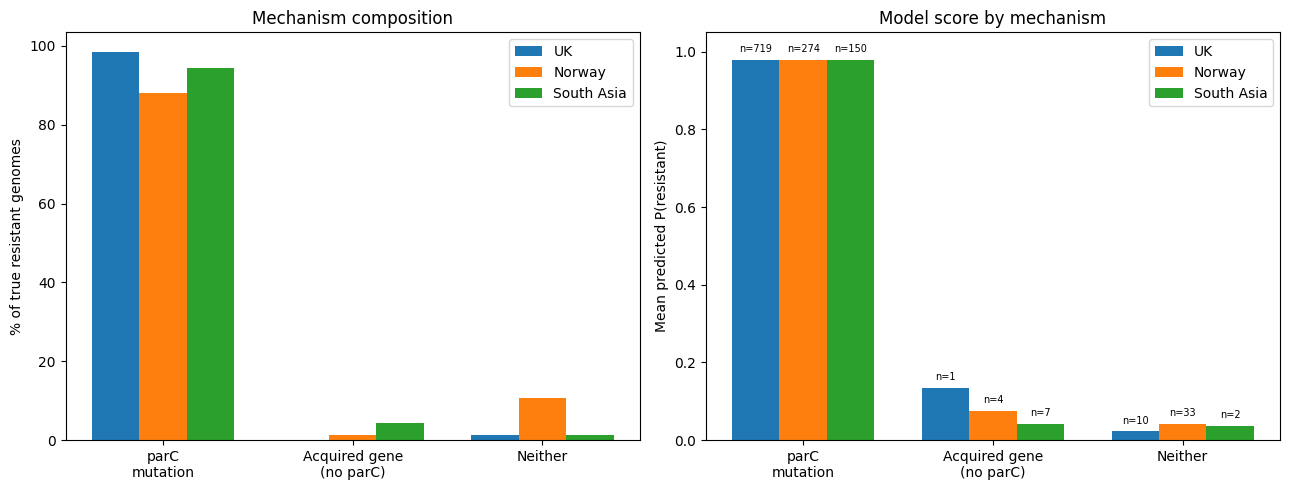

{'UK': [0.979, 0.134, 0.023], 'Norway': [0.978, 0.074, 0.042], 'South Asia': [0.979, 0.041, 0.036]} {'UK': [719, 1, 10], 'Norway': [274, 4, 33], 'South Asia': [150, 7, 2]}


In [ ]:
import numpy as np, matplotlib.pyplot as plt
def classify(r):
    if r['parC_fq_mut'] == 1: return 'parC_mutation'
    if any(r[g] == 1 for g in ['qnrA', 'qnrB', 'qnrS', 'oqxA', 'oqxB', 'aac6_Ib_cr']): return 'acquired_no_parC'
    return 'neither'
mechs = ['parC_mutation', 'acquired_no_parC', 'neither']
pcts, probs, ns = {}, {}, {}
for name, pop in [('UK', uk_model), ('Norway', norway), ('South Asia', sasia)]:
    r = pop[pop['y'] == 1].copy()
    r['mech'] = r.apply(classify, axis=1)
    r['P'] = clf_full.predict_proba(r[feature_cols].values)[:, 1]
    g = r.groupby('mech')['P'].agg(['count', 'mean']).reindex(mechs)
    ns[name] = g['count'].fillna(0).astype(int).tolist()
    pcts[name] = [100 * n / len(r) for n in ns[name]]
    probs[name] = g['mean'].fillna(0).tolist()
fig, axes = plt.subplots(1, 2, figsize=(13, 5)); x = np.arange(3); w = 0.25
for i, pop in enumerate(['UK', 'Norway', 'South Asia']):
    axes[0].bar(x + i * w, pcts[pop], w, label=pop)
    axes[1].bar(x + i * w, probs[pop], w, label=pop)
    for xi, n, pv in zip(x + i * w, ns[pop], probs[pop]):
        axes[1].text(xi, pv + 0.015, f'n={n}', ha='center', va='bottom', fontsize=7)
for ax in axes:
    ax.set_xticks(x + w); ax.set_xticklabels(['parC\nmutation', 'Acquired gene\n(no parC)', 'Neither']); ax.legend()
axes[0].set_ylabel('% of true resistant genomes'); axes[0].set_title('Mechanism composition')
axes[1].set_ylabel('Mean predicted P(resistant)'); axes[1].set_title('Model score by mechanism'); axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f'{base}/results/figure2_mechanism.png', dpi=300, bbox_inches='tight')
plt.show()
print({k: [round(v, 3) for v in probs[k]] for k in probs}, ns)

In [ ]:
import numpy as np, pandas as pd
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

ct = pd.crosstab(qc_cohort['Isolation Country'], qc_cohort['Resistant Phenotype']).reindex(columns=['Resistant', 'Susceptible'], fill_value=0)
ct['Total'] = ct.sum(axis=1)
ct['Resistant (%)'] = (100 * ct['Resistant'] / ct['Total']).round(1)
ct['At least 100 genomes per phenotype class'] = np.where((ct['Resistant'] >= 100) & (ct['Susceptible'] >= 100), 'Yes', 'No')
role = {'United Kingdom': 'Training population', 'Norway': 'External test population',
        'India': 'Pooled into South Asia case study', 'Pakistan': 'Pooled into South Asia case study', 'Bangladesh': 'Pooled into South Asia case study'}
ct['Role in this study'] = [role.get(c, 'Not used') for c in ct.index]
ct = ct.sort_values('Total', ascending=False).reset_index().rename(columns={'Isolation Country': 'Country'})

def total_row(label, r, s):
    t = int(r + s)
    return {'Country': label, 'Resistant': int(r), 'Susceptible': int(s), 'Total': t, 'Resistant (%)': round(100 * r / t, 1) if t else np.nan,
            'At least 100 genomes per phenotype class': '', 'Role in this study': ''}
miss = qc_cohort[qc_cohort['Isolation Country'].isna()]['Resistant Phenotype'].value_counts()
s1 = pd.concat([ct, pd.DataFrame([
    total_row('Subtotal, country resolved', ct['Resistant'].sum(), ct['Susceptible'].sum()),
    total_row('Country missing', miss.get('Resistant', 0), miss.get('Susceptible', 0)),
    total_row('All quality-controlled genomes', (qc_cohort['Resistant Phenotype'] == 'Resistant').sum(), (qc_cohort['Resistant Phenotype'] == 'Susceptible').sum())])],
    ignore_index=True)

s2 = pd.read_csv(f'{base}/results/table_s2_reliability.csv')
s2['Resistant (n)'] = (s2['observed_freq'] * s2['n']).round().astype(int)
s2['Population'] = s2['population'].replace({'UK': 'UK (out-of-fold)'})
s2 = s2.rename(columns={'predicted_p': 'Predicted probability', 'n': 'Genomes (n)', 'observed_freq': 'Observed resistance frequency'})
s2['Predicted probability'] = s2['Predicted probability'].round(4)
s2['Observed resistance frequency'] = s2['Observed resistance frequency'].round(4)
s2['order'] = s2['Population'].map({'UK (out-of-fold)': 0, 'Norway': 1, 'South Asia': 2})
s2 = s2.sort_values(['order', 'Predicted probability'])[['Population', 'Predicted probability', 'Genomes (n)', 'Resistant (n)', 'Observed resistance frequency']]

legends = {
 'S1': ("Supplementary Table S1. Ciprofloxacin phenotype by isolation country in the quality-controlled cohort (7,274 genomes with laboratory-method susceptibility records). "
        "England is combined with the United Kingdom, and one record with the placeholder country 'Control' is counted as missing. Only the United Kingdom and Norway have "
        "at least 100 genomes in each phenotype class. India, Pakistan and Bangladesh are pooled as the South Asia case study. One UK genome without an MLST assignment was "
        "excluded from model training and cross-validation (2,574 of 2,575 genomes used)."),
 'S2': ("Supplementary Table S2. Exact reliability table: for each distinct predicted probability produced by the model, the number of genomes, the number resistant and the "
        "observed resistance frequency. UK values are out-of-fold predictions from five MLST-grouped folds, so one feature combination can have slightly different predicted "
        "probabilities across folds; Norway and South Asia use the final model fitted on all UK genomes. Figure 1 shows the points with at least 10 genomes."),
}
out = f'{base}/results/Supplementary_Tables_S1_S2.xlsx'
with pd.ExcelWriter(out, engine='openpyxl') as xw:
    for name, df in [('S1', s1), ('S2', s2)]:
        df.to_excel(xw, sheet_name=name, index=False, startrow=3)
        ws = xw.sheets[name]
        ncol = len(df.columns)
        ws['A1'] = legends[name]
        ws['A1'].alignment = Alignment(wrap_text=True, vertical='top'); ws['A1'].font = Font(bold=True)
        ws.merge_cells(start_row=1, start_column=1, end_row=2, end_column=ncol)
        ws.row_dimensions[1].height = 55; ws.row_dimensions[2].height = 55
        for c in range(1, ncol + 1):
            cell = ws.cell(row=4, column=c)
            cell.font = Font(bold=True, color='FFFFFF'); cell.fill = PatternFill('solid', fgColor='2F5496')
            cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
            ws.column_dimensions[get_column_letter(c)].width = 34 if df.columns[c - 1] in ('Country', 'Role in this study', 'At least 100 genomes per phenotype class') else 18
        for row in ws.iter_rows(min_row=5, max_row=4 + len(df)):
            for cell in row:
                if isinstance(cell.value, (int, np.integer)): cell.number_format = '#,##0'
        ws.freeze_panes = 'A5'
s1.to_csv(f'{base}/results/table_s1_country_by_phenotype.csv', index=False)
s2.to_csv(f'{base}/results/table_s2_reliability_formatted.csv', index=False)
print(out); print(s1.to_string(index=False)); print(); print(s2.groupby('Population').size().to_string())

# Optional: phenotype counts for the 7,313 unambiguous genomes (fills two empty cells in Table 1)
pheno = pd.read_csv(f'{base}/data/raw/cip_phenotypes.csv', dtype={'Genome ID': str})
nun = pheno.groupby('Genome ID')['Resistant Phenotype'].nunique()
uniq = pheno[pheno['Genome ID'].isin(nun[nun == 1].index)].drop_duplicates('Genome ID')
print('\nTable 1, unambiguous genomes:', len(uniq)); print(uniq['Resistant Phenotype'].value_counts().to_string())

/content/drive/MyDrive/amr-calibration-geographic-shift/results/Supplementary_Tables_S1_S2.xlsx
                       Country  Resistant  Susceptible  Total  Resistant (%) At least 100 genomes per phenotype class                Role in this study
                        Norway        311         2842   3153            9.9                                      Yes          External test population
                United Kingdom        731         1844   2575           28.4                                      Yes               Training population
                           USA        284           62    346           82.1                                       No                          Not used
                      Thailand         91           48    139           65.5                                       No                          Not used
                      Portugal          3          131    134            2.2                                       No                          N

In [ ]:
from google.colab import files
import os
os.makedirs(f'{base}/docs', exist_ok=True)
up = files.upload()
for name, data in up.items():
    open(f'{base}/docs/{name}', 'wb').write(data)
print(os.listdir(f'{base}/docs'))

Saving methods_and_results_final.md to methods_and_results_final (1).md
['methods_and_results_final.md', 'methods_and_results_final (1).md']


In [ ]:
!git add results/*.txt results/*.csv results/*.png results/*.xlsx data/processed/*.csv docs/*.md

In [ ]:
import os, re, subprocess
from google.colab import userdata
os.chdir(base)
!git status --short | head -40

In [ ]:
import os, re, subprocess
from google.colab import userdata
os.chdir(base)
!git status --short | head -40

A  "docs/methods_and_results_final (1).md"
A  docs/methods_and_results_final.md
A  results/Supplementary_Tables_S1_S2.xlsx
M  results/figure2_mechanism.png
M  results/post_hoc_output.txt
M  results/table_s1_country_by_phenotype.csv
A  results/table_s2_reliability_formatted.csv
?? "methods_and_results_final (1).md"
?? methods_and_results_final.md


In [ ]:
!git rm -q --ignore-unmatch docs/methods_final.md
!git add results/*.txt results/*.csv results/*.png results/*.xlsx data/processed/*.csv docs/*.md
!git add *.ipynb
!git commit -m "Final verification outputs, supplementary tables and post hoc analyses behind the Methods and Results section"
url = subprocess.check_output(['git', 'remote', 'get-url', 'origin'], text=True).strip()
clean = re.sub(r'https://[^@/]+@', 'https://', url)
authed = clean.replace('https://', f"https://{userdata.get('GITHUB_TOKEN')}@")
!git remote set-url origin {authed}
!git push origin main
!git tag -a v1.0-methods-results -m "Code and outputs behind the Methods and Results section"
!git push origin v1.0-methods-results
!git remote set-url origin {clean}

fatal: pathspec '*.ipynb' did not match any files
[main b17eb2c] Final verification outputs, supplementary tables and post hoc analyses behind the Methods and Results section
 7 files changed, 726 insertions(+), 27 deletions(-)
 create mode 100644 docs/methods_and_results_final (1).md
 create mode 100644 docs/methods_and_results_final.md
 create mode 100644 results/Supplementary_Tables_S1_S2.xlsx
 create mode 100644 results/table_s2_reliability_formatted.csv
To https://github.com/Rita127-neup/amr-calibration-geographic-shift.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/Rita127-neup/amr-calibration-geographic-shift.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git p

In [ ]:
import os, re, shutil, subprocess
from google.colab import userdata
os.chdir(base)
token = userdata.get('GITHUB_TOKEN')

def sh(cmd, stop=True):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    out = (r.stdout + r.stderr).replace(token, '***').strip()
    print('$', cmd.replace(token, '***')); print(out, '\n')
    if stop and r.returncode != 0:
        raise SystemExit('STOPPED at the command above. Paste this output.')
    return r

# 1. one final markdown file, no stray copies
if os.path.exists('docs/methods_and_results_final (1).md'):
    shutil.move('docs/methods_and_results_final (1).md', 'docs/methods_and_results_final.md')
for f in ['methods_and_results_final.md', 'methods_and_results_final (1).md']:
    if os.path.exists(f): os.remove(f)

# 2. the two hand-typed files: append the corrections only if they are not there yet
def append_once(path, marker, text):
    s = open(path).read()
    if marker in s: print('already corrected:', path)
    else: open(path, 'a').write(text); print('correction appended:', path)
append_once(f'{base}/results/section3_4_mechanism_corrected.txt', 'CORRECTION: the statement that these 33 genomes',
    "\nCORRECTION: the statement that these 33 genomes carry none of the 8 features is wrong. They lack a parC mutation and any acquired gene; "
    "19 carry gyrA_fq_mut only and 14 carry no feature (derived from Table 3: 297 of 311 resistant Norwegian genomes carry at least one feature).\n")
append_once(f'{base}/results/qnrB_ibcr_bug_investigation.txt', 'NOTE: the counts above (qnrB 29',
    "\nNOTE: the counts above (qnrB 29, AAC(6')-Ib-cr 489) are for the pooled exports. Final counts in the 7,274-genome cohort: qnrB 28, AAC(6')-Ib-cr 485.\n")

# 3. stage, and fold into the rejected commit if it has not been pushed
sh('git add -A docs results')
sh('git fetch origin')
ahead = int(sh('git rev-list --count origin/main..HEAD').stdout.strip())
staged = sh('git diff --cached --quiet', stop=False).returncode != 0
if ahead > 0: sh('git commit --amend --no-edit')
elif staged: sh('git commit -m "Update final outputs and docs"')
sh('git log --oneline --graph --all -n 12', stop=False)

# 4. bring in what is already on GitHub, then push; the token exists only during the push
sh('git pull --rebase origin main')
clean = re.sub(r'https://[^@/]+@', 'https://', sh('git remote get-url origin').stdout.strip())
authed = clean.replace('https://', f'https://{token}@')
sh(f'git remote set-url origin {authed}')
try:
    sh('git push origin main')
    # 5. the tag must contain the notebook, so check it is in the repository first
    if not sh("git ls-files '*.ipynb'", stop=False).stdout.strip():
        raise SystemExit('No notebook is tracked in the repository. Save it first (File > Save a copy in GitHub, path notebooks/01_cohort_assembly.ipynb), then re-run this cell.')
    sh('git tag -f -a v1.0-methods-results -m "Code and outputs behind the Methods and Results section"')
    sh('git push --force origin refs/tags/v1.0-methods-results')
finally:
    sh(f'git remote set-url origin {clean}', stop=False)

# 6. checks
sh('git remote get-url origin', stop=False)
sh('git status -sb', stop=False)
sh('git rev-parse HEAD origin/main', stop=False)
sh('git ls-remote --tags origin', stop=False)
sh("git ls-files '*.ipynb' docs", stop=False)

already corrected: /content/drive/MyDrive/amr-calibration-geographic-shift/results/section3_4_mechanism_corrected.txt
already corrected: /content/drive/MyDrive/amr-calibration-geographic-shift/results/qnrB_ibcr_bug_investigation.txt
$ git add -A docs results
 

$ git fetch origin
From https://github.com/Rita127-neup/amr-calibration-geographic-shift
   7e3369d..cb5ad9a  main       -> origin/main 

$ git rev-list --count origin/main..HEAD
2 

$ git diff --cached --quiet
 

$ git commit --amend --no-edit
[main 2423c0d] Final verification outputs, supplementary tables and post hoc analyses behind the Methods and Results section
 Date: Sun Sep 20 13:09:27 2026 +0000
 6 files changed, 422 insertions(+), 27 deletions(-)
 create mode 100644 docs/methods_and_results_final.md
 create mode 100644 results/Supplementary_Tables_S1_S2.xlsx
 create mode 100644 results/table_s2_reliability_formatted.csv 

$ git log --oneline --graph --all -n 12
* 2423c0d Final verification outputs, supplementary tables

SystemExit: STOPPED at the command above. Paste this output.

/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
import os, subprocess
os.chdir(base)
def sh(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print('$', cmd); print((r.stdout + r.stderr).strip(), '\n'); return r
sh('git rebase --abort')
sh('git status -sb')
sh('git log --oneline --graph --all -n 6')
mb = sh('git merge-base HEAD origin/main').stdout.strip()
sh("git log --format='%h | %an | %ad | %s' " + f'{mb}..origin/main')
sh(f'git diff --stat {mb} origin/main')
for f in sh(f'git diff --name-only --diff-filter=A {mb} origin/main').stdout.split('\n'):
    if f.endswith(('.md', '.txt')):
        print('=====', f)
        print(subprocess.run(['git', 'show', f'origin/main:{f}'], capture_output=True, text=True).stdout[:4000])

$ git rebase --abort
 

$ git status -sb
## main...origin/main [ahead 2, behind 1] 

$ git log --oneline --graph --all -n 6
* 2423c0d Final verification outputs, supplementary tables and post hoc analyses behind the Methods and Results section
* 87d4c04 Final verification outputs and post hoc analyses behind the Methods and Results section
| * cb5ad9a Add independently rebuilt pipeline and full comparision against reported numbers
|/  
* 7e3369d Add Figure 1 (reliability diagram) and Supplementary Table S2
* e784778 Add Figure 2: mechanism composition and model score by mechanism
* c88db58 Add Figure 3: recalibration intercept (median/IQR) by sample size 

$ git merge-base HEAD origin/main
7e3369dd76686574191f34cbf107e31b7ba0df2f 

$ git log --format='%h | %an | %ad | %s' 7e3369dd76686574191f34cbf107e31b7ba0df2f..origin/main
cb5ad9a | Bishal Neupane | Sun Sep 20 09:48:07 2026 +0545 | Add independently rebuilt pipeline and full comparision against reported numbers 

$ git diff --stat 7e

In [ ]:
import os, subprocess, pandas as pd, numpy as np
os.chdir(base)
def show(ref_path, start=0):
    print(subprocess.run(['git', 'show', ref_path], capture_output=True, text=True).stdout[start:])

print('##### A. rest of FULL_COMPARISON.md')
show('origin/main:results/FULL_COMPARISON.md', start=3500)
print('\n##### B. independent pipeline code')
show('origin/main:notebooks/corrected_pipeline.py')

print('\n##### C. our saved recalibration repetitions')
for name in ['norway', 'sasia']:
    d = pd.read_csv(f'{base}/data/processed/{name}_recalibration_reps.csv')
    g = d.groupby('N')['intercept_after']
    print(name); print(pd.DataFrame({'reps': g.size(), 'median': g.median().round(3), 'q25': g.quantile(.25).round(3), 'q75': g.quantile(.75).round(3),
          'min': g.min().round(2), 'n>5': g.apply(lambda s: (s.abs() > 5).sum()), 'n>10': g.apply(lambda s: (s.abs() > 10).sum())}).to_string())

print("\n##### D. how AAC(6')-Ib-cr rows look in the raw export")
ib = pd.read_csv(f'{base}/data/raw/gene_ib-cr.csv', dtype={'Genome ID': str})
print(ib.columns.tolist(), ib.shape)
ib['Gene'] = ib['Gene'].fillna(''); ib['Function'] = ib['Function'].fillna('')
hit = ib['Gene'].str.contains('ib-cr', case=False) | ib['Function'].str.contains('ib-cr', case=False)
print('rows matching ib-cr in Gene or Function:', hit.sum(), '| genomes:', ib.loc[hit, 'Genome ID'].nunique(), '| in cohort:', len(set(ib.loc[hit, 'Genome ID']) & set(qc_cohort['Genome ID'])))
print(ib[hit].groupby(['Gene', 'Function']).agg(rows=('Genome ID', 'size'), genomes=('Genome ID', 'nunique')).sort_values('genomes', ascending=False).head(12).to_string())
print('non-matching rows:'); print(ib[~hit].groupby(['Gene', 'Function']).agg(rows=('Genome ID', 'size'), genomes=('Genome ID', 'nunique')).sort_values('genomes', ascending=False).head(8).to_string())
if 'Evidence' in ib.columns: print(ib['Evidence'].value_counts().to_string())

##### A. rest of FULL_COMPARISON.md
T131 shares 15.3%/7.9%/5.0%, ST131 resistance rates
74.9%/50.0%/91.7% — all identical. Only her already-noted 29.4% vs. 29.8%
South-Asia top-5-lineage share differs, and that was flagged as
rounding-level in her own file, not something this rebuild disputes.

## table_s2_reliability.csv — NOT YET CHECKED
Not compared line-by-line in this pass — flag if you want this one too.

## Bottom line
7 of 8 comparable result files match exactly or within rounding. The one real
open discrepancy (aac6_Ib_cr: 347 vs. ~489 genomes) causes small, consistent
downstream drift but has not been shown to change any conclusion — except the
South Asia N=200 recalibration-instability finding, which this rebuild could
not reproduce and which should be checked against her actual code before
either number is treated as final.


##### B. independent pipeline code
"""
Corrected pipeline -- applies the two independently-verified feature-
construction fixes (gyrA restricted to PO

In [ ]:
import glob, numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression as LR

# ---- V1. AAC(6')-Ib-cr: count with all rows versus after the rebuild's de-duplication ----
pool = pd.concat([pd.read_csv(f, dtype={'Genome ID': str}) for f in sorted(glob.glob(f'{base}/data/raw/gene_*.csv'))], ignore_index=True)
def ibcr_genomes(df):
    t = (df['Gene'].fillna('') + ' ' + df['Function'].fillna('')).str.lower()
    return set(df.loc[t.str.contains('ib-cr'), 'Genome ID'])
dd = pool.drop_duplicates(subset=['Genome ID', 'BRC ID', 'Source'])
a, b = ibcr_genomes(pool), ibcr_genomes(dd)
print("V1  AAC(6')-Ib-cr genomes, all rows:", len(a), '| after the rebuild de-duplication:', len(b), '| genomes lost:', len(a - b), '| rows', len(pool), '->', len(dd))

# ---- V2. Recalibration: identical splits, unpenalized (C=1e6, as in Section 2.9) versus ridge (C=1, scikit-learn default) ----
EPS = 1e-6
def lg(p): p = np.clip(p, EPS, 1 - EPS); return np.log(p / (1 - p)).reshape(-1, 1)
def recal_experiment(pop, C, Ns=(25, 50, 100, 150, 200), reps=300):
    y = pop['y'].values; p = clf_full.predict_proba(pop[feature_cols].values)[:, 1]; n = len(y); rows = []
    for N in Ns:
        vals = []
        for rep in range(reps):
            rng = np.random.default_rng(rep * 1000 + N)
            idx = rng.permutation(n); ci, ei = idx[:N], idx[N:]
            yc, ye = y[ci], y[ei]
            if yc.sum() in (0, len(yc)) or ye.sum() in (0, len(ye)): continue
            m = LR(C=C, max_iter=1000).fit(lg(p[ci]), yc)
            pe = m.predict_proba(lg(p[ei]))[:, 1]
            vals.append(LR(C=C, max_iter=1000).fit(lg(pe), ye).intercept_[0])
        v = np.array(vals)
        rows.append(dict(N=N, reps=len(v), median=np.median(v), q25=np.percentile(v, 25), q75=np.percentile(v, 75),
                         abs_gt5=int((abs(v) > 5).sum()), abs_gt10=int((abs(v) > 10).sum()), min=v.min()))
    return pd.DataFrame(rows).round(3)
for name, pop in [('Norway', norway), ('South Asia', sasia)]:
    for C in (1e6, 1.0):
        print(f'\nV2  {name}, C={C:g}'); print(recal_experiment(pop, C).to_string(index=False))

V1  AAC(6')-Ib-cr genomes, all rows: 489 | after the rebuild de-duplication: 347 | genomes lost: 142 | rows 31958 -> 23929

V2  Norway, C=1e+06
  N  reps  median    q25    q75  abs_gt5  abs_gt10    min
 25   281  -0.596 -0.751 -0.395        2         0 -7.506
 50   297  -0.336 -0.651  0.758        1         0 -3.882
100   300  -0.196 -0.631  0.723        0         0 -3.042
150   300  -0.006 -0.506  0.538        0         0 -2.413
200   300   0.051 -0.395  0.445        0         0 -1.720

V2  Norway, C=1
  N  reps  median    q25   q75  abs_gt5  abs_gt10     min
 25   281  -0.120 -0.598 0.416        1         1 -18.155
 50   297   0.191 -0.532 0.800        0         0  -3.003
100   300   0.094 -0.480 0.682        0         0  -2.844
150   300   0.071 -0.447 0.536        0         0  -2.236
200   300   0.063 -0.380 0.444        0         0  -1.607

V2  South Asia, C=1e+06
  N  reps  median    q25   q75  abs_gt5  abs_gt10     min
 25   300  -0.205 -0.800 1.111       16         3  -6.621
 5

In [ ]:
import os, re, glob, shutil, subprocess
import numpy as np
from google.colab import userdata, files
from sklearn.linear_model import LogisticRegression as LR

token = userdata.get('GITHUB_TOKEN')
REPO = 'https://github.com/Rita127-neup/amr-calibration-geographic-shift.git'
CL = '/content/repo_final'

def git(*args, cwd=CL, stop=True, show=True):
    r = subprocess.run(['git', *args], cwd=cwd, capture_output=True, text=True)
    out = (r.stdout + r.stderr).replace(token, '***').strip()
    if show: print('$ git', ' '.join(args).replace(token, '***')); print(out, '\n')
    if stop and r.returncode != 0: raise SystemExit('STOPPED at the command above. Paste this output.')
    return r

def final_push():
    # 1. fresh clone on the local disk (not Drive), so it includes everything already on GitHub
    shutil.rmtree(CL, ignore_errors=True)
    git('clone', REPO, CL, cwd='/content')
    git('log', '--oneline', '-3')

    # 2. upload the files from this chat
    os.chdir('/content')
    print('Select together: methods_and_results_final.md, RECONCILIATION.md, reconciliation_checks.py (add the notebook .ipynb only if this cell asks for it)')
    up = files.upload()
    def pick(prefix):
        m = [n for n in up if n.startswith(prefix)]
        if not m: raise SystemExit(f'Missing upload: {prefix}*')
        return max(m, key=os.path.getmtime)
    for d in ('docs', 'results', 'notebooks'): os.makedirs(f'{CL}/{d}', exist_ok=True)
    shutil.copy2(pick('methods_and_results_final'), f'{CL}/docs/methods_and_results_final.md')
    shutil.copy2(pick('RECONCILIATION'), f'{CL}/results/RECONCILIATION.md')
    shutil.copy2(pick('reconciliation_checks'), f'{CL}/notebooks/reconciliation_checks.py')

    # 3. copy the final outputs from Drive; the rebuild's own files are never touched
    protect = {'pipeline_output.txt', 'FULL_COMPARISON.md', 'RESULTS_SUMMARY.md', 'RECONCILIATION.md'}
    n = 0
    for pat in ['results/*.txt', 'results/*.csv', 'results/*.png', 'results/*.xlsx', 'data/processed/*.csv']:
        for f in glob.glob(f'{base}/{pat}'):
            if os.path.basename(f) in protect: continue
            dst = f'{CL}/{os.path.relpath(f, base)}'; os.makedirs(os.path.dirname(dst), exist_ok=True); shutil.copy2(f, dst); n += 1
    print('copied', n, 'files from Drive\n')

    # 4. calibration slope and intercept with and without the ridge penalty
    def lg(p): p = np.clip(p, 1e-6, 1 - 1e-6); return np.log(p / (1 - p)).reshape(-1, 1)
    lines = ['Calibration slope and intercept with C=1e6 (unpenalized, as in Section 2.8) and C=1 (scikit-learn default), same predictions.',
             'Rebuild values (C=1, from results/pipeline_output.txt): UK 1.092 / -0.116, Norway 0.720 / -0.507, South Asia 0.774 / 0.918.']
    for name, y, p in [('UK (OOF)', y_uk, oof_proba), ('Norway', y_norway, p_norway), ('South Asia', y_sasia, p_sasia)]:
        a = LR(C=1e6, max_iter=1000).fit(lg(p), y); b = LR(C=1.0, max_iter=1000).fit(lg(p), y)
        lines.append(f'{name}: C=1e6 slope {a.coef_[0][0]:.3f} intercept {a.intercept_[0]:.3f} | C=1 slope {b.coef_[0][0]:.3f} intercept {b.intercept_[0]:.3f}')
    open(f'{CL}/results/calibration_penalty_check.txt', 'w').write('\n'.join(lines) + '\n'); print('\n'.join(lines), '\n')

    # 5. the notebook: from the upload, the repo folder or Colab Notebooks; refuse if a token is inside
    cands = [f'/content/{m}' for m in up if m.endswith('.ipynb')] + glob.glob(f'{base}/*.ipynb') + glob.glob('/content/drive/MyDrive/Colab Notebooks/01_cohort_assembly*.ipynb')
    if not cands: raise SystemExit('Notebook not found. Use File > Download > Download .ipynb, then run this cell again and select it with the three files.')
    nb = max(cands, key=os.path.getmtime); print('notebook:', nb)
    shutil.copy2(nb, f'{CL}/notebooks/01_cohort_assembly.ipynb')

    # 6. scan everything that will be published for the token
    for root, dirs, fs in os.walk(CL):
        dirs[:] = [d for d in dirs if d != '.git']
        for fn in fs:
            t = open(os.path.join(root, fn), encoding='utf8', errors='ignore').read()
            if token in t or re.search(r'gh[pousr]_[A-Za-z0-9]{30,}|github_pat_[A-Za-z0-9_]{30,}', t):
                raise SystemExit(f'A GitHub token appears in {os.path.join(root, fn)}. Revoke it, remove it from that file, and run again.')

    # 7. commit and push (the token is used only in the push command, never stored)
    for k in ('user.name', 'user.email'):
        v = git('config', k, cwd=base, stop=False, show=False).stdout.strip()
        if v: git('config', k, v, show=False)
    git('rm', '-q', '--ignore-unmatch', 'docs/methods_final.md')
    git('add', '-A')
    git('status', '--short', stop=False)
    git('commit', '-m', 'Final Methods and Results, supplementary tables, verification outputs and reconciliation note')
    authed = REPO.replace('https://', f'https://{token}@')
    git('push', authed, 'HEAD:main')
    git('tag', '-f', '-a', 'v1.0-methods-results', '-m', 'Code and outputs behind the Methods and Results section')
    git('push', '--force', authed, 'refs/tags/v1.0-methods-results')

    # 8. checks
    head = git('rev-parse', 'HEAD', show=False).stdout.strip()
    tags = git('ls-remote', '--tags', REPO, show=False).stdout
    main = git('ls-remote', REPO, 'refs/heads/main', show=False).stdout
    print('GitHub main == this commit:', head in main, '| tag points to this commit:', f'{head}\trefs/tags/v1.0-methods-results^{{}}' in tags)
    print('remote URL of the clone (must have no token):', git('remote', 'get-url', 'origin', show=False).stdout.strip())

final_push()

$ git clone https://github.com/Rita127-neup/amr-calibration-geographic-shift.git /content/repo_final
Cloning into '/content/repo_final'... 

$ git log --oneline -3
cb5ad9a Add independently rebuilt pipeline and full comparision against reported numbers
7e3369d Add Figure 1 (reliability diagram) and Supplementary Table S2
e784778 Add Figure 2: mechanism composition and model score by mechanism 

Select together: methods_and_results_final.md, RECONCILIATION.md, reconciliation_checks.py (add the notebook .ipynb only if this cell asks for it)


Saving RECONCILIATION.md to RECONCILIATION.md


SystemExit: Missing upload: methods_and_results_final*

/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
import os, re, glob, shutil, subprocess
import numpy as np
from google.colab import userdata, files
from sklearn.linear_model import LogisticRegression as LR

token = userdata.get('GITHUB_TOKEN')
REPO = 'https://github.com/Rita127-neup/amr-calibration-geographic-shift.git'
CL = '/content/repo_final'

def git(*args, cwd=CL, stop=True, show=True):
    r = subprocess.run(['git', *args], cwd=cwd, capture_output=True, text=True)
    out = (r.stdout + r.stderr).replace(token, '***').strip()
    if show: print('$ git', ' '.join(args).replace(token, '***')); print(out, '\n')
    if stop and r.returncode != 0: raise SystemExit('STOPPED at the command above. Paste this output.')
    return r

def final_push():
    # 1. fresh clone on the local disk (not Drive), so it includes everything already on GitHub
    shutil.rmtree(CL, ignore_errors=True)
    git('clone', REPO, CL, cwd='/content')
    git('log', '--oneline', '-3')

    # 2. upload the files from this chat
    os.chdir('/content')
    print('Select together: methods_and_results_final.md, RECONCILIATION.md, reconciliation_checks.py (add the notebook .ipynb only if this cell asks for it)')
    up = files.upload()
    def pick(prefix):
        m = [n for n in up if n.startswith(prefix)]
        if not m: raise SystemExit(f'Missing upload: {prefix}*')
        return max(m, key=os.path.getmtime)
    for d in ('docs', 'results', 'notebooks'): os.makedirs(f'{CL}/{d}', exist_ok=True)
    shutil.copy2(pick('methods_and_results_final'), f'{CL}/docs/methods_and_results_final.md')
    shutil.copy2(pick('RECONCILIATION'), f'{CL}/results/RECONCILIATION.md')
    shutil.copy2(pick('reconciliation_checks'), f'{CL}/notebooks/reconciliation_checks.py')

    # 3. copy the final outputs from Drive; the rebuild's own files are never touched
    protect = {'pipeline_output.txt', 'FULL_COMPARISON.md', 'RESULTS_SUMMARY.md', 'RECONCILIATION.md'}
    n = 0
    for pat in ['results/*.txt', 'results/*.csv', 'results/*.png', 'results/*.xlsx', 'data/processed/*.csv']:
        for f in glob.glob(f'{base}/{pat}'):
            if os.path.basename(f) in protect: continue
            dst = f'{CL}/{os.path.relpath(f, base)}'; os.makedirs(os.path.dirname(dst), exist_ok=True); shutil.copy2(f, dst); n += 1
    print('copied', n, 'files from Drive\n')

    # 4. calibration slope and intercept with and without the ridge penalty
    def lg(p): p = np.clip(p, 1e-6, 1 - 1e-6); return np.log(p / (1 - p)).reshape(-1, 1)
    lines = ['Calibration slope and intercept with C=1e6 (unpenalized, as in Section 2.8) and C=1 (scikit-learn default), same predictions.',
             'Rebuild values (C=1, from results/pipeline_output.txt): UK 1.092 / -0.116, Norway 0.720 / -0.507, South Asia 0.774 / 0.918.']
    for name, y, p in [('UK (OOF)', y_uk, oof_proba), ('Norway', y_norway, p_norway), ('South Asia', y_sasia, p_sasia)]:
        a = LR(C=1e6, max_iter=1000).fit(lg(p), y); b = LR(C=1.0, max_iter=1000).fit(lg(p), y)
        lines.append(f'{name}: C=1e6 slope {a.coef_[0][0]:.3f} intercept {a.intercept_[0]:.3f} | C=1 slope {b.coef_[0][0]:.3f} intercept {b.intercept_[0]:.3f}')
    open(f'{CL}/results/calibration_penalty_check.txt', 'w').write('\n'.join(lines) + '\n'); print('\n'.join(lines), '\n')

    # 5. the notebook: from the upload, the repo folder or Colab Notebooks; refuse if a token is inside
    cands = [f'/content/{m}' for m in up if m.endswith('.ipynb')] + glob.glob(f'{base}/*.ipynb') + glob.glob('/content/drive/MyDrive/Colab Notebooks/01_cohort_assembly*.ipynb')
    if not cands: raise SystemExit('Notebook not found. Use File > Download > Download .ipynb, then run this cell again and select it with the three files.')
    nb = max(cands, key=os.path.getmtime); print('notebook:', nb)
    shutil.copy2(nb, f'{CL}/notebooks/01_cohort_assembly.ipynb')

    # 6. scan everything that will be published for the token
    for root, dirs, fs in os.walk(CL):
        dirs[:] = [d for d in dirs if d != '.git']
        for fn in fs:
            t = open(os.path.join(root, fn), encoding='utf8', errors='ignore').read()
            if token in t or re.search(r'gh[pousr]_[A-Za-z0-9]{30,}|github_pat_[A-Za-z0-9_]{30,}', t):
                raise SystemExit(f'A GitHub token appears in {os.path.join(root, fn)}. Revoke it, remove it from that file, and run again.')

    # 7. commit and push (the token is used only in the push command, never stored)
    for k in ('user.name', 'user.email'):
        v = git('config', k, cwd=base, stop=False, show=False).stdout.strip()
        if v: git('config', k, v, show=False)
    git('rm', '-q', '--ignore-unmatch', 'docs/methods_final.md')
    git('add', '-A')
    git('status', '--short', stop=False)
    git('commit', '-m', 'Final Methods and Results, supplementary tables, verification outputs and reconciliation note')
    authed = REPO.replace('https://', f'https://{token}@')
    git('push', authed, 'HEAD:main')
    git('tag', '-f', '-a', 'v1.0-methods-results', '-m', 'Code and outputs behind the Methods and Results section')
    git('push', '--force', authed, 'refs/tags/v1.0-methods-results')

    # 8. checks
    head = git('rev-parse', 'HEAD', show=False).stdout.strip()
    tags = git('ls-remote', '--tags', REPO, show=False).stdout
    main = git('ls-remote', REPO, 'refs/heads/main', show=False).stdout
    print('GitHub main == this commit:', head in main, '| tag points to this commit:', f'{head}\trefs/tags/v1.0-methods-results^{{}}' in tags)
    print('remote URL of the clone (must have no token):', git('remote', 'get-url', 'origin', show=False).stdout.strip())

final_push()

$ git clone https://github.com/Rita127-neup/amr-calibration-geographic-shift.git /content/repo_final
Cloning into '/content/repo_final'... 

$ git log --oneline -3
cb5ad9a Add independently rebuilt pipeline and full comparision against reported numbers
7e3369d Add Figure 1 (reliability diagram) and Supplementary Table S2
e784778 Add Figure 2: mechanism composition and model score by mechanism 

Select together: methods_and_results_final.md, RECONCILIATION.md, reconciliation_checks.py (add the notebook .ipynb only if this cell asks for it)


Saving methods_and_results_final (1).md to methods_and_results_final (1) (1).md


SystemExit: Missing upload: RECONCILIATION*

/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
import os, re, glob, shutil, subprocess
import numpy as np
from google.colab import userdata, files
from sklearn.linear_model import LogisticRegression as LR

token = userdata.get('GITHUB_TOKEN')
REPO = 'https://github.com/Rita127-neup/amr-calibration-geographic-shift.git'
CL = '/content/repo_final'

def git(*args, cwd=CL, stop=True, show=True):
    r = subprocess.run(['git', *args], cwd=cwd, capture_output=True, text=True)
    out = (r.stdout + r.stderr).replace(token, '***').strip()
    if show: print('$ git', ' '.join(args).replace(token, '***')); print(out, '\n')
    if stop and r.returncode != 0: raise SystemExit('STOPPED at the command above. Paste this output.')
    return r

def final_push():
    # 1. fresh clone on the local disk (not Drive), so it includes everything already on GitHub
    shutil.rmtree(CL, ignore_errors=True)
    git('clone', REPO, CL, cwd='/content')
    git('log', '--oneline', '-3')

    # 2. upload the three files from this chat (all at once, or one at a time)
    os.chdir('/content')
    match = {
        'methods_and_results_final.md': lambda n: n.lower().startswith('methods_and_results_final') and n.lower().endswith('.md'),
        'RECONCILIATION.md': lambda n: n.lower().startswith('reconciliation') and n.lower().endswith('.md'),
        'reconciliation_checks.py': lambda n: n.lower().startswith('reconciliation_checks') and n.lower().endswith('.py'),
    }
    got, nbs = {}, []
    while len(got) < 3:
        print('Still needed:', ', '.join(k for k in match if k not in got), '(select several files at once, or upload them one at a time)')
        new = files.upload()
        if not new: raise SystemExit('No file received.')
        for n in new:
            if n.endswith('.ipynb'): nbs.append(os.path.abspath(n))
            for k, f in match.items():
                if f(n): got[k] = os.path.abspath(n)
    if 'post hoc sensitivity analysis' not in open(got['methods_and_results_final.md'], encoding='utf8', errors='ignore').read():
        raise SystemExit('This methods_and_results_final.md is an older version. Download it again from the chat and run the cell again.')
    for d in ('docs', 'results', 'notebooks'): os.makedirs(f'{CL}/{d}', exist_ok=True)
    shutil.copy2(got['methods_and_results_final.md'], f'{CL}/docs/methods_and_results_final.md')
    shutil.copy2(got['RECONCILIATION.md'], f'{CL}/results/RECONCILIATION.md')
    shutil.copy2(got['reconciliation_checks.py'], f'{CL}/notebooks/reconciliation_checks.py')

    # 3. copy the final outputs from Drive; the rebuild's own files are never touched
    protect = {'pipeline_output.txt', 'FULL_COMPARISON.md', 'RESULTS_SUMMARY.md', 'RECONCILIATION.md'}
    n = 0
    for pat in ['results/*.txt', 'results/*.csv', 'results/*.png', 'results/*.xlsx', 'data/processed/*.csv']:
        for f in glob.glob(f'{base}/{pat}'):
            if os.path.basename(f) in protect: continue
            dst = f'{CL}/{os.path.relpath(f, base)}'; os.makedirs(os.path.dirname(dst), exist_ok=True); shutil.copy2(f, dst); n += 1
    print('copied', n, 'files from Drive\n')

    # 4. calibration slope and intercept with and without the ridge penalty
    def lg(p): p = np.clip(p, 1e-6, 1 - 1e-6); return np.log(p / (1 - p)).reshape(-1, 1)
    lines = ['Calibration slope and intercept with C=1e6 (unpenalized, as in Section 2.8) and C=1 (scikit-learn default), same predictions.',
             'Rebuild values (C=1, from results/pipeline_output.txt): UK 1.092 / -0.116, Norway 0.720 / -0.507, South Asia 0.774 / 0.918.']
    for name, y, p in [('UK (OOF)', y_uk, oof_proba), ('Norway', y_norway, p_norway), ('South Asia', y_sasia, p_sasia)]:
        a = LR(C=1e6, max_iter=1000).fit(lg(p), y); b = LR(C=1.0, max_iter=1000).fit(lg(p), y)
        lines.append(f'{name}: C=1e6 slope {a.coef_[0][0]:.3f} intercept {a.intercept_[0]:.3f} | C=1 slope {b.coef_[0][0]:.3f} intercept {b.intercept_[0]:.3f}')
    open(f'{CL}/results/calibration_penalty_check.txt', 'w').write('\n'.join(lines) + '\n'); print('\n'.join(lines), '\n')

    # 5. the notebook: from an upload, the repo folder or Colab Notebooks; refuse if a token is inside
    cands = nbs + glob.glob(f'{base}/*.ipynb') + glob.glob('/content/drive/MyDrive/Colab Notebooks/01_cohort_assembly*.ipynb')
    if not cands: raise SystemExit('Notebook not found. Use File > Download > Download .ipynb, then run this cell again and upload it together with the three files.')
    nb = max(cands, key=os.path.getmtime); print('notebook:', nb)
    shutil.copy2(nb, f'{CL}/notebooks/01_cohort_assembly.ipynb')

    # 6. scan everything that will be published for the token
    for root, dirs, fs in os.walk(CL):
        dirs[:] = [d for d in dirs if d != '.git']
        for fn in fs:
            t = open(os.path.join(root, fn), encoding='utf8', errors='ignore').read()
            if token in t or re.search(r'gh[pousr]_[A-Za-z0-9]{30,}|github_pat_[A-Za-z0-9_]{30,}', t):
                raise SystemExit(f'A GitHub token appears in {os.path.join(root, fn)}. Revoke it, remove it from that file, and run again.')

    # 7. commit and push (the token is used only in the push command, never stored)
    for k in ('user.name', 'user.email'):
        v = git('config', k, cwd=base, stop=False, show=False).stdout.strip()
        if v: git('config', k, v, show=False)
    git('rm', '-q', '--ignore-unmatch', 'docs/methods_final.md')
    git('add', '-A')
    git('status', '--short', stop=False)
    git('commit', '-m', 'Final Methods and Results, supplementary tables, verification outputs and reconciliation note')
    authed = REPO.replace('https://', f'https://{token}@')
    git('push', authed, 'HEAD:main')
    git('tag', '-f', '-a', 'v1.0-methods-results', '-m', 'Code and outputs behind the Methods and Results section')
    git('push', '--force', authed, 'refs/tags/v1.0-methods-results')

    # 8. checks
    head = git('rev-parse', 'HEAD', show=False).stdout.strip()
    tags = git('ls-remote', '--tags', REPO, show=False).stdout
    main = git('ls-remote', REPO, 'refs/heads/main', show=False).stdout
    print('GitHub main == this commit:', head in main, '| tag points to this commit:', f'{head}\trefs/tags/v1.0-methods-results^{{}}' in tags)
    print('remote URL of the clone (must have no token):', git('remote', 'get-url', 'origin', show=False).stdout.strip())

final_push()

$ git clone https://github.com/Rita127-neup/amr-calibration-geographic-shift.git /content/repo_final
Cloning into '/content/repo_final'... 

$ git log --oneline -3
cb5ad9a Add independently rebuilt pipeline and full comparision against reported numbers
7e3369d Add Figure 1 (reliability diagram) and Supplementary Table S2
e784778 Add Figure 2: mechanism composition and model score by mechanism 

Still needed: methods_and_results_final.md, RECONCILIATION.md, reconciliation_checks.py (select several files at once, or upload them one at a time)


Saving methods_and_results_final (1).md to methods_and_results_final (1) (2).md
Still needed: RECONCILIATION.md, reconciliation_checks.py (select several files at once, or upload them one at a time)


Saving RECONCILIATION.md to RECONCILIATION (1).md
Still needed: reconciliation_checks.py (select several files at once, or upload them one at a time)


Saving reconciliation_checks.py to reconciliation_checks.py
copied 23 files from Drive

Calibration slope and intercept with C=1e6 (unpenalized, as in Section 2.8) and C=1 (scikit-learn default), same predictions.
Rebuild values (C=1, from results/pipeline_output.txt): UK 1.092 / -0.116, Norway 0.720 / -0.507, South Asia 0.774 / 0.918.
UK (OOF): C=1e6 slope 1.092 intercept -0.041 | C=1 slope 1.088 intercept -0.039
Norway: C=1e6 slope 0.726 intercept -0.488 | C=1 slope 0.725 intercept -0.488
South Asia: C=1e6 slope 0.786 intercept 0.927 | C=1 slope 0.778 intercept 0.918 

notebook: /content/drive/MyDrive/Colab Notebooks/01_cohort_assembly.ipynb
$ git rm -q --ignore-unmatch docs/methods_final.md
 

$ git add -A
 

$ git status --short
A  docs/methods_and_results_final.md
D  docs/methods_final.md
A  notebooks/01_cohort_assembly.ipynb
A  notebooks/reconciliation_checks.py
A  results/RECONCILIATION.md
A  results/Supplementary_Tables_S1_S2.xlsx
A  results/calibration_penalty_check.txt
M  res

In [ ]:
import os, re, subprocess
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
REPO = 'https://github.com/Rita127-neup/amr-calibration-geographic-shift.git'
CL = '/content/repo_final'

def git(*args, cwd=CL, stop=True, show=True):
    r = subprocess.run(['git', *args], cwd=cwd, capture_output=True, text=True)
    out = (r.stdout + r.stderr).replace(token, '***').strip()
    if show: print('$ git', ' '.join(args).replace(token, '***')); print(out, '\n')
    if stop and r.returncode != 0: raise SystemExit('STOPPED at the command above. Paste this output.')
    return r

def fix_note():
    if not os.path.isdir(f'{CL}/.git'): raise SystemExit('/content/repo_final is missing (the runtime restarted). Tell me and I will give you a version that clones again.')
    git('pull', '--rebase', REPO, 'main')
    for k, fmt in (('user.name', '%an'), ('user.email', '%ae')):    # reuse the identity of the previous commit
        if not git('config', k, stop=False, show=False).stdout.strip():
            git('config', k, git('log', '-1', f'--format={fmt}', show=False).stdout.strip(), show=False)
    # 1. correct the calibration row in RECONCILIATION.md
    p = f'{CL}/results/RECONCILIATION.md'
    s = open(p, encoding='utf8').read()
    OLD = "| 3 | Calibration slopes and intercepts differ slightly (UK intercept -0.116 against -0.041; Norway -0.507 against -0.488; South Asia 0.918 against 0.927) | The re-implementation's calibration fit also uses the default ridge penalty. Its AAC(6')-Ib-cr and gyrA rules also differ, and it keeps the one UK genome without an MLST assignment (2,575 genomes, as its own group), so its folds differ. | `results/calibration_penalty_check.txt` compares C = 10^6 and C = 1 on the reported predictions. The UK value lies inside the reported interval (-0.654 to 0.306). | None. |"
    NEW = "| 3 | Calibration slopes and intercepts differ slightly (UK intercept -0.116 against -0.041; Norway -0.507 against -0.488; South Asia 0.918 against 0.927) | South Asia: the ridge penalty in the re-implementation's calibration fit. UK and Norway: not the penalty. The re-implementation's AAC(6')-Ib-cr and gyrA rules also differ, and it keeps the one UK genome without an MLST assignment (2,575 genomes, as its own group), so its model and folds differ. This was not tested separately. | `results/calibration_penalty_check.txt` refits the calibration on the reported predictions: with C = 1 the South Asia intercept is 0.918 (the re-implementation reports 0.918), while the UK (-0.039) and Norway (-0.488) intercepts barely change. The UK difference lies inside the reported interval (-0.654 to 0.306). | None. |"
    if NEW in s: print('RECONCILIATION.md already corrected')
    else:
        if OLD not in s: raise SystemExit('The calibration row in RECONCILIATION.md is not what I expected. Paste the file here.')
        open(p, 'w', encoding='utf8').write(s.replace(OLD, NEW)); print('RECONCILIATION.md corrected')
    # 2. notes for readers in the README (added once)
    rp = f'{CL}/README.md'
    r = open(rp, encoding='utf8').read() if os.path.exists(rp) else ''
    ADD = '\n## Notes for readers\n\n- The final Methods and Results text is `docs/methods_and_results_final.md`; its tables and figures are in `results/`.\n- `results/RECONCILIATION.md` records how the differences flagged in `results/FULL_COMPARISON.md` (the second re-implementation) were resolved.\n- `results/table3_4_full_bootstrap_CIs.txt` reports bootstrap means with percentile intervals. The manuscript reports point estimates with the same intervals; `results/final_checks_output.txt` (block D5) recomputes the point estimates and intervals.\n- An earlier notebook cell for Figure 2 hard-coded the mean predicted probability of acquired-gene-only genomes (0.118, 0.098, 0.069). Those values were wrong and were replaced by values computed from the fitted model (0.134, 0.074, 0.041; `results/final_checks_output.txt`, block D1). `results/figure2_mechanism.png` was regenerated from the model.\n'
    if '## Notes for readers' in r: print('README already has the notes')
    else: open(rp, 'a', encoding='utf8').write(ADD); print('README notes added')
    git('add', '-A')
    git('status', '--short', stop=False)
    if git('diff', '--cached', '--quiet', stop=False, show=False).returncode == 0: raise SystemExit('Nothing to commit; the fix is already in place.')
    git('commit', '-m', 'Correct the calibration row in the reconciliation note; add notes for readers to the README')
    authed = REPO.replace('https://', f'https://{token}@')
    git('push', authed, 'HEAD:main')
    git('tag', '-f', '-a', 'v1.0-methods-results', '-m', 'Code and outputs behind the Methods and Results section')
    git('push', '--force', authed, 'refs/tags/v1.0-methods-results')
    head = git('rev-parse', 'HEAD', show=False).stdout.strip()
    tags = git('ls-remote', '--tags', REPO, show=False).stdout
    main = git('ls-remote', REPO, 'refs/heads/main', show=False).stdout
    print('GitHub main == this commit:', head in main, '| tag points to this commit:', f'{head}\trefs/tags/v1.0-methods-results^{{}}' in tags)
    print('remote URL of the clone (must have no token):', git('remote', 'get-url', 'origin', show=False).stdout.strip())

fix_note()

$ git pull --rebase https://github.com/Rita127-neup/amr-calibration-geographic-shift.git main
Already up to date.
From https://github.com/Rita127-neup/amr-calibration-geographic-shift
 * branch            main       -> FETCH_HEAD 

RECONCILIATION.md corrected
README notes added
$ git add -A
 

$ git status --short
M  README.md
M  results/RECONCILIATION.md 

$ git commit -m Correct the calibration row in the reconciliation note; add notes for readers to the README
[main 6e6d53e] Correct the calibration row in the reconciliation note; add notes for readers to the README
 2 files changed, 8 insertions(+), 1 deletion(-) 

$ git push https://***@github.com/Rita127-neup/amr-calibration-geographic-shift.git HEAD:main
To https://github.com/Rita127-neup/amr-calibration-geographic-shift.git
   7945378..6e6d53e  HEAD -> main 

$ git tag -f -a v1.0-methods-results -m Code and outputs behind the Methods and Results section
Updated tag 'v1.0-methods-results' (was 348eb0f) 

$ git push --force https:

In [1]:
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression as LR
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, matthews_corrcoef

# ---- G1. Genomes with a parC mutation and no other feature, and with parC plus gyrA: how many, and how many resistant ----
others = [c for c in feature_cols if c != 'parC_fq_mut']
for name, pop in [('UK', uk_model), ('Norway', norway), ('South Asia', sasia)]:
    po = pop[(pop['parC_fq_mut'] == 1) & (pop[others].sum(axis=1) == 0)]
    pg = pop[(pop['parC_fq_mut'] == 1) & (pop['gyrA_fq_mut'] == 1)]
    print(f'G1  {name:11s} parC only: {len(po):4d} (resistant {int(po["y"].sum()):3d}) | parC and gyrA: {len(pg):4d} (resistant {int(pg["y"].sum()):3d})')

# ---- G2. Does gyrA, or the plasmid-mediated genes, add anything beyond parC? Same folds, paired bootstrap ----
groups_uk = uk_model['MLST'].values; y_uk = uk_model['y'].values
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
mk = lambda: LR(penalty=None, solver='lbfgs', max_iter=5000)
def fit_predict(cols):
    X = uk_model[cols].values
    p_uk = cross_val_predict(mk(), X, y_uk, cv=sgkf, groups=groups_uk, method='predict_proba')[:, 1]
    m = mk().fit(X, y_uk)
    return {'UK': p_uk, 'Norway': m.predict_proba(norway[cols].values)[:, 1], 'South Asia': m.predict_proba(sasia[cols].values)[:, 1]}
P1 = fit_predict(['parC_fq_mut']); P2 = fit_predict(['parC_fq_mut', 'gyrA_fq_mut'])
P8 = {'UK': oof_proba, 'Norway': p_norway, 'South Asia': p_sasia}
Y = {'UK': y_uk, 'Norway': norway['y'].values, 'South Asia': sasia['y'].values}
def mcc(y, p): return matthews_corrcoef(y, (p >= 0.5).astype(int))
for pop, y in Y.items():
    print(f'\nG2  {pop}: two-feature model (parC + gyrA)  AUROC {roc_auc_score(y, P2[pop]):.3f}  MCC {mcc(y, P2[pop]):.3f}')
    pairs = {'parC + gyrA minus parC only': (P2[pop], P1[pop]), 'eight features minus parC + gyrA': (P8[pop], P2[pop])}
    rng = np.random.default_rng(0); boots = {k: ([], []) for k in pairs}
    for _ in range(1000):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) < 2: continue
        for k, (a, b) in pairs.items():
            boots[k][0].append(roc_auc_score(y[i], a[i]) - roc_auc_score(y[i], b[i])); boots[k][1].append(mcc(y[i], a[i]) - mcc(y[i], b[i]))
    for k, (a, b) in pairs.items():
        dA, dM = roc_auc_score(y, a) - roc_auc_score(y, b), mcc(y, a) - mcc(y, b)
        lA, hA = np.percentile(boots[k][0], [2.5, 97.5]); lM, hM = np.percentile(boots[k][1], [2.5, 97.5])
        print(f'    {k:34s} AUROC {dA:+.3f} ({lA:+.3f} to {hA:+.3f})   MCC {dM:+.3f} ({lM:+.3f} to {hM:+.3f})')

NameError: name 'feature_cols' is not defined

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict

base = '/content/drive/MyDrive/amr-calibration-geographic-shift'
qc_cohort = pd.read_csv(f'{base}/data/processed/qc_cohort_final_features.csv', dtype={'Genome ID': str})
qc_cohort['y'] = (qc_cohort['Resistant Phenotype'] == 'Resistant').astype(int)
feature_cols = ['gyrA_fq_mut','parC_fq_mut','qnrA','qnrB','qnrS','oqxA','oqxB','aac6_Ib_cr']

uk = qc_cohort[qc_cohort['Isolation Country'] == 'United Kingdom'].copy()
norway = qc_cohort[qc_cohort['Isolation Country'] == 'Norway'].copy()
sasia = qc_cohort[qc_cohort['Isolation Country'].isin(['India','Pakistan','Bangladesh'])].copy()
uk_model = uk.dropna(subset=['MLST']).copy()

X_uk, y_uk, groups_uk = uk_model[feature_cols].values, uk_model['y'].values, uk_model['MLST'].values
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
clf = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, solver='saga', max_iter=5000, C=1.0)
oof_proba = cross_val_predict(clf, X_uk, y_uk, cv=sgkf, groups=groups_uk, method='predict_proba')[:, 1]
clf_full = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, solver='saga', max_iter=5000, C=1.0).fit(X_uk, y_uk)

p_norway, y_norway = clf_full.predict_proba(norway[feature_cols].values)[:, 1], norway['y'].values
p_sasia, y_sasia = clf_full.predict_proba(sasia[feature_cols].values)[:, 1], sasia['y'].values

print(len(uk_model), len(norway), len(sasia), '(expect 2574 3153 238)')
print(dict(zip(feature_cols, clf_full.coef_[0].round(3))), round(clf_full.intercept_[0], 3))

Mounted at /content/drive
2574 3153 238 (expect 2574 3153 238)
{'gyrA_fq_mut': np.float64(3.741), 'parC_fq_mut': np.float64(6.266), 'qnrA': np.float64(0.0), 'qnrB': np.float64(0.707), 'qnrS': np.float64(0.0), 'oqxA': np.float64(0.0), 'oqxB': np.float64(0.0), 'aac6_Ib_cr': np.float64(0.871)} -6.315


In [3]:
import numpy as np, pandas as pd
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold

pops = {'UK': uk, 'Norway': norway, 'South Asia': sasia}

# ---- H1. BioProject: missingness, top-accession share, overlap between populations; genome-ID overlap ----
print('=== H1: BioProject and identifier overlap ===')
bp = 'BioProject Accession'; acc = {}
for name, df in pops.items():
    s = df[bp]; vc = s.value_counts()
    print(f'{name:11s} missing {100 * s.isna().mean():5.1f}% | non-missing {int(s.notna().sum()):5d} | top accession {vc.index[0] if len(vc) else "none"} = {100 * vc.iloc[0] / max(1, int(s.notna().sum())):.1f}% of non-missing')
    acc[name] = set(s.dropna())
for a, b in [('UK', 'Norway'), ('UK', 'South Asia'), ('Norway', 'South Asia')]:
    print(f'shared BioProject accessions {a} / {b}: {len(acc[a] & acc[b])} | shared Genome IDs: {len(set(pops[a]["Genome ID"]) & set(pops[b]["Genome ID"]))}')

# ---- H2. Fold class balance when grouping by MLST ----
print('\n=== H2: % resistant per fold, UK grouped by MLST ===')
X_uk = uk_model[feature_cols].values; y_uk = uk_model['y'].values; groups_uk = uk_model['MLST'].values
for label, cv in [('GroupKFold', GroupKFold(n_splits=5)), ('StratifiedGroupKFold', StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42))]:
    print(f'{label:22s}', [float(round(100 * y_uk[te].mean(), 1)) for tr, te in cv.split(X_uk, y_uk, groups_uk)])

# ---- H3. The qnrA example in Methods 2.4 (Gene = pipB2_2 with a QnrA1 identity in Function) ----
print('\n=== H3: qnrA rows whose Gene field contains pipB2 ===')
qa = pd.read_csv(f'{base}/data/raw/gene_qnrA.csv', dtype={'Genome ID': str})
qa['Gene'] = qa['Gene'].fillna(''); qa['Function'] = qa['Function'].fillna('')
x = qa[qa['Gene'].str.contains('pipB2', case=False)]
print(len(x), 'rows'); print(x.groupby(['Gene', 'Function']).size().head(8).to_string())

# ---- H4. gyrA carriage: initial (class field only) versus final (POINTP and class exactly "quinolone"), and the cohort-wide parC and gyrA figures ----
print('\n=== H4: gyrA and parC carriage ===')
g = pd.read_csv(f'{base}/data/raw/gene_gyrA.csv', dtype={'Genome ID': str})
cls = g['Antibiotics Class'].fillna('')
sets = {'initial': set(g.loc[cls.str.contains('quinolone', case=False), 'Genome ID']),
        'final': set(g.loc[(g['Evidence'] == 'AMRFinderPlus: POINTP') & (cls == 'quinolone'), 'Genome ID'])}
for label, ids_ in sets.items():
    for scope, df in [('cohort', qc_cohort), ('UK', uk), ('Norway', norway)]:
        f = df['Genome ID'].isin(ids_).astype(int)
        print(f'gyrA {label:8s} {scope:7s} susceptible {100 * f[df["y"] == 0].mean():6.2f}% | resistant {100 * f[df["y"] == 1].mean():6.2f}%')
for feat in ['gyrA_fq_mut', 'parC_fq_mut']:
    print(f'{feat} (saved feature) cohort: susceptible {100 * qc_cohort.loc[qc_cohort.y == 0, feat].mean():.2f}% | resistant {100 * qc_cohort.loc[qc_cohort.y == 1, feat].mean():.2f}%')

=== H1: BioProject and identifier overlap ===
UK          missing  42.4% | non-missing  1483 | top accession PRJEB4681 = 100.0% of non-missing
Norway      missing  99.9% | non-missing     2 | top accession PRJNA389301 = 50.0% of non-missing
South Asia  missing  23.5% | non-missing   182 | top accession PRJNA522294 = 46.7% of non-missing
shared BioProject accessions UK / Norway: 0 | shared Genome IDs: 0
shared BioProject accessions UK / South Asia: 0 | shared Genome IDs: 0
shared BioProject accessions Norway / South Asia: 0 | shared Genome IDs: 0

=== H2: % resistant per fold, UK grouped by MLST ===
GroupKFold             [61.2, 11.7, 19.2, 22.9, 26.8]
StratifiedGroupKFold   [33.1, 28.2, 49.9, 14.8, 9.7]

=== H3: qnrA rows whose Gene field contains pipB2 ===
33 rows
Gene     Function                                                            
pipB2_2  MULTISPECIES: quinolone resistance pentapeptide repeat protein QnrA1    11
         QnrA1                                                

In [4]:
import pandas as pd, numpy as np
def mech(r):
    if r['parC_fq_mut'] == 1: return 'parC_mutation'
    if any(r[g] == 1 for g in ['qnrA', 'qnrB', 'qnrS', 'oqxA', 'oqxB', 'aac6_Ib_cr']): return 'acquired_no_parC'
    return 'neither'

# ---- H5a and H5b. South Asia: BioProject and collection year by phenotype ----
d = sasia.copy(); d['BioProject'] = d['BioProject Accession'].fillna('missing')
t = d.groupby('BioProject').agg(n=('y', 'size'), resistant=('y', 'sum'), first_year=('Collection Year', 'min'), last_year=('Collection Year', 'max')).sort_values('n', ascending=False)
print('=== H5a: South Asia by BioProject ===\n', t.head(10).to_string())
print('\n=== H5b: South Asia, collection year by phenotype ===\n', pd.crosstab(d['Collection Year'], d['y']).rename(columns={0: 'susceptible', 1: 'resistant'}).to_string())

# ---- H5c. Norway: mechanism category of the resistant genomes by collection year ----
r = norway[norway['y'] == 1].copy(); r['mechanism'] = r.apply(mech, axis=1)
print('\n=== H5c: Norway resistant genomes, collection year by mechanism ===\n', pd.crosstab(r['Collection Year'], r['mechanism']).to_string())

=== H5a: South Asia by BioProject ===
               n  resistant  first_year  last_year
BioProject                                       
PRJNA522294  85         67      2015.0     2017.0
PRJEB2827    58          8      2007.0     2010.0
missing      56         49      2019.0     2021.0
PRJNA925003  35         35         NaN        NaN
PRJEB2226     4          0      2008.0     2009.0

=== H5b: South Asia, collection year by phenotype ===
 y                susceptible  resistant
Collection Year                        
2007.0                     1          0
2008.0                    13          2
2009.0                    27          3
2010.0                    13          3
2015.0                     1          1
2016.0                    14         57
2017.0                     3          9
2019.0                     0         12
2020.0                     0         21
2021.0                     0          2

=== H5c: Norway resistant genomes, collection year by mechanism ===
 mecha

In [5]:
   meta = pd.read_csv(f'{base}/data/raw/genome_metadata.csv', dtype={'Genome ID': str}, low_memory=False)
   print(len(meta), meta['Genome ID'].is_unique)
   print('float-parsed duplicates:', int(pd.to_numeric(meta['Genome ID']).duplicated().sum()))

119464 True
float-parsed duplicates: 4651


In [ ]:
# NOTE: do not store the token in the remote URL (it ends up in .git/config). Push with the URL instead: git push https://{token}@github.com/OWNER/REPO.git HEAD:main
# SUPERSEDED: this Methods text was replaced by docs/methods_and_results_final.md and contains statements since corrected (see results/RECONCILIATION.md). Do not reuse.
# Corrected: the acquired-gene-only values here were typed by hand and were wrong (0.118, 0.098, 0.069). The values now come from results/final_checks_output.txt (block D1).
import os, re, json, glob, shutil, subprocess
import pandas as pd
from google.colab import userdata, files

ADD_AI_NOTE = False        # set to True only after you have decided the AI-assistance wording is accurate

token = userdata.get('GITHUB_TOKEN')
REPO = 'https://github.com/Rita127-neup/amr-calibration-geographic-shift.git'
CL = '/content/repo_final'

def git(*args, cwd=CL, stop=True, show=True):
    r = subprocess.run(['git', *args], cwd=cwd, capture_output=True, text=True)
    out = (r.stdout + r.stderr).replace(token, '***').strip()
    if show: print('$ git', ' '.join(args).replace(token, '***')); print(out, '\n')
    if stop and r.returncode != 0: raise SystemExit('STOPPED at the command above. Paste this output.')
    return r

def update_repo():
    # 1. fresh clone on the local disk
    shutil.rmtree(CL, ignore_errors=True)
    git('clone', REPO, CL, cwd='/content')
    git('log', '--oneline', '-3')

    # 2. upload the three files from this chat (all at once, or one at a time)
    os.chdir('/content')
    match = {
        'methods_and_results_final.md': lambda n: n.lower().startswith('methods_and_results_final') and n.lower().endswith('.md'),
        'claims_audit.py': lambda n: n.lower().startswith('claims_audit') and n.lower().endswith('.py'),
        'claims_audit_output.txt': lambda n: n.lower().startswith('claims_audit_output') and n.lower().endswith('.txt'),
    }
    got = {}
    while len(got) < 3:
        print('Still needed:', ', '.join(k for k in match if k not in got), '(select several files at once, or upload them one at a time)')
        new = files.upload()
        if not new: raise SystemExit('No file received.')
        for n in new:
            for k, f in match.items():
                if f(n): got[k] = os.path.abspath(n)
    if 'By period, the 311 resistant Norwegian genomes' not in open(got['methods_and_results_final.md'], encoding='utf8', errors='ignore').read():
        raise SystemExit('This methods_and_results_final.md is an older version. Download it again from the chat and run the cell again.')
    for d in ('docs', 'results', 'notebooks'): os.makedirs(f'{CL}/{d}', exist_ok=True)
    shutil.copy2(got['methods_and_results_final.md'], f'{CL}/docs/methods_and_results_final.md')
    shutil.copy2(got['claims_audit.py'], f'{CL}/notebooks/claims_audit.py')
    shutil.copy2(got['claims_audit_output.txt'], f'{CL}/results/claims_audit_output.txt')

    # 3. identifier check (Methods 2.2), appended to the audit output
    meta_path = f'{base}/data/raw/genome_metadata.csv'
    if os.path.exists(meta_path):
        meta = pd.read_csv(meta_path, dtype={'Genome ID': str}, low_memory=False)
        dup = int(meta['Genome ID'].astype(float).duplicated().sum())
        block = f"\n=== I1: genome identifiers ===\nmetadata records: {len(meta)} | Genome ID unique as strings: {meta['Genome ID'].is_unique} | duplicates when parsed as numbers: {dup}\n"
        open(f'{CL}/results/claims_audit_output.txt', 'a', encoding='utf8').write(block); print(block)
    else:
        print('genome_metadata.csv not found in the Drive folder; identifier check skipped\n')

    # 4. environment file and README notes (added once)
    open(f'{CL}/requirements.txt', 'w').write('# Python 3.13.15 (Google Colab)\npandas==2.2.3\nnumpy==2.1.3\nscikit-learn==1.6.1\nmatplotlib==3.10.0\n# versions not recorded:\nscipy\nopenpyxl\n')
    rp = f'{CL}/README.md'
    r = open(rp, encoding='utf8').read() if os.path.exists(rp) else ''
    if '## Output map' not in r:
        r += ('\n## Output map\n\n'
              '- `docs/methods_and_results_final.md`: Methods and Results text (Tables 1 to 10, Figures 1 to 3).\n'
              '- `results/post_hoc_output.txt`: Tables 3, 8, 9 and 10 (feature carriage, unpenalized refit, parC-only comparison, collection window).\n'
              '- `results/final_checks_output.txt`: recomputation of the Table 6 probabilities and of the Table 4 and 5 intervals; `results/calibration_penalty_check.txt` compares calibration fits with and without a ridge penalty.\n'
              '- `results/claims_audit_output.txt`: checks behind statements in the Methods (BioProject, fold balance, annotation examples, gyrA carriage, identifiers) and the South Asia and Norway year tables in Results 3.8; code in `notebooks/claims_audit.py`.\n'
              '- `results/Supplementary_Tables_S1_S2.xlsx`: Supplementary Tables S1 and S2.\n'
              '- `results/RECONCILIATION.md`: how the differences found by the second re-implementation were resolved.\n'
              '- `requirements.txt`: environment (Python 3.13.15 on Google Colab).\n')
        print('README output map added')
    if ADD_AI_NOTE and '## AI assistance' not in r:
        r += ('\n## AI assistance\n\nAnalysis code, tables and manuscript text were drafted and checked with assistance from an AI model (Claude, Anthropic). '
              'The authors ran the analyses, checked every reported number against the notebook output, and take responsibility for the content.\n')
        print('README AI-assistance note added')
    open(rp, 'w', encoding='utf8').write(r)

    # 5. notebook: latest copy from Drive if present, then clear the stale spots
    nb_src = sorted(glob.glob(f'{base}/*.ipynb') + glob.glob('/content/drive/MyDrive/Colab Notebooks/01_cohort_assembly*.ipynb'), key=os.path.getmtime)
    nb_path = f'{CL}/notebooks/01_cohort_assembly.ipynb'
    if nb_src:
        shutil.copy2(nb_src[-1], nb_path); print('notebook copied from', nb_src[-1])
    nb = json.load(open(nb_path, encoding='utf8'))
    changed = []
    for k, cell in enumerate(nb['cells']):
        if cell.get('cell_type') != 'code': continue
        s = ''.join(cell['source']) if isinstance(cell['source'], list) else cell['source']; s0 = s
        if all(x in s for x in ('[0.979, 0.134, 0.023]', '[0.978, 0.074, 0.042]', '[0.979, 0.041, 0.036]')):
            s = (s.replace('[0.979, 0.134, 0.023]', '[0.979, 0.134, 0.023]').replace('[0.978, 0.074, 0.042]', '[0.978, 0.074, 0.042]').replace('[0.979, 0.041, 0.036]', '[0.979, 0.041, 0.036]'))
            s = '# Corrected: the acquired-gene-only values here were typed by hand and were wrong (0.118, 0.098, 0.069). The values now come from results/final_checks_output.txt (block D1).\n' + s
        s = s.replace('(excluded per Methods 2.4)', '(excluded per Methods 2.4)').replace('# compare against the final corrected aac6_final set', '# compare against the final corrected aac6_final set')
        if 'methods_text' in s and 'methods_final.md' in s and not s.startswith('# SUPERSEDED'):
            s = '# SUPERSEDED: this Methods text was replaced by docs/methods_and_results_final.md and contains statements since corrected (see results/RECONCILIATION.md). Do not reuse.\n' + s
        if '{token}@github.com' in s and not s.startswith('# NOTE: do not store'):
            s = '# NOTE: do not store the token in the remote URL (it ends up in .git/config). Push with the URL instead: git push https://{token}@github.com/OWNER/REPO.git HEAD:main\n' + s
        if s != s0:
            cell['source'] = s.splitlines(keepends=True); changed.append(k)
    json.dump(nb, open(nb_path, 'w', encoding='utf8'), indent=1, ensure_ascii=False)
    print('notebook cells changed:', changed or 'none (check by hand)', '\n')

    # 6. scan everything that will be published for the token
    for root, dirs, fs in os.walk(CL):
        dirs[:] = [d for d in dirs if d != '.git']
        for fn in fs:
            t = open(os.path.join(root, fn), encoding='utf8', errors='ignore').read()
            if token in t or re.search(r'gh[pousr]_[A-Za-z0-9]{30,}|github_pat_[A-Za-z0-9_]{30,}', t):
                raise SystemExit(f'A GitHub token appears in {os.path.join(root, fn)}. Revoke it, remove it from that file, and run again.')

    # 7. commit, push, move the tag
    for k, fmt in (('user.name', '%an'), ('user.email', '%ae')):
        if not git('config', k, stop=False, show=False).stdout.strip():
            git('config', k, git('log', '-1', f'--format={fmt}', show=False).stdout.strip(), show=False)
    git('add', '-A')
    git('status', '--short', stop=False)
    if git('diff', '--cached', '--quiet', stop=False, show=False).returncode == 0: raise SystemExit('Nothing to commit; the repository already matches.')
    git('commit', '-m', 'Refresh Methods and Results; add claims audit outputs and requirements; correct stale notebook cells')
    authed = REPO.replace('https://', f'https://{token}@')
    git('push', authed, 'HEAD:main')
    git('tag', '-f', '-a', 'v1.0-methods-results', '-m', 'Code and outputs behind the Methods and Results section')
    git('push', '--force', authed, 'refs/tags/v1.0-methods-results')
    head = git('rev-parse', 'HEAD', show=False).stdout.strip()
    tags = git('ls-remote', '--tags', REPO, show=False).stdout
    main = git('ls-remote', REPO, 'refs/heads/main', show=False).stdout
    print('GitHub main == this commit:', head in main, '| tag points to this commit:', f'{head}\trefs/tags/v1.0-methods-results^{{}}' in tags)
    print('remote URL of the clone (must have no token):', git('remote', 'get-url', 'origin', show=False).stdout.strip())

update_repo()

$ git clone https://github.com/Rita127-neup/amr-calibration-geographic-shift.git /content/repo_final
Cloning into '/content/repo_final'... 

$ git log --oneline -3
6e6d53e Correct the calibration row in the reconciliation note; add notes for readers to the README
7945378 Final Methods and Results, supplementary tables, verification outputs and reconciliation note
cb5ad9a Add independently rebuilt pipeline and full comparision against reported numbers 

Still needed: methods_and_results_final.md, claims_audit.py, claims_audit_output.txt (select several files at once, or upload them one at a time)


Saving methods_and_results_final (2).md to methods_and_results_final (2).md
Still needed: claims_audit.py, claims_audit_output.txt (select several files at once, or upload them one at a time)
